# Lesson 148 · Ablation discipline: what earns the improvement?

Reference solution · PROVIDED / TODO / CHECK / EXIT. Tier B real full-task predictions and a saved real sampled context; small synthetic fixtures test failure handling. No learner mastery is inferred from author evidence.

In [1]:
# @colab-bootstrap: portable NumPy analysis; GPU training is explicit opt-in.
import os,sys,subprocess
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable,'-m','pip','install','-q','numpy==1.26.4'])
import base64,hashlib,io,json
from pathlib import Path
import numpy as np
from IPython.display import display,Markdown
RUN_FULL_REPRODUCTION = os.environ.get('L148_FULL_TRAINING') == '1'
ARMS=['full','encoder','messages','history','combined']


<!-- sequence-review:start -->
<aside class="sequence-context" aria-label="Reading guide">
<p class="sequence-eyebrow">From a research question to a controlled intervention</p>
<p><strong>Reading route.</strong> Locate the changed component → preserve query ownership → calculate paired effects → derive their interaction.</p>
<details><summary>Quick prerequisite reminder</summary><p>An ablation removes or replaces a component and retrains under a declared recipe. A paired effect subtracts the full-model score from the changed-model score within a seed. An interaction asks whether two changes together have the sum of their separate effects. None of these automatically divides total performance into percentages of credit.</p></details>
</aside>
<!-- sequence-review:end -->

Recall: full query identity includes entity and cutoff. A complete architecture comparison does not isolate one component. A validation rule selects checkpoints before test scoring.



## 1 · A better score does not identify the useful component

[Lesson 147](https://avistian.github.io/relational/lessons/0147-next-generation-architectures.html) converted architecture claims into testable questions. Its earlier GNN–transformer comparison changed several mechanisms at once. It could compare complete procedures, but could not attribute the difference to attention. Here you will write an experiment that makes a narrower claim defensible.

**Your tangible win:** produce an intervention matrix, calculate paired effects and an interaction, then defend exactly what your experiment isolates. This serves our mission: establish when relational information earns its complexity with evidence a skeptical reader can inspect.

**An ablation** removes or replaces a component, retrains the resulting procedure, and measures the change under a declared protocol. **An intervention** is the actual code change. A label such as “without graph” is insufficient: does it remove neighbor features, edges, relation-specific transformations, temporal encoding, or all four?

Read [RelBench v1 §3 and Appendix B.3](https://arxiv.org/html/2407.20060v1) for the RDL pipeline and published ablations. Our named reproduction anchor is **Table 7, RDL, rel-f1/driver-position**. Our four interventions are newly specified course experiments, not a reproduction of a published ablation table.

> **In plain terms.** First say what the model is allowed to know. Then say how it processes that information. Changing either can change the score, but they answer different questions.



## 2 · Follow one prediction through the intervention map

A **query** is a driver plus a prediction cutoff. The target is that driver's mean finishing position in the following 60 days. Query eligibility depends on participation in that future window. We evaluate this released population; we do not claim an all-driver prospective deployment population.

The baseline samples past rows from nine related tables. Each **row encoder** converts column values into a 128-number vector. A numerical column uses a learned linear embedding; categorical columns use embedding lookup; text uses frozen GloVe vectors. The table's four residual blocks mix these encoded columns. A **residual block** learns a transformation with a skip connection so some input signal can pass directly.

A relative-time vector records each dated row's age at its own query cutoff. Two **message-passing** layers then sum transformed neighboring representations along foreign-key relations. Each layer also transforms the destination's own vector. A scalar head maps the driver representation to a predicted position. During training, the mean absolute error supplies gradients to the trainable parts.

<figure class="ablation-figure" tabindex="0">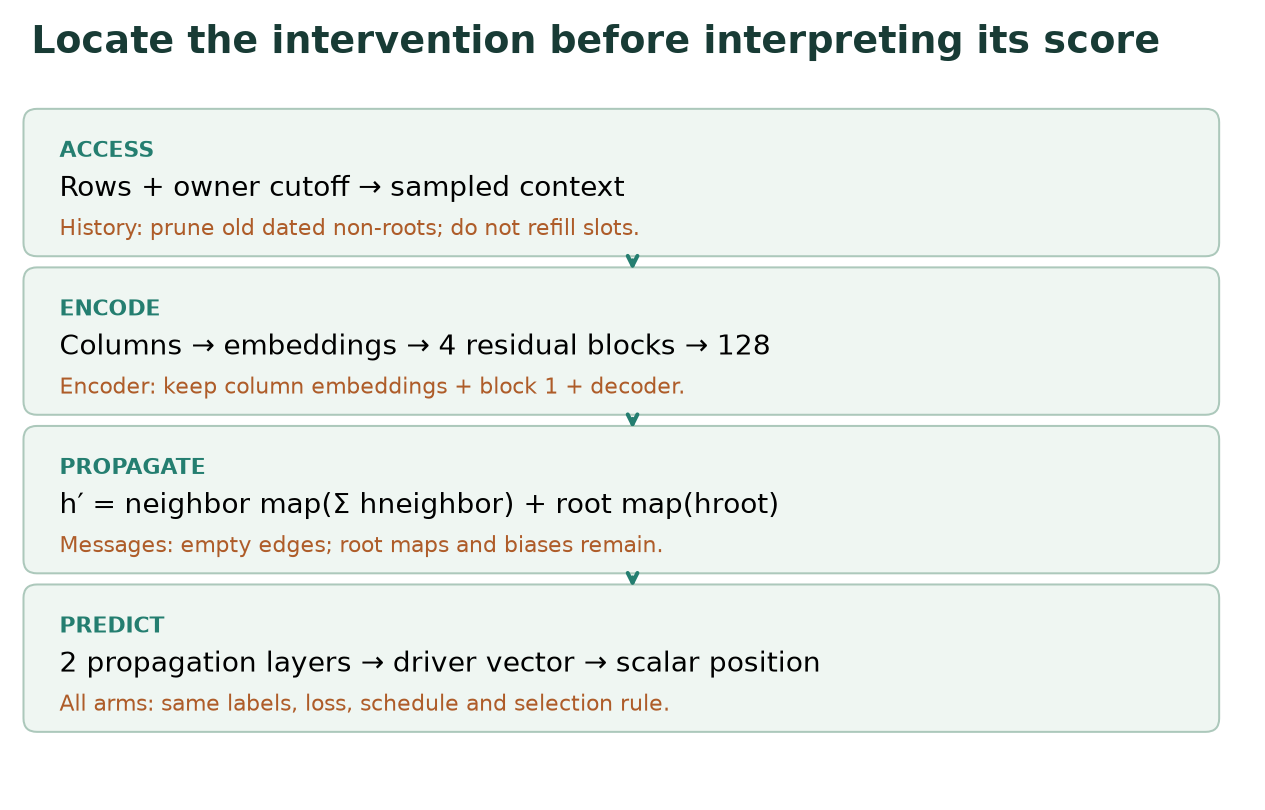<figcaption>Trace the exact information path each arm changes. Width128 is retained; shallow encoder capacity is not matched. Scroll for detail on narrow screens.</figcaption></figure>

| Arm | Changed | Retained | Interpretation cost |
|---|---|---|---|
| Full | Nothing | Released model/protocol | Named baseline replay |
| Encoder | Keep only first of four residual blocks | Column embeddings, decoder, width, graph | Capacity, dropout calls and compute change |
| Messages | Empty every sampled edge tensor | Root maps, relation biases, encoders, time | Not the same as a separately tuned tabular baseline |
| History | Remove old dated non-root rows after sampling | Query roots, undated rows, other mechanisms | Sampling slots are not refilled |
| Combined | Encoder and message interventions together | Remaining baseline components | Tests their interaction, not data interactions |

**Why retain root transformations?** A GraphSAGE relation computes a transformed neighbor aggregate plus a transformed destination. Empty edges remove neighbor information; the destination transformation and neighbor-map bias still exist. Deleting the whole layer would also remove these, answering a different question.

**Why retrain?** Zeroing messages only at test time measures reliance of a fitted model under a distribution change. Our arms retrain from initialization, allowing the remaining components to adapt. Neither measurement is inherently interchangeable with the other.

**Visible implementation.** The intervention is short enough to inspect. For the shallow encoder, `encoder.backbone = Sequential(encoder.backbone[0])`. For no messages, each `edge_index` becomes `edge_index[:, :0]`. The notebook includes the complete underlying model and trainer, not just these two lines. Shared initialized tensors are retained, but different dropout calls can change later random-number consumption.



## 3 · Data access is a query-specific contract

> **In plain terms.** “Only the last year” means the last year before this query, not before the newest query in the batch.

A **query owner** identifies which seed query a sampled copy belongs to. An entity may appear multiple times because it is queried at different cutoffs. Its copies need different context. For each dated non-root row, keep it when `cutoff − window ≤ row_time ≤ cutoff`. Undated rows remain; roots remain unless they violate the temporal upper bound. A year here is explicitly 365 days.

**Worked example.** Query A is at day 400 and query B at day 500. With a 365-day window, day 100 is legal for A but too old for B. Day 450 is future information for A and legal for B. A batch-wide maximum cutoff would give A information it should not see.

<figure class="ablation-figure" tabindex="0">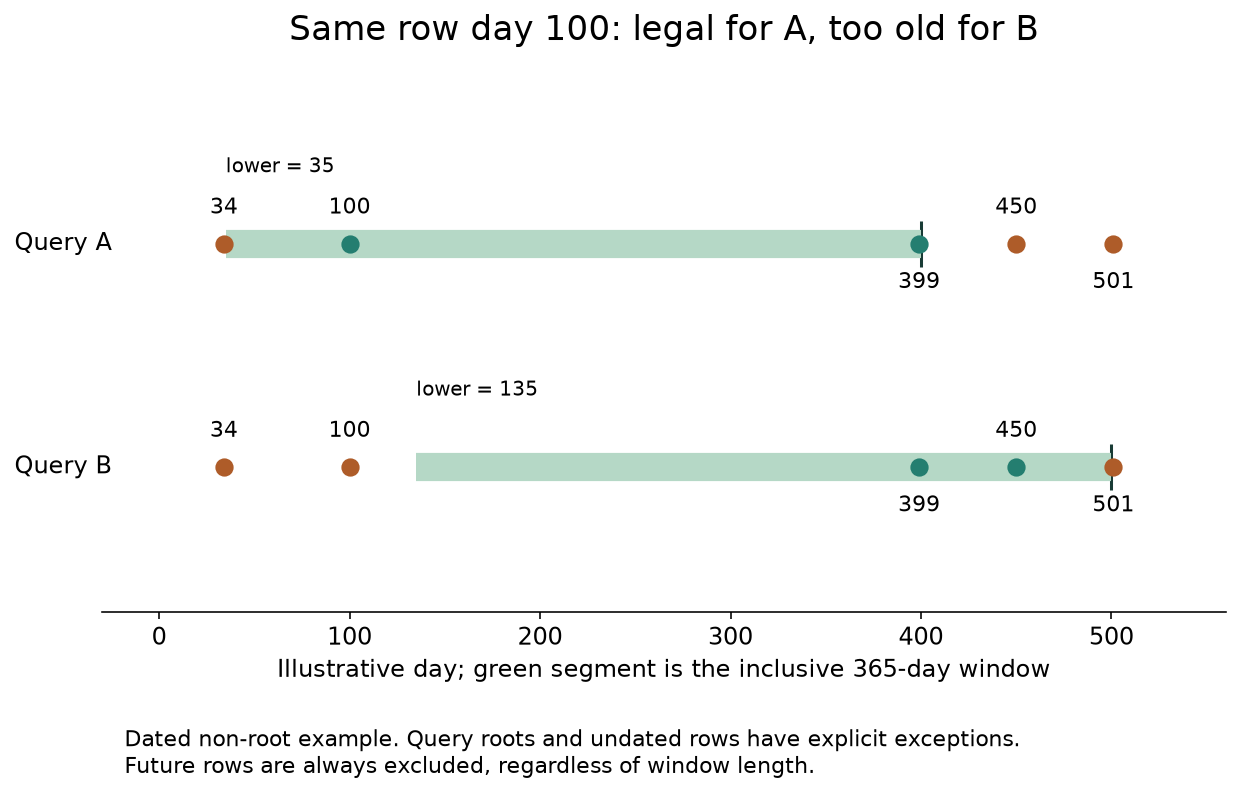<figcaption>Illustrative day units: each query has a different inclusive365-day window. The day100 row changes eligibility with its owner. Scroll for detail on narrow screens.</figcaption></figure>

At365days, day100is legal for cutoff400but too old for cutoff500. Day450is future for cutoff400and legal for cutoff500.

**Predict before changing the window.** Which rows disappear at 30 days? Which return at 365? Does the day-450 row ever become legal for query A? Reset the control and explain why its upper bound is independent of the window length.

The implemented history arm first uses the baseline temporal sampler, then deletes old non-root nodes and incident edges before encoding. It does **not** refill the removed sampling slots. Therefore its effect combines a shorter history with reduced sampled context. An alternative pre-sampling restriction could expose more recent neighbors; that is a different experiment. The retained graph can include legal but disconnected rows, which cannot send messages to the query.

**Data contribution is conditional.** An old row's removal can also remove a route to another row. This intervention measures access through this sampled graph, not the intrinsic value of one database column. Released preprocessing statistics remain fixed across arms and come from the test-censored database, not train-only materialization. Temporal filtering does not establish historical ingestion availability.



## 4 · Paired effects: subtract within seed first

**MAE**, mean absolute error, averages the absolute distance between prediction and target. Lower is better. For seed `s`, define the ablation effect as `MAE(arm,s) − MAE(full,s)`. Positive means the ablated procedure did worse. Pairing means subtracting the two scores with the same declared seed before summarizing; it does not promise identical batches or identical initialization of removed components.

**Worked example.** Full MAEs `[4, 5]` and ablated MAEs `[5, 7]` give paired differences `[1, 2]`, mean `1.5` and sample standard deviation about `0.707`. Sample standard deviation describes variability across these runs. It is not a confidence interval over databases or over drivers.

**Score by full query key.** A driver can have multiple cutoffs. Targets `[1,5]` for `(7,10),(7,20)` and reversed prediction rows `[5,3]` give MAE 1 after key alignment. Positional subtraction gives MAE 3. The notebook rejects missing, duplicate, extra and nonfinite predictions before computing any effect.

Predict: if removing two parts separately costs1and2MAE, must their joint removal cost3? No; their contributions can interact.

<figure class="ablation-figure" tabindex="0">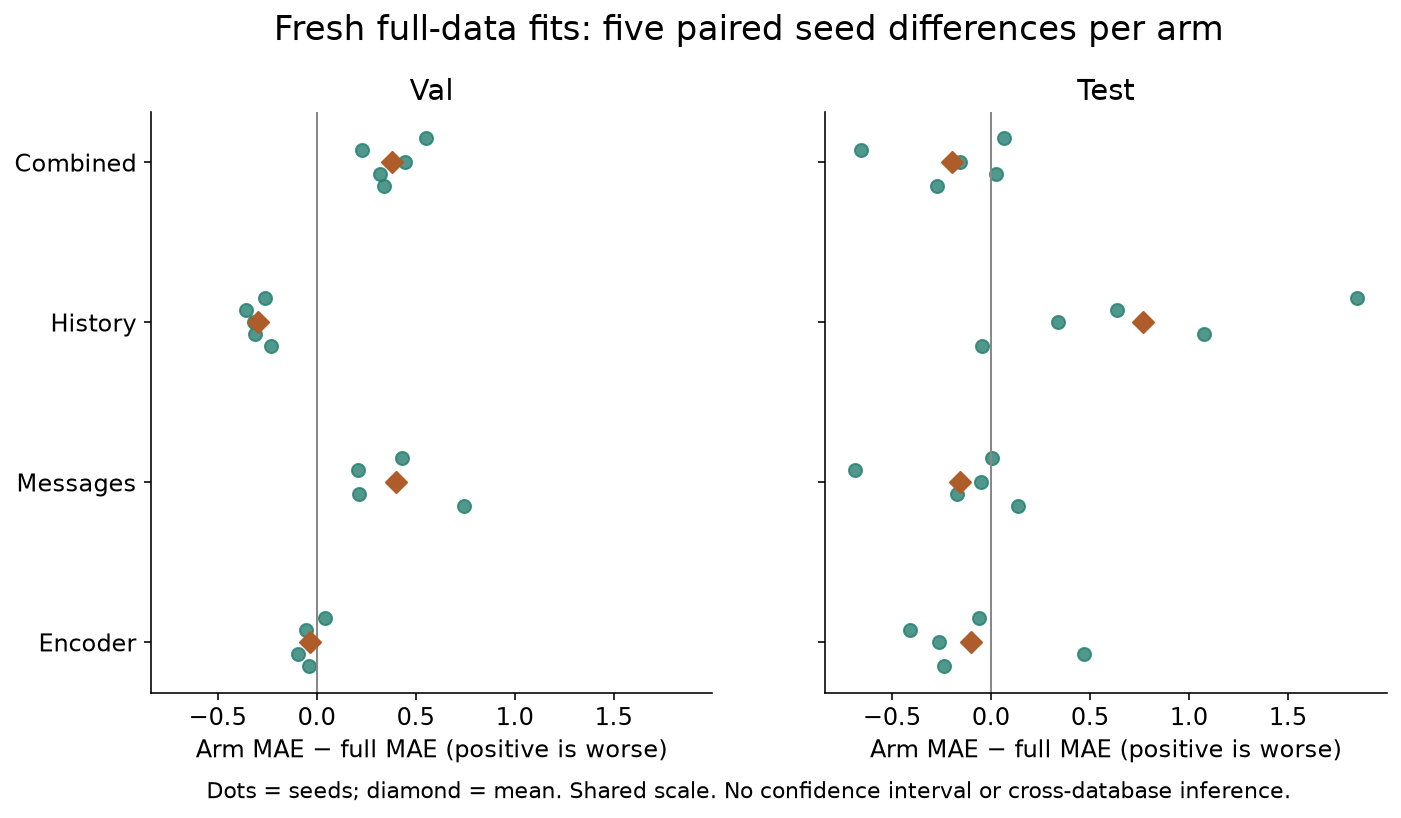<figcaption>Fresh full-data measurements. Five dots per arm are paired seed differences; diamond is their mean. No confidence intervals. Scroll for detail on narrow screens.</figcaption></figure>

| Arm | Validation MAE ± seed SD | Test MAE ± seed SD | Parameters |
|---|---:|---:|---:|
| full | 3.2245 ± 0.0531 | 4.1931 ± 0.2428 | 5,077,249 |
| encoder | 3.1888 ± 0.0434 | 4.0937 ± 0.2673 | 4,171,777 |
| messages | 3.6235 ± 0.2263 | 4.0393 ± 0.2050 | 5,077,249 |
| history | 2.9305 ± 0.0648 | 4.9639 ± 0.6387 | 5,077,249 |
| combined | 3.6033 ± 0.0767 | 3.9954 ± 0.0561 | 4,171,777 |

All 25 fresh fits completed; **31,475** held-out predictions independently rescored. Positive paired differences favor the full baseline.

**Val paired changes:** encoder -0.0356 ± 0.0498; messages +0.3990 ± 0.2181; history -0.2940 ± 0.0498; combined +0.3788 ± 0.1241.

**Test paired changes:** encoder -0.0994 ± 0.3422; messages -0.1538 ± 0.3183; history +0.7708 ± 0.7292; combined -0.1977 ± 0.2901.

Encoder–message interaction: validation **+0.0155 ± 0.2190**, test **+0.0554 ± 0.2850** MAE. These are mean ± sample seed SD.


**Read the reversal.** Restricting history improves validation MAE by 0.2940 but worsens test MAE by 0.7708 on average. Removing messages worsens validation by 0.3990 yet improves test by 0.1538. These results challenge a simple “more history and more propagation always help” story. They do not identify why the ordering reverses: population shift, sampling coverage and the preserved numerical-gradient limitation remain candidates. We do not retune on these test outcomes.

**Fixed protocol.** All arms use every 7,453 training query for ten epochs, five seeds 0–4, Adam at 0.005, batch size 512, two 128-wide layers and uniform temporal fanouts 128/64. Each arm selects its first validation minimum using all 499 validation queries. Final scores use the restored checkpoint and all 760 test queries; evaluation clips outputs to the training-target 2nd/98th percentiles. Final sampled validation can differ from selection-time validation.

**What is not fixed?** Encoder parameter count and executed computation change. Empty edges leave unused parameters, so equal total parameter counts do not mean equal effective capacity. Sampled contexts can diverge after random-number consumption diverges. These are fixed-training-protocol interventions, not equal-capacity or equal-compute competitions.



## 5 · Two useful parts need not contribute additively

> **In plain terms.** The encoder may be useful mainly because message passing can carry its output. Remove messages first, and removing encoder depth may matter less.

Let `F`, `E`, `M`, and `EM` be the four paired MAEs for full, shallow encoder, no messages and their combination. The **interaction** is `I = EM − E − M + F`. Every letter is a score for the same seed. Equivalently, compare the encoder effect without messages, `EM − M`, with its effect when messages remain, `E − F`.

**Worked example.** `F=4, E=5, M=6, EM=6.5`. Separate penalties are 1 and 2. Their sum predicts MAE 7 under additivity. Observed combined MAE is 6.5, so interaction is −0.5. On this error scale, the combined penalty is smaller than the sum. This does not prove a biological-style synergy or provide percentages of total “credit.”

**Read the interaction cautiously.** The test interaction averages +0.0554 MAE with sample SD 0.2850, and individual seeds have both signs. That describes weak directional consistency across these five fits; it does not establish either independence or a reliable positive interaction.

<figure class="ablation-figure" tabindex="0">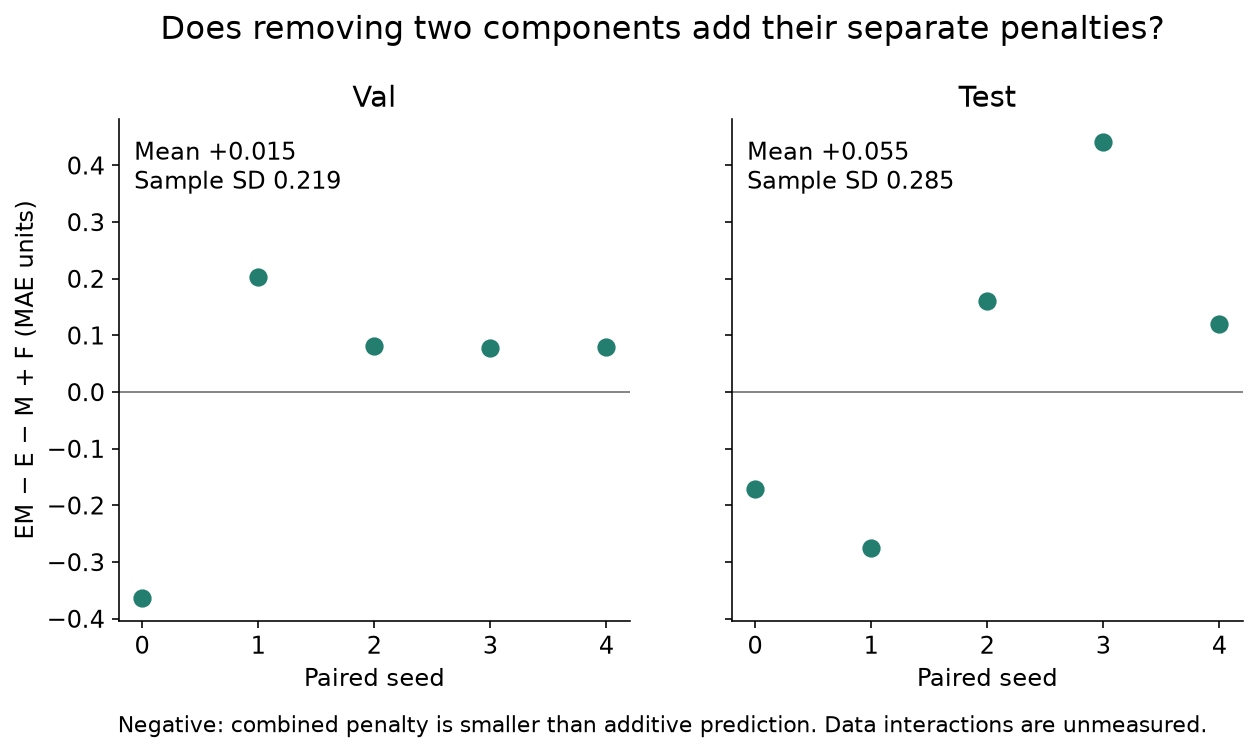<figcaption>Measured interaction on the MAE scale, calculated within seed. Data-access interactions were not included in this five-arm design. Scroll for detail on narrow screens.</figcaption></figure>

Hypothetical F4,E5,M6,EM6.5 gives interaction−.5. Changing only EMto7makes the interaction0.

**Predict, then adjust.** Keep F, E and M fixed and set EM to 7. The interaction should become zero. Set EM to 8 and explain the sign without looking at the answer. This widget uses hypothetical values; it never rewrites measured evidence.

The five-arm design estimates the encoder–message interaction only. It has no combined history/encoder or history/message arms. A full three-factor design has eight cells; further interactions remain unmeasured. One-at-a-time ablations cannot establish an additive decomposition of performance.



## 6 · Lab: implement the contract, then defend the claim

Open the [student notebook](https://avistian.github.io/relational/labs/0148-ablation-discipline.ipynb). Its three live TODOs implement the owner-specific history mask, keyed MAE and paired interaction. CHECK cells reject specific faulty implementations. The mask drives a real sampled-context exercise; the scoring functions audit all author predictions. The [executed solution](https://avistian.github.io/relational/labs/html/0148-ablation-discipline.html) is author-reference evidence, not proof that you completed the exercises.

The portable default runs without a GPU. Complete model, intervention and trainer definitions remain visible, with an explicit opt-in full training lane for a pinned environment. Author artifacts are embedded with a checksum so a fresh notebook can reproduce the analysis. Training is never silently triggered by a normal notebook run.

**EXIT: 150–250 words.** Choose one measured ablation. State the intervention, held-fixed quantities, paired result, one confound and a falsifier. Then explain the interaction sign and propose the smallest follow-up that separates shorter history from unfilled sampling slots. Do not select a new window after test inspection and call it confirmatory.

Write your intervention, fixed protocol, paired evidence, confound and falsifier. Explain what the interaction can and cannot establish. Ask the teaching agent for feedback.



## 7 · Reproduction and claim boundaries

**Executed:** 25 complete ten-epoch fits on the full task; independent key/label audits; baseline original-model output replay; owner-window and intervention checks. Baseline descriptive comparisons: validation **CLOSE**, test **CLOSE**. Paper means are 3.193 / 4.022 MAE.

**Gradient boundary:** one real initial-batch diagnostic counted nonfinite gradient entries {'full': 512, 'encoder': 512, 'messages': 512, 'history': 512, 'combined': 512}. The released missing-value numerical path is preserved. Finite predictions and source parity do not prove gradient health; this is a limit on interpreting these fits.

**Cost:** conservative reservations including two pre-worker mount failures and overhead fit the approved USD 10 cap. Measured worker-body estimates and the exact reservations are in the cost ledger; they are not an itemized invoice. Browser and notebook results are recorded separately in the delivery reports.

**Final delivery:** default solution and pinned notebook PASS; pinned validation adds one full history seed100 fit, excluded from primary statistics, with1,259 independently checked predictions. Desktop/mobile, keyboard/reset, print/noJS and clean Git-index Pages PASS. Conservative all-attempt reservations plus overhead **USD9.974748**; known worker-body estimate **USD0.166615**, excluding unitemized costs. Live Colab/deployment NOT_CHECKED.


The source-pinned baseline is a complete selected released-protocol replay where execution succeeds. Descriptive closeness uses a frozen ±0.2 MAE band around the paper means; it is not a statistical equivalence test. Missing historical seeds/environment and documented release/paper differences prevent an exact historical-identity claim.

The same F1 test population has appeared in earlier lessons. These ablations are exploratory even though their protocol was frozen before this lesson's runs. No arm is retuned or dropped for a disappointing result. Whole-paper reproduction is NOT_RUN; learner mastery is PENDING_WRITTEN_DEFENSE. Live Colab and deployment are separate checks.

Use the [reproduction contract](https://avistian.github.io/relational/labs/l148-reproduction.md), [reference sheet](https://avistian.github.io/relational/reference/ablation-discipline.html) and [primary paper](https://arxiv.org/html/2407.20060v1). Ask the teaching agent to review any unclear mechanism or your written defense. Lesson 149 will use disciplined evidence to examine where the thesis is weakest.


<!-- sequence-next:start -->
**Carry this forward.** Use the same discipline in Lesson 149: a weakness identifies where a procedure loses, while an intervention tests an explanation of that loss. [Continue to Lesson 149](https://avistian.github.io/relational/lessons/0149-weakest-relbench-tasks.html).
<!-- sequence-next:end -->


In [2]:
raw=base64.b64decode('...')
assert hashlib.sha256(raw).hexdigest()=='ec2fb368932c5d1685e5d92d47f4c5c68edafca324692db21f32853b38ae31e6'
DATA=np.load(io.BytesIO(raw),allow_pickle=False)
raw=base64.b64decode('...')
assert hashlib.sha256(raw).hexdigest()=='abbbc41beb1526802151632d2d5636334242a4c1ae37ef820686233f1a4d1a44'
SAMPLE=np.load(io.BytesIO(raw),allow_pickle=False)
AUTHOR=json.loads('{"status": "COMPLETE", "runs": [{"status": "COMPLETE", "arm": "full", "parameter_count": 5077249, "removed_nodes": 0, "seed": 0, "epochs": 10, "selected_epoch": 6, "selection_mae": 3.2657190810861634, "scores": {"val": 3.2689920429874437, "test": 4.242662710892526}, "replay": {"val": {"queries": 499, "max_original_logit_error": 1.9073486328125e-06, "sampled_nodes": 142973}, "test": {"queries": 760, "max_original_logit_error": 1.9073486328125e-06, "sampled_nodes": 139757}}, "trace": [{"epoch": 1, "train_mae": 8.862489841007697, "val_mae": 4.223146545114562, "train_queries": 7453}, {"epoch": 2, "train_mae": 5.819783304803854, "val_mae": 4.440129953332161, "train_queries": 7453}, {"epoch": 3, "train_mae": 5.575583107340629, "val_mae": 3.7866114880772694, "train_queries": 7453}, {"epoch": 4, "train_mae": 5.442285486472368, "val_mae": 3.779326369846831, "train_queries": 7453}, {"epoch": 5, "train_mae": 5.394563184334066, "val_mae": 3.6798824712922755, "train_queries": 7453}, {"epoch": 6, "train_mae": 5.251741443274726, "val_mae": 3.2657190810861634, "train_queries": 7453}, {"epoch": 7, "train_mae": 4.984213577538197, "val_mae": 3.3923804257022754, "train_queries": 7453}, {"epoch": 8, "train_mae": 4.861647904487036, "val_mae": 3.3985507377721347, "train_queries": 7453}, {"epoch": 9, "train_mae": 4.81187378658027, "val_mae": 3.560125600296255, "train_queries": 7453}, {"epoch": 10, "train_mae": 4.756362458867193, "val_mae": 3.4537167110838087, "train_queries": 7453}], "clamp": [2.0, 31.0], "seconds": 31.304619934999998, "protocol": {"channels": 128, "num_layers": 2, "batch_size": 512, "lr": 0.005, "epochs": 10, "fanout": [128, 64], "aggr": "sum", "temporal_strategy": "uniform"}, "checkpoint_sha256": "f56a3d27d5ee58b56759795b1fb0a1208bf73e20a180934319cefcd4dc1705ac", "run_id": "06315d9b-6ff4-4e50-8c10-40726508dcc1", "graph_sha256": "7715046a8a00bf699364ddb0a0e08d378ca40c7401231386ab78be6f2c7d81c9"}, {"status": "COMPLETE", "arm": "full", "parameter_count": 5077249, "removed_nodes": 0, "seed": 1, "epochs": 10, "selected_epoch": 10, "selection_mae": 3.2221644637261377, "scores": {"val": 3.2270094742198427, "test": 4.049410132274293}, "replay": {"val": {"queries": 499, "max_original_logit_error": 2.86102294921875e-06, "sampled_nodes": 142995}, "test": {"queries": 760, "max_original_logit_error": 1.9073486328125e-06, "sampled_nodes": 139834}}, "trace": [{"epoch": 1, "train_mae": 8.825854734591985, "val_mae": 4.227473743135482, "train_queries": 7453}, {"epoch": 2, "train_mae": 5.800915978538035, "val_mae": 4.439565184089288, "train_queries": 7453}, {"epoch": 3, "train_mae": 5.551276275172068, "val_mae": 3.7649360285971114, "train_queries": 7453}, {"epoch": 4, "train_mae": 5.42933733645948, "val_mae": 3.7246724740934916, "train_queries": 7453}, {"epoch": 5, "train_mae": 5.381144311785394, "val_mae": 3.6737090882254826, "train_queries": 7453}, {"epoch": 6, "train_mae": 5.248607202038802, "val_mae": 3.258874531340105, "train_queries": 7453}, {"epoch": 7, "train_mae": 4.920220102765457, "val_mae": 3.2481302764627564, "train_queries": 7453}, {"epoch": 8, "train_mae": 4.867050612355085, "val_mae": 3.251243300046137, "train_queries": 7453}, {"epoch": 9, "train_mae": 4.798092462321375, "val_mae": 3.22302110515281, "train_queries": 7453}, {"epoch": 10, "train_mae": 4.760379774241292, "val_mae": 3.2221644637261377, "train_queries": 7453}], "clamp": [2.0, 31.0], "seconds": 31.558188948, "protocol": {"channels": 128, "num_layers": 2, "batch_size": 512, "lr": 0.005, "epochs": 10, "fanout": [128, 64], "aggr": "sum", "temporal_strategy": "uniform"}, "checkpoint_sha256": "38cdc5a132a002a05151ddd55e09e34473ac760e1c2d40e8f31f95e947f2835d", "run_id": "63aaf4db-df16-44b1-858b-ea6141d8a265", "graph_sha256": "7715046a8a00bf699364ddb0a0e08d378ca40c7401231386ab78be6f2c7d81c9"}, {"status": "COMPLETE", "arm": "full", "parameter_count": 5077249, "removed_nodes": 0, "seed": 2, "epochs": 10, "selected_epoch": 10, "selection_mae": 3.188891966596156, "scores": {"val": 3.1870688853139626, "test": 4.1322574914965715}, "replay": {"val": {"queries": 499, "max_original_logit_error": 2.86102294921875e-06, "sampled_nodes": 142978}, "test": {"queries": 760, "max_original_logit_error": 1.9073486328125e-06, "sampled_nodes": 139774}}, "trace": [{"epoch": 1, "train_mae": 8.98990414335506, "val_mae": 4.277364499073628, "train_queries": 7453}, {"epoch": 2, "train_mae": 5.881154757353438, "val_mae": 4.367085907757083, "train_queries": 7453}, {"epoch": 3, "train_mae": 5.56233143105885, "val_mae": 3.754560911297082, "train_queries": 7453}, {"epoch": 4, "train_mae": 5.448666947489055, "val_mae": 3.7373509960645985, "train_queries": 7453}, {"epoch": 5, "train_mae": 5.3907348317266965, "val_mae": 3.6625984500230118, "train_queries": 7453}, {"epoch": 6, "train_mae": 5.1408852334472295, "val_mae": 3.287533840977039, "train_queries": 7453}, {"epoch": 7, "train_mae": 4.946570513569299, "val_mae": 3.19154362490596, "train_queries": 7453}, {"epoch": 8, "train_mae": 4.851599782485378, "val_mae": 3.330717578217756, "train_queries": 7453}, {"epoch": 9, "train_mae": 4.7844990747304115, "val_mae": 3.2783129739856913, "train_queries": 7453}, {"epoch": 10, "train_mae": 4.743198333035439, "val_mae": 3.188891966596156, "train_queries": 7453}], "clamp": [2.0, 31.0], "seconds": 31.407559007000003, "protocol": {"channels": 128, "num_layers": 2, "batch_size": 512, "lr": 0.005, "epochs": 10, "fanout": [128, 64], "aggr": "sum", "temporal_strategy": "uniform"}, "checkpoint_sha256": "9150e21a4097ca7c371ff2d338e9a727a6ca5d4394f42cd254322c11f1806dc1", "run_id": "0220a7bf-3302-4754-b137-671db52015be", "graph_sha256": "7715046a8a00bf699364ddb0a0e08d378ca40c7401231386ab78be6f2c7d81c9"}, {"status": "COMPLETE", "arm": "full", "parameter_count": 5077249, "removed_nodes": 0, "seed": 3, "epochs": 10, "selected_epoch": 8, "selection_mae": 3.2819200510650615, "scores": {"val": 3.2822741642902913, "test": 4.5844144203788355}, "replay": {"val": {"queries": 499, "max_original_logit_error": 1.9073486328125e-06, "sampled_nodes": 142995}, "test": {"queries": 760, "max_original_logit_error": 2.86102294921875e-06, "sampled_nodes": 139756}}, "trace": [{"epoch": 1, "train_mae": 8.905476512995948, "val_mae": 4.282032176790512, "train_queries": 7453}, {"epoch": 2, "train_mae": 5.8783630093168, "val_mae": 4.3204966800564835, "train_queries": 7453}, {"epoch": 3, "train_mae": 5.498270127559914, "val_mae": 3.7788215940446164, "train_queries": 7453}, {"epoch": 4, "train_mae": 5.401978166826648, "val_mae": 3.807699046775191, "train_queries": 7453}, {"epoch": 5, "train_mae": 5.4026241542412325, "val_mae": 3.6765289123168214, "train_queries": 7453}, {"epoch": 6, "train_mae": 5.296398260602052, "val_mae": 3.3839507552091486, "train_queries": 7453}, {"epoch": 7, "train_mae": 4.995845950531125, "val_mae": 3.3725642419609927, "train_queries": 7453}, {"epoch": 8, "train_mae": 4.9076406795451035, "val_mae": 3.2819200510650615, "train_queries": 7453}, {"epoch": 9, "train_mae": 4.891953357382779, "val_mae": 3.3425966637406894, "train_queries": 7453}, {"epoch": 10, "train_mae": 4.818619606335915, "val_mae": 3.3049297295814366, "train_queries": 7453}], "clamp": [2.0, 31.0], "seconds": 30.914915426, "protocol": {"channels": 128, "num_layers": 2, "batch_size": 512, "lr": 0.005, "epochs": 10, "fanout": [128, 64], "aggr": "sum", "temporal_strategy": "uniform"}, "checkpoint_sha256": "20c4868f902a2de2855fca3f7891ef5d8518173d1ebd86de75a6b5fdbd13acbe", "run_id": "0da4c84f-395a-4738-9fdd-7381d72e44e0", "graph_sha256": "7715046a8a00bf699364ddb0a0e08d378ca40c7401231386ab78be6f2c7d81c9"}, {"status": "COMPLETE", "arm": "full", "parameter_count": 5077249, "removed_nodes": 0, "seed": 4, "epochs": 10, "selected_epoch": 10, "selection_mae": 3.167007336460437, "scores": {"val": 3.157110164606659, "test": 3.9567889693745393}, "replay": {"val": {"queries": 499, "max_original_logit_error": 1.9073486328125e-06, "sampled_nodes": 143010}, "test": {"queries": 760, "max_original_logit_error": 2.86102294921875e-06, "sampled_nodes": 139794}}, "trace": [{"epoch": 1, "train_mae": 9.070535623577799, "val_mae": 4.344616997616244, "train_queries": 7453}, {"epoch": 2, "train_mae": 5.888133615675219, "val_mae": 4.32934841749743, "train_queries": 7453}, {"epoch": 3, "train_mae": 5.554263225997133, "val_mae": 3.7811885347028693, "train_queries": 7453}, {"epoch": 4, "train_mae": 5.435657067313604, "val_mae": 3.7307115981637753, "train_queries": 7453}, {"epoch": 5, "train_mae": 5.39124592368145, "val_mae": 3.71153090915922, "train_queries": 7453}, {"epoch": 6, "train_mae": 5.375419655150733, "val_mae": 3.6803784976263567, "train_queries": 7453}, {"epoch": 7, "train_mae": 5.304922890186502, "val_mae": 3.327429987194543, "train_queries": 7453}, {"epoch": 8, "train_mae": 5.063202689513894, "val_mae": 3.303059838625616, "train_queries": 7453}, {"epoch": 9, "train_mae": 4.954001710380657, "val_mae": 3.5278721967377344, "train_queries": 7453}, {"epoch": 10, "train_mae": 4.833188363342305, "val_mae": 3.167007336460437, "train_queries": 7453}], "clamp": [2.0, 31.0], "seconds": 31.840446113, "protocol": {"channels": 128, "num_layers": 2, "batch_size": 512, "lr": 0.005, "epochs": 10, "fanout": [128, 64], "aggr": "sum", "temporal_strategy": "uniform"}, "checkpoint_sha256": "867b61804ba8335aa5a826424e8878b4ad133442ec6f8c6ec7f84455e6d1ab9b", "run_id": "14b90a98-27c5-40ca-8240-8df522811571", "graph_sha256": "7715046a8a00bf699364ddb0a0e08d378ca40c7401231386ab78be6f2c7d81c9"}, {"status": "COMPLETE", "arm": "encoder", "parameter_count": 4171777, "removed_nodes": 0, "seed": 0, "epochs": 10, "selected_epoch": 7, "selection_mae": 3.22067662342915, "scores": {"val": 3.230267143122101, "test": 4.006388829716465}, "replay": {"val": {"queries": 499, "max_original_logit_error": 0.0, "sampled_nodes": 142973}, "test": {"queries": 760, "max_original_logit_error": 0.0, "sampled_nodes": 139757}}, "trace": [{"epoch": 1, "train_mae": 8.845738196107472, "val_mae": 4.2117117828899175, "train_queries": 7453}, {"epoch": 2, "train_mae": 5.814374309121627, "val_mae": 4.463859226963245, "train_queries": 7453}, {"epoch": 3, "train_mae": 5.581574174808557, "val_mae": 3.798123981192977, "train_queries": 7453}, {"epoch": 4, "train_mae": 5.446678297512966, "val_mae": 3.7634763834869855, "train_queries": 7453}, {"epoch": 5, "train_mae": 5.389061076743769, "val_mae": 3.5944459884582396, "train_queries": 7453}, {"epoch": 6, "train_mae": 5.107908451139695, "val_mae": 3.246314309833045, "train_queries": 7453}, {"epoch": 7, "train_mae": 4.913858138457666, "val_mae": 3.22067662342915, "train_queries": 7453}, {"epoch": 8, "train_mae": 4.8529135307881175, "val_mae": 3.231250413513693, "train_queries": 7453}, {"epoch": 9, "train_mae": 4.841248691026019, "val_mae": 3.2980084048483316, "train_queries": 7453}, {"epoch": 10, "train_mae": 4.776167903860736, "val_mae": 3.2679988090245025, "train_queries": 7453}], "clamp": [2.0, 31.0], "seconds": 24.775875172, "protocol": {"channels": 128, "num_layers": 2, "batch_size": 512, "lr": 0.005, "epochs": 10, "fanout": [128, 64], "aggr": "sum", "temporal_strategy": "uniform"}, "checkpoint_sha256": "82ec4741305a7931d476e09134182aa0cfbfad3cdf8be30f0301b9137689d155", "run_id": "4ad94638-8253-4529-bd04-1b863c23dc5d", "graph_sha256": "7715046a8a00bf699364ddb0a0e08d378ca40c7401231386ab78be6f2c7d81c9"}, {"status": "COMPLETE", "arm": "encoder", "parameter_count": 4171777, "removed_nodes": 0, "seed": 1, "epochs": 10, "selected_epoch": 7, "selection_mae": 3.1290993272581336, "scores": {"val": 3.133196837311199, "test": 4.520554975794073}, "replay": {"val": {"queries": 499, "max_original_logit_error": 0.0, "sampled_nodes": 142995}, "test": {"queries": 760, "max_original_logit_error": 0.0, "sampled_nodes": 139834}}, "trace": [{"epoch": 1, "train_mae": 8.703011593050274, "val_mae": 4.175260044880207, "train_queries": 7453}, {"epoch": 2, "train_mae": 5.7803496013115705, "val_mae": 4.436526520728428, "train_queries": 7453}, {"epoch": 3, "train_mae": 5.563161900263256, "val_mae": 3.786769208863487, "train_queries": 7453}, {"epoch": 4, "train_mae": 5.442720350764285, "val_mae": 3.753516855794108, "train_queries": 7453}, {"epoch": 5, "train_mae": 5.39285970965792, "val_mae": 3.7087762386701706, "train_queries": 7453}, {"epoch": 6, "train_mae": 5.275103084196201, "val_mae": 3.242701995571853, "train_queries": 7453}, {"epoch": 7, "train_mae": 4.928303639552553, "val_mae": 3.1290993272581336, "train_queries": 7453}, {"epoch": 8, "train_mae": 4.851723016515988, "val_mae": 3.263317252001765, "train_queries": 7453}, {"epoch": 9, "train_mae": 4.771932881965776, "val_mae": 3.1373959110033214, "train_queries": 7453}, {"epoch": 10, "train_mae": 4.754884121067073, "val_mae": 3.2520522280701334, "train_queries": 7453}], "clamp": [2.0, 31.0], "seconds": 25.640055652, "protocol": {"channels": 128, "num_layers": 2, "batch_size": 512, "lr": 0.005, "epochs": 10, "fanout": [128, 64], "aggr": "sum", "temporal_strategy": "uniform"}, "checkpoint_sha256": "633ab4c99c71140867bfed9ec5fe5e114e4d507ae5b8432f38346674c98d87bf", "run_id": "94d71986-2052-4d76-970a-68c9ae44ffb5", "graph_sha256": "7715046a8a00bf699364ddb0a0e08d378ca40c7401231386ab78be6f2c7d81c9"}, {"status": "COMPLETE", "arm": "encoder", "parameter_count": 4171777, "removed_nodes": 0, "seed": 2, "epochs": 10, "selected_epoch": 8, "selection_mae": 3.149669120689193, "scores": {"val": 3.1544235779909426, "test": 3.8686715305060666}, "replay": {"val": {"queries": 499, "max_original_logit_error": 0.0, "sampled_nodes": 142978}, "test": {"queries": 760, "max_original_logit_error": 0.0, "sampled_nodes": 139774}}, "trace": [{"epoch": 1, "train_mae": 9.002164773008223, "val_mae": 4.290196234780148, "train_queries": 7453}, {"epoch": 2, "train_mae": 5.879910477628392, "val_mae": 4.396202146521233, "train_queries": 7453}, {"epoch": 3, "train_mae": 5.563265930034003, "val_mae": 3.7355474288573487, "train_queries": 7453}, {"epoch": 4, "train_mae": 5.454841476342158, "val_mae": 3.7365632199253653, "train_queries": 7453}, {"epoch": 5, "train_mae": 5.3745643813290505, "val_mae": 3.572421432704072, "train_queries": 7453}, {"epoch": 6, "train_mae": 5.046185857383065, "val_mae": 3.341263420420961, "train_queries": 7453}, {"epoch": 7, "train_mae": 4.933459930798679, "val_mae": 3.2354938450382003, "train_queries": 7453}, {"epoch": 8, "train_mae": 4.870855542744276, "val_mae": 3.149669120689193, "train_queries": 7453}, {"epoch": 9, "train_mae": 4.803917864289329, "val_mae": 3.189415866021084, "train_queries": 7453}, {"epoch": 10, "train_mae": 4.77811457252528, "val_mae": 3.1942268635960684, "train_queries": 7453}], "clamp": [2.0, 31.0], "seconds": 24.807159143999996, "protocol": {"channels": 128, "num_layers": 2, "batch_size": 512, "lr": 0.005, "epochs": 10, "fanout": [128, 64], "aggr": "sum", "temporal_strategy": "uniform"}, "checkpoint_sha256": "d1f2abeefabbc4f61e0b17807b70d1902a6f6409b0d210517009720de74cd82b", "run_id": "660ef03a-9abe-4b6a-ac9e-5ee5f79f3720", "graph_sha256": "7715046a8a00bf699364ddb0a0e08d378ca40c7401231386ab78be6f2c7d81c9"}, {"status": "COMPLETE", "arm": "encoder", "parameter_count": 4171777, "removed_nodes": 0, "seed": 3, "epochs": 10, "selected_epoch": 6, "selection_mae": 3.2241505780853905, "scores": {"val": 3.22656808323118, "test": 4.175777694300601}, "replay": {"val": {"queries": 499, "max_original_logit_error": 0.0, "sampled_nodes": 142995}, "test": {"queries": 760, "max_original_logit_error": 0.0, "sampled_nodes": 139756}}, "trace": [{"epoch": 1, "train_mae": 8.90433754531326, "val_mae": 4.302053150974598, "train_queries": 7453}, {"epoch": 2, "train_mae": 5.892616412407054, "val_mae": 4.299762539044969, "train_queries": 7453}, {"epoch": 3, "train_mae": 5.519940009616804, "val_mae": 3.779738509280728, "train_queries": 7453}, {"epoch": 4, "train_mae": 5.430497061497698, "val_mae": 3.7321871998951925, "train_queries": 7453}, {"epoch": 5, "train_mae": 5.382140947383122, "val_mae": 3.6259654691717826, "train_queries": 7453}, {"epoch": 6, "train_mae": 5.051254993122919, "val_mae": 3.2241505780853905, "train_queries": 7453}, {"epoch": 7, "train_mae": 4.9026991801823, "val_mae": 3.4095074999547434, "train_queries": 7453}, {"epoch": 8, "train_mae": 4.867958748626914, "val_mae": 3.2473248162584936, "train_queries": 7453}, {"epoch": 9, "train_mae": 4.829743445583371, "val_mae": 3.254601834436696, "train_queries": 7453}, {"epoch": 10, "train_mae": 4.760633144125304, "val_mae": 3.3962402448227347, "train_queries": 7453}], "clamp": [2.0, 31.0], "seconds": 27.992361581000004, "protocol": {"channels": 128, "num_layers": 2, "batch_size": 512, "lr": 0.005, "epochs": 10, "fanout": [128, 64], "aggr": "sum", "temporal_strategy": "uniform"}, "checkpoint_sha256": "39f2de6d276f07887acfbf66e11444d85a6effc629b6c600b7939cc0522979a2", "run_id": "e4f1e419-1c89-47a5-9a9f-a3344fa9c513", "graph_sha256": "7715046a8a00bf699364ddb0a0e08d378ca40c7401231386ab78be6f2c7d81c9"}, {"status": "COMPLETE", "arm": "encoder", "parameter_count": 4171777, "removed_nodes": 0, "seed": 4, "epochs": 10, "selected_epoch": 8, "selection_mae": 3.1968954053176746, "scores": {"val": 3.1997562493812906, "test": 3.897312375286169}, "replay": {"val": {"queries": 499, "max_original_logit_error": 0.0, "sampled_nodes": 143010}, "test": {"queries": 760, "max_original_logit_error": 0.0, "sampled_nodes": 139794}}, "trace": [{"epoch": 1, "train_mae": 9.136426895524965, "val_mae": 4.380686194879179, "train_queries": 7453}, {"epoch": 2, "train_mae": 5.905823381606419, "val_mae": 4.319448265172516, "train_queries": 7453}, {"epoch": 3, "train_mae": 5.542322283636943, "val_mae": 3.73998729766968, "train_queries": 7453}, {"epoch": 4, "train_mae": 5.436521862075582, "val_mae": 3.767576246318932, "train_queries": 7453}, {"epoch": 5, "train_mae": 5.396356925186368, "val_mae": 3.7024682418935364, "train_queries": 7453}, {"epoch": 6, "train_mae": 5.231769581281242, "val_mae": 3.305059479934499, "train_queries": 7453}, {"epoch": 7, "train_mae": 4.936588293815417, "val_mae": 3.347313530539065, "train_queries": 7453}, {"epoch": 8, "train_mae": 4.919454133384231, "val_mae": 3.1968954053176746, "train_queries": 7453}, {"epoch": 9, "train_mae": 4.83723610384455, "val_mae": 3.2615241878894303, "train_queries": 7453}, {"epoch": 10, "train_mae": 4.7803843606482825, "val_mae": 3.215052320611581, "train_queries": 7453}], "clamp": [2.0, 31.0], "seconds": 28.778835149000003, "protocol": {"channels": 128, "num_layers": 2, "batch_size": 512, "lr": 0.005, "epochs": 10, "fanout": [128, 64], "aggr": "sum", "temporal_strategy": "uniform"}, "checkpoint_sha256": "b19a4b826f846c5318e5f431b68f393a31534db8ad8d274fb61bcbb593324620", "run_id": "8d38ced0-9e7a-4fa9-8a37-38f6333b7819", "graph_sha256": "7715046a8a00bf699364ddb0a0e08d378ca40c7401231386ab78be6f2c7d81c9"}, {"status": "COMPLETE", "arm": "messages", "parameter_count": 5077249, "removed_nodes": 0, "seed": 0, "epochs": 10, "selected_epoch": 10, "selection_mae": 4.012184882434751, "scores": {"val": 4.012184882434751, "test": 4.377863264167518}, "replay": {"val": {"queries": 499, "max_original_logit_error": 0.0, "sampled_nodes": 142973}, "test": {"queries": 760, "max_original_logit_error": 0.0, "sampled_nodes": 139757}}, "trace": [{"epoch": 1, "train_mae": 9.01951046775655, "val_mae": 4.266042710752112, "train_queries": 7453}, {"epoch": 2, "train_mae": 5.8545579213544565, "val_mae": 4.418081329310028, "train_queries": 7453}, {"epoch": 3, "train_mae": 5.6326924868754755, "val_mae": 4.346449007124764, "train_queries": 7453}, {"epoch": 4, "train_mae": 5.559783245978796, "val_mae": 4.111666633641632, "train_queries": 7453}, {"epoch": 5, "train_mae": 5.548675087911242, "val_mae": 4.180851331391013, "train_queries": 7453}, {"epoch": 6, "train_mae": 5.550154089431834, "val_mae": 4.119548404033613, "train_queries": 7453}, {"epoch": 7, "train_mae": 5.549475945739255, "val_mae": 4.161342797569219, "train_queries": 7453}, {"epoch": 8, "train_mae": 5.549422836457261, "val_mae": 4.079682697736986, "train_queries": 7453}, {"epoch": 9, "train_mae": 5.547718805545739, "val_mae": 4.137839420652421, "train_queries": 7453}, {"epoch": 10, "train_mae": 5.544208856104333, "val_mae": 4.012184882434751, "train_queries": 7453}], "clamp": [2.0, 31.0], "seconds": 27.854478084999997, "protocol": {"channels": 128, "num_layers": 2, "batch_size": 512, "lr": 0.005, "epochs": 10, "fanout": [128, 64], "aggr": "sum", "temporal_strategy": "uniform"}, "checkpoint_sha256": "6d73c16e0f09c359c857ad0ba46e708bad77756a8c68f93e901da0bacdcfb7fd", "run_id": "8fa7f241-14f3-4685-9675-d583a5f76d8d", "graph_sha256": "7715046a8a00bf699364ddb0a0e08d378ca40c7401231386ab78be6f2c7d81c9"}, {"status": "COMPLETE", "arm": "messages", "parameter_count": 5077249, "removed_nodes": 0, "seed": 1, "epochs": 10, "selected_epoch": 6, "selection_mae": 3.439760870796566, "scores": {"val": 3.439760870796566, "test": 3.8805794039943766}, "replay": {"val": {"queries": 499, "max_original_logit_error": 0.0, "sampled_nodes": 142995}, "test": {"queries": 760, "max_original_logit_error": 0.0, "sampled_nodes": 139834}}, "trace": [{"epoch": 1, "train_mae": 8.827763423781482, "val_mae": 4.20097332140885, "train_queries": 7453}, {"epoch": 2, "train_mae": 5.802428302933798, "val_mae": 4.467222018296033, "train_queries": 7453}, {"epoch": 3, "train_mae": 5.633824469050545, "val_mae": 4.139478884272044, "train_queries": 7453}, {"epoch": 4, "train_mae": 5.563145941925356, "val_mae": 4.1883859433089405, "train_queries": 7453}, {"epoch": 5, "train_mae": 5.5455412232570325, "val_mae": 4.062795659806144, "train_queries": 7453}, {"epoch": 6, "train_mae": 5.46088329769694, "val_mae": 3.439760870796566, "train_queries": 7453}, {"epoch": 7, "train_mae": 5.277599165619708, "val_mae": 3.5266069388023285, "train_queries": 7453}, {"epoch": 8, "train_mae": 5.119594231493822, "val_mae": 3.559267858608452, "train_queries": 7453}, {"epoch": 9, "train_mae": 5.077539240771711, "val_mae": 3.663071670099028, "train_queries": 7453}, {"epoch": 10, "train_mae": 5.046227779449848, "val_mae": 3.5470992044360936, "train_queries": 7453}], "clamp": [2.0, 31.0], "seconds": 30.861066993, "protocol": {"channels": 128, "num_layers": 2, "batch_size": 512, "lr": 0.005, "epochs": 10, "fanout": [128, 64], "aggr": "sum", "temporal_strategy": "uniform"}, "checkpoint_sha256": "ca14565d49c50eb8e411e50c17457a170a07a310ca3478d1d8acb1c301e9985e", "run_id": "491b7605-16f3-4aa6-9831-6cd12ce727a3", "graph_sha256": "7715046a8a00bf699364ddb0a0e08d378ca40c7401231386ab78be6f2c7d81c9"}, {"status": "COMPLETE", "arm": "messages", "parameter_count": 5077249, "removed_nodes": 0, "seed": 2, "epochs": 10, "selected_epoch": 10, "selection_mae": 3.584130363489838, "scores": {"val": 3.584130363489838, "test": 4.080541145006816}, "replay": {"val": {"queries": 499, "max_original_logit_error": 0.0, "sampled_nodes": 142978}, "test": {"queries": 760, "max_original_logit_error": 0.0, "sampled_nodes": 139774}}, "trace": [{"epoch": 1, "train_mae": 9.140845301070343, "val_mae": 4.360682855069677, "train_queries": 7453}, {"epoch": 2, "train_mae": 5.940399886617145, "val_mae": 4.31072300265611, "train_queries": 7453}, {"epoch": 3, "train_mae": 5.614813290745336, "val_mae": 4.301254692791141, "train_queries": 7453}, {"epoch": 4, "train_mae": 5.558351420178983, "val_mae": 4.1365495522498446, "train_queries": 7453}, {"epoch": 5, "train_mae": 5.547656169117465, "val_mae": 4.128080159851767, "train_queries": 7453}, {"epoch": 6, "train_mae": 5.5447484495238974, "val_mae": 4.096974220097503, "train_queries": 7453}, {"epoch": 7, "train_mae": 5.4804885670528725, "val_mae": 3.7823092960722065, "train_queries": 7453}, {"epoch": 8, "train_mae": 5.274455072351003, "val_mae": 3.698598989360557, "train_queries": 7453}, {"epoch": 9, "train_mae": 5.144261033874414, "val_mae": 3.7889860688326116, "train_queries": 7453}, {"epoch": 10, "train_mae": 5.104741483698847, "val_mae": 3.584130363489838, "train_queries": 7453}], "clamp": [2.0, 31.0], "seconds": 28.25575046200001, "protocol": {"channels": 128, "num_layers": 2, "batch_size": 512, "lr": 0.005, "epochs": 10, "fanout": [128, 64], "aggr": "sum", "temporal_strategy": "uniform"}, "checkpoint_sha256": "f8eabfb2427a327a80322463ee1cc3bc588af92f96b228e52a76de48309e3d2f", "run_id": "7327cbeb-b5d9-4d84-ae90-976f881674cf", "graph_sha256": "7715046a8a00bf699364ddb0a0e08d378ca40c7401231386ab78be6f2c7d81c9"}, {"status": "COMPLETE", "arm": "messages", "parameter_count": 5077249, "removed_nodes": 0, "seed": 3, "epochs": 10, "selected_epoch": 9, "selection_mae": 3.491719743579566, "scores": {"val": 3.491719743579566, "test": 3.895972121974878}, "replay": {"val": {"queries": 499, "max_original_logit_error": 0.0, "sampled_nodes": 142995}, "test": {"queries": 760, "max_original_logit_error": 0.0, "sampled_nodes": 139756}}, "trace": [{"epoch": 1, "train_mae": 9.004593970550717, "val_mae": 4.332585236798467, "train_queries": 7453}, {"epoch": 2, "train_mae": 5.923559330364817, "val_mae": 4.342507484553254, "train_queries": 7453}, {"epoch": 3, "train_mae": 5.612221602479932, "val_mae": 4.257895644983612, "train_queries": 7453}, {"epoch": 4, "train_mae": 5.553479615624409, "val_mae": 4.141385284964052, "train_queries": 7453}, {"epoch": 5, "train_mae": 5.547487341828208, "val_mae": 4.1185738769307, "train_queries": 7453}, {"epoch": 6, "train_mae": 5.5449077193407215, "val_mae": 4.006077204279368, "train_queries": 7453}, {"epoch": 7, "train_mae": 5.467922905571713, "val_mae": 3.5868776795381536, "train_queries": 7453}, {"epoch": 8, "train_mae": 5.271159194578792, "val_mae": 3.6024500219361655, "train_queries": 7453}, {"epoch": 9, "train_mae": 5.105905795663567, "val_mae": 3.491719743579566, "train_queries": 7453}, {"epoch": 10, "train_mae": 5.036216438976243, "val_mae": 3.714667741983193, "train_queries": 7453}], "clamp": [2.0, 31.0], "seconds": 27.882813538, "protocol": {"channels": 128, "num_layers": 2, "batch_size": 512, "lr": 0.005, "epochs": 10, "fanout": [128, 64], "aggr": "sum", "temporal_strategy": "uniform"}, "checkpoint_sha256": "4c8fcd06cc04503b52d8bf438f22db0d951579e60e83f3647f4ce57ef99eb1e0", "run_id": "27db0aa6-ccbc-46b8-8d4e-806d5aab9a22", "graph_sha256": "7715046a8a00bf699364ddb0a0e08d378ca40c7401231386ab78be6f2c7d81c9"}, {"status": "COMPLETE", "arm": "messages", "parameter_count": 5077249, "removed_nodes": 0, "seed": 4, "epochs": 10, "selected_epoch": 10, "selection_mae": 3.589716574440181, "scores": {"val": 3.589716574440181, "test": 3.961702343037254}, "replay": {"val": {"queries": 499, "max_original_logit_error": 0.0, "sampled_nodes": 143010}, "test": {"queries": 760, "max_original_logit_error": 0.0, "sampled_nodes": 139794}}, "trace": [{"epoch": 1, "train_mae": 8.992260976428236, "val_mae": 4.314731236179432, "train_queries": 7453}, {"epoch": 2, "train_mae": 5.880984906844448, "val_mae": 4.389695970105902, "train_queries": 7453}, {"epoch": 3, "train_mae": 5.620557622974805, "val_mae": 4.2060945191061645, "train_queries": 7453}, {"epoch": 4, "train_mae": 5.562889648254775, "val_mae": 4.220011337422974, "train_queries": 7453}, {"epoch": 5, "train_mae": 5.549428993305967, "val_mae": 4.124540946415128, "train_queries": 7453}, {"epoch": 6, "train_mae": 5.54816916106324, "val_mae": 4.13258484717441, "train_queries": 7453}, {"epoch": 7, "train_mae": 5.547433179832058, "val_mae": 4.123337734326889, "train_queries": 7453}, {"epoch": 8, "train_mae": 5.543270686385169, "val_mae": 3.9518851628682574, "train_queries": 7453}, {"epoch": 9, "train_mae": 5.376821170025314, "val_mae": 3.662549427850452, "train_queries": 7453}, {"epoch": 10, "train_mae": 5.159010292075232, "val_mae": 3.589716574440181, "train_queries": 7453}], "clamp": [2.0, 31.0], "seconds": 28.478390118000007, "protocol": {"channels": 128, "num_layers": 2, "batch_size": 512, "lr": 0.005, "epochs": 10, "fanout": [128, 64], "aggr": "sum", "temporal_strategy": "uniform"}, "checkpoint_sha256": "901031172ba81afb768265dd49dbc2fad180815423a7e6a04fad523a1abbc205", "run_id": "5a4902c3-3580-456d-a73e-3c6ef9fa3573", "graph_sha256": "7715046a8a00bf699364ddb0a0e08d378ca40c7401231386ab78be6f2c7d81c9"}, {"status": "COMPLETE", "arm": "history", "parameter_count": 5077249, "removed_nodes": 8729759, "seed": 0, "epochs": 10, "selected_epoch": 7, "selection_mae": 3.0155294262255996, "scores": {"val": 3.039872785910974, "test": 4.198494048034935}, "replay": {"val": {"queries": 499, "max_original_logit_error": 0.0, "sampled_nodes": 142973}, "test": {"queries": 760, "max_original_logit_error": 0.0, "sampled_nodes": 139757}}, "trace": [{"epoch": 1, "train_mae": 8.856544418941484, "val_mae": 4.213829571705463, "train_queries": 7453}, {"epoch": 2, "train_mae": 5.812922644324068, "val_mae": 4.455454381179555, "train_queries": 7453}, {"epoch": 3, "train_mae": 5.575527791607128, "val_mae": 3.903982082843462, "train_queries": 7453}, {"epoch": 4, "train_mae": 5.451042232746312, "val_mae": 3.7600160965699714, "train_queries": 7453}, {"epoch": 5, "train_mae": 5.3139453906109555, "val_mae": 3.2325702328322006, "train_queries": 7453}, {"epoch": 6, "train_mae": 4.906158096467538, "val_mae": 3.0584402149330403, "train_queries": 7453}, {"epoch": 7, "train_mae": 4.8373945364292465, "val_mae": 3.0155294262255996, "train_queries": 7453}, {"epoch": 8, "train_mae": 4.768078489110372, "val_mae": 3.2404063349655647, "train_queries": 7453}, {"epoch": 9, "train_mae": 4.754813494529402, "val_mae": 3.179818734249913, "train_queries": 7453}, {"epoch": 10, "train_mae": 4.7157688476760065, "val_mae": 3.018668647822174, "train_queries": 7453}], "clamp": [2.0, 31.0], "seconds": 20.482757563, "protocol": {"channels": 128, "num_layers": 2, "batch_size": 512, "lr": 0.005, "epochs": 10, "fanout": [128, 64], "aggr": "sum", "temporal_strategy": "uniform"}, "checkpoint_sha256": "a24e6a406bd3cc355793b91f3a8d33904332c1e8080adf222b50d8387e5c8064", "run_id": "e3fe9fe0-8dc6-4ea5-97c9-d0502e8b6c3f", "graph_sha256": "7715046a8a00bf699364ddb0a0e08d378ca40c7401231386ab78be6f2c7d81c9"}, {"status": "COMPLETE", "arm": "history", "parameter_count": 5077249, "removed_nodes": 8729915, "seed": 1, "epochs": 10, "selected_epoch": 10, "selection_mae": 2.900831603366849, "scores": {"val": 2.915483256412014, "test": 5.125833599190963}, "replay": {"val": {"queries": 499, "max_original_logit_error": 0.0, "sampled_nodes": 142995}, "test": {"queries": 760, "max_original_logit_error": 0.0, "sampled_nodes": 139834}}, "trace": [{"epoch": 1, "train_mae": 8.823300281019478, "val_mae": 4.217735197517023, "train_queries": 7453}, {"epoch": 2, "train_mae": 5.790645706786352, "val_mae": 4.408416351542604, "train_queries": 7453}, {"epoch": 3, "train_mae": 5.552781024811557, "val_mae": 3.8093623234577474, "train_queries": 7453}, {"epoch": 4, "train_mae": 5.455320048169067, "val_mae": 3.7590372112327683, "train_queries": 7453}, {"epoch": 5, "train_mae": 5.395268728089112, "val_mae": 3.5564338794929946, "train_queries": 7453}, {"epoch": 6, "train_mae": 4.984284035362654, "val_mae": 2.9875606638794356, "train_queries": 7453}, {"epoch": 7, "train_mae": 4.806217962889708, "val_mae": 3.1138361040241493, "train_queries": 7453}, {"epoch": 8, "train_mae": 4.734822658921158, "val_mae": 3.102282163407218, "train_queries": 7453}, {"epoch": 9, "train_mae": 4.720292337241788, "val_mae": 2.990887149971329, "train_queries": 7453}, {"epoch": 10, "train_mae": 4.685548644601363, "val_mae": 2.900831603366849, "train_queries": 7453}], "clamp": [2.0, 31.0], "seconds": 19.128860892, "protocol": {"channels": 128, "num_layers": 2, "batch_size": 512, "lr": 0.005, "epochs": 10, "fanout": [128, 64], "aggr": "sum", "temporal_strategy": "uniform"}, "checkpoint_sha256": "2957a39f5aa543c17c16459de446a25baebaab34229a35bdbd2062e2ca0b4151", "run_id": "7aff3247-d7d1-4f64-8eac-c460abb7db54", "graph_sha256": "7715046a8a00bf699364ddb0a0e08d378ca40c7401231386ab78be6f2c7d81c9"}, {"status": "COMPLETE", "arm": "history", "parameter_count": 5077249, "removed_nodes": 8730024, "seed": 2, "epochs": 10, "selected_epoch": 10, "selection_mae": 2.855358082816532, "scores": {"val": 2.8705447616781004, "test": 4.468927878957046}, "replay": {"val": {"queries": 499, "max_original_logit_error": 0.0, "sampled_nodes": 142978}, "test": {"queries": 760, "max_original_logit_error": 0.0, "sampled_nodes": 139774}}, "trace": [{"epoch": 1, "train_mae": 8.978055711114356, "val_mae": 4.268330756998413, "train_queries": 7453}, {"epoch": 2, "train_mae": 5.87525197219388, "val_mae": 4.376359289649653, "train_queries": 7453}, {"epoch": 3, "train_mae": 5.561490396261375, "val_mae": 3.747306045119414, "train_queries": 7453}, {"epoch": 4, "train_mae": 5.465459304033119, "val_mae": 3.743993327103222, "train_queries": 7453}, {"epoch": 5, "train_mae": 5.392517448191385, "val_mae": 3.476640554770837, "train_queries": 7453}, {"epoch": 6, "train_mae": 4.954807565689855, "val_mae": 3.1027645392026115, "train_queries": 7453}, {"epoch": 7, "train_mae": 4.868669669771776, "val_mae": 2.9603808353324688, "train_queries": 7453}, {"epoch": 8, "train_mae": 4.785890683829664, "val_mae": 2.9852739579373386, "train_queries": 7453}, {"epoch": 9, "train_mae": 4.699104831472397, "val_mae": 2.8776657417287166, "train_queries": 7453}, {"epoch": 10, "train_mae": 4.683239845402301, "val_mae": 2.855358082816532, "train_queries": 7453}], "clamp": [2.0, 31.0], "seconds": 20.047441579, "protocol": {"channels": 128, "num_layers": 2, "batch_size": 512, "lr": 0.005, "epochs": 10, "fanout": [128, 64], "aggr": "sum", "temporal_strategy": "uniform"}, "checkpoint_sha256": "2ff4672bc96a5b5d99e8210a12218ffe149670ee65d7d7cab5c63205415bab05", "run_id": "9024b4c9-d865-440f-8107-087ecd583b16", "graph_sha256": "7715046a8a00bf699364ddb0a0e08d378ca40c7401231386ab78be6f2c7d81c9"}, {"status": "COMPLETE", "arm": "history", "parameter_count": 5077249, "removed_nodes": 8729580, "seed": 3, "epochs": 10, "selected_epoch": 9, "selection_mae": 2.9068268663817913, "scores": {"val": 2.9278640235513547, "test": 5.220430824965762}, "replay": {"val": {"queries": 499, "max_original_logit_error": 0.0, "sampled_nodes": 142995}, "test": {"queries": 760, "max_original_logit_error": 0.0, "sampled_nodes": 139756}}, "trace": [{"epoch": 1, "train_mae": 8.919026957923544, "val_mae": 4.28373633354763, "train_queries": 7453}, {"epoch": 2, "train_mae": 5.879494075693253, "val_mae": 4.331843105283036, "train_queries": 7453}, {"epoch": 3, "train_mae": 5.517072060468708, "val_mae": 3.8513932855589514, "train_queries": 7453}, {"epoch": 4, "train_mae": 5.454309495554568, "val_mae": 3.7563404293480764, "train_queries": 7453}, {"epoch": 5, "train_mae": 5.427631558915136, "val_mae": 3.7402309431739864, "train_queries": 7453}, {"epoch": 6, "train_mae": 5.222921633710801, "val_mae": 3.0681619011567447, "train_queries": 7453}, {"epoch": 7, "train_mae": 4.947124879023988, "val_mae": 3.0800955494005997, "train_queries": 7453}, {"epoch": 8, "train_mae": 4.848187803278414, "val_mae": 2.939635977684535, "train_queries": 7453}, {"epoch": 9, "train_mae": 4.761316237890463, "val_mae": 2.9068268663817913, "train_queries": 7453}, {"epoch": 10, "train_mae": 4.697531786186334, "val_mae": 3.0006068465386377, "train_queries": 7453}], "clamp": [2.0, 31.0], "seconds": 21.154479341, "protocol": {"channels": 128, "num_layers": 2, "batch_size": 512, "lr": 0.005, "epochs": 10, "fanout": [128, 64], "aggr": "sum", "temporal_strategy": "uniform"}, "checkpoint_sha256": "7c93ecf269e0246687800d1e39b9208ce23f71b2492b03ca7c71036ed79c0de3", "run_id": "2c509446-9643-4dbe-aca2-ae2cc92d557a", "graph_sha256": "7715046a8a00bf699364ddb0a0e08d378ca40c7401231386ab78be6f2c7d81c9"}, {"status": "COMPLETE", "arm": "history", "parameter_count": 5077249, "removed_nodes": 8729717, "seed": 4, "epochs": 10, "selected_epoch": 9, "selection_mae": 2.906151699812793, "scores": {"val": 2.8985259114700552, "test": 5.805965834751464}, "replay": {"val": {"queries": 499, "max_original_logit_error": 0.0, "sampled_nodes": 143010}, "test": {"queries": 760, "max_original_logit_error": 0.0, "sampled_nodes": 139794}}, "trace": [{"epoch": 1, "train_mae": 9.023415266963662, "val_mae": 4.318706875064012, "train_queries": 7453}, {"epoch": 2, "train_mae": 5.873874733148286, "val_mae": 4.339499676665547, "train_queries": 7453}, {"epoch": 3, "train_mae": 5.567608718342322, "val_mae": 3.7617076984627213, "train_queries": 7453}, {"epoch": 4, "train_mae": 5.465868630761766, "val_mae": 3.754108972109869, "train_queries": 7453}, {"epoch": 5, "train_mae": 5.428013215844909, "val_mae": 3.7570326322862604, "train_queries": 7453}, {"epoch": 6, "train_mae": 5.358830534882407, "val_mae": 3.405304487275536, "train_queries": 7453}, {"epoch": 7, "train_mae": 4.990175631323645, "val_mae": 2.9876596314475465, "train_queries": 7453}, {"epoch": 8, "train_mae": 4.82846447178042, "val_mae": 2.96044966609142, "train_queries": 7453}, {"epoch": 9, "train_mae": 4.761000801569085, "val_mae": 2.906151699812793, "train_queries": 7453}, {"epoch": 10, "train_mae": 4.722749782059635, "val_mae": 2.9657007168990894, "train_queries": 7453}], "clamp": [2.0, 31.0], "seconds": 24.872167690000005, "protocol": {"channels": 128, "num_layers": 2, "batch_size": 512, "lr": 0.005, "epochs": 10, "fanout": [128, 64], "aggr": "sum", "temporal_strategy": "uniform"}, "checkpoint_sha256": "b133e22489654b59addb94c2253d9d20e28edea82a9fc212954975bdde9c97ac", "run_id": "58cbbabf-2335-4093-b29c-bc1c2972b46d", "graph_sha256": "7715046a8a00bf699364ddb0a0e08d378ca40c7401231386ab78be6f2c7d81c9"}, {"status": "COMPLETE", "arm": "combined", "parameter_count": 4171777, "removed_nodes": 0, "seed": 0, "epochs": 10, "selected_epoch": 10, "selection_mae": 3.6091155328030737, "scores": {"val": 3.6091155328030737, "test": 3.9711462634906436}, "replay": {"val": {"queries": 499, "max_original_logit_error": 0.0, "sampled_nodes": 142973}, "test": {"queries": 760, "max_original_logit_error": 0.0, "sampled_nodes": 139757}}, "trace": [{"epoch": 1, "train_mae": 8.894565352717935, "val_mae": 4.220333517402032, "train_queries": 7453}, {"epoch": 2, "train_mae": 5.8222143230031325, "val_mae": 4.471544261415083, "train_queries": 7453}, {"epoch": 3, "train_mae": 5.634667587331457, "val_mae": 4.284868270425536, "train_queries": 7453}, {"epoch": 4, "train_mae": 5.560149514817494, "val_mae": 4.1417648951212565, "train_queries": 7453}, {"epoch": 5, "train_mae": 5.5487923672674935, "val_mae": 4.176077625730791, "train_queries": 7453}, {"epoch": 6, "train_mae": 5.550027522723434, "val_mae": 4.106382263096954, "train_queries": 7453}, {"epoch": 7, "train_mae": 5.549001380739221, "val_mae": 4.140762193535835, "train_queries": 7453}, {"epoch": 8, "train_mae": 5.536295691064967, "val_mae": 3.852049914215435, "train_queries": 7453}, {"epoch": 9, "train_mae": 5.357999171504363, "val_mae": 3.7147624666243293, "train_queries": 7453}, {"epoch": 10, "train_mae": 5.1700369510397275, "val_mae": 3.6091155328030737, "train_queries": 7453}], "clamp": [2.0, 31.0], "seconds": 25.703768821000004, "protocol": {"channels": 128, "num_layers": 2, "batch_size": 512, "lr": 0.005, "epochs": 10, "fanout": [128, 64], "aggr": "sum", "temporal_strategy": "uniform"}, "checkpoint_sha256": "dc967ad5a775e0f77062df8d05d40962c75fb076f9bd96329083d00e21425a11", "run_id": "1a0e7442-6340-4aab-a899-b9aa03e83d5d", "graph_sha256": "7715046a8a00bf699364ddb0a0e08d378ca40c7401231386ab78be6f2c7d81c9"}, {"status": "COMPLETE", "arm": "combined", "parameter_count": 4171777, "removed_nodes": 0, "seed": 1, "epochs": 10, "selected_epoch": 10, "selection_mae": 3.5493274310308847, "scores": {"val": 3.5493274310308847, "test": 4.076350744063395}, "replay": {"val": {"queries": 499, "max_original_logit_error": 0.0, "sampled_nodes": 142995}, "test": {"queries": 760, "max_original_logit_error": 0.0, "sampled_nodes": 139834}}, "trace": [{"epoch": 1, "train_mae": 8.787646431771282, "val_mae": 4.190515242852445, "train_queries": 7453}, {"epoch": 2, "train_mae": 5.797191500999649, "val_mae": 4.4615527876074825, "train_queries": 7453}, {"epoch": 3, "train_mae": 5.634078383077859, "val_mae": 4.22457512121003, "train_queries": 7453}, {"epoch": 4, "train_mae": 5.554436109825123, "val_mae": 4.137583686864288, "train_queries": 7453}, {"epoch": 5, "train_mae": 5.546531100089512, "val_mae": 4.116098211029807, "train_queries": 7453}, {"epoch": 6, "train_mae": 5.508051816911389, "val_mae": 3.745500891767666, "train_queries": 7453}, {"epoch": 7, "train_mae": 5.364811597983021, "val_mae": 3.6716833941524003, "train_queries": 7453}, {"epoch": 8, "train_mae": 5.184181391113191, "val_mae": 3.645611667059706, "train_queries": 7453}, {"epoch": 9, "train_mae": 5.120156342849209, "val_mae": 3.639365381611612, "train_queries": 7453}, {"epoch": 10, "train_mae": 5.068021052286447, "val_mae": 3.5493274310308847, "train_queries": 7453}], "clamp": [2.0, 31.0], "seconds": 22.496428319000003, "protocol": {"channels": 128, "num_layers": 2, "batch_size": 512, "lr": 0.005, "epochs": 10, "fanout": [128, 64], "aggr": "sum", "temporal_strategy": "uniform"}, "checkpoint_sha256": "45ee4cbb43e9647ba4c17eb0c0b811d4a1fbf5aeb46624d579ed81c357b50f03", "run_id": "e8b325b0-ca59-416e-a085-d9586f13c56f", "graph_sha256": "7715046a8a00bf699364ddb0a0e08d378ca40c7401231386ab78be6f2c7d81c9"}, {"status": "COMPLETE", "arm": "combined", "parameter_count": 4171777, "removed_nodes": 0, "seed": 2, "epochs": 10, "selected_epoch": 8, "selection_mae": 3.632839956519281, "scores": {"val": 3.632839956519281, "test": 3.9779900263903434}, "replay": {"val": {"queries": 499, "max_original_logit_error": 0.0, "sampled_nodes": 142978}, "test": {"queries": 760, "max_original_logit_error": 0.0, "sampled_nodes": 139774}}, "trace": [{"epoch": 1, "train_mae": 9.126115524095448, "val_mae": 4.349788322397766, "train_queries": 7453}, {"epoch": 2, "train_mae": 5.932538598555935, "val_mae": 4.325558765490372, "train_queries": 7453}, {"epoch": 3, "train_mae": 5.618175218045495, "val_mae": 4.314208156710556, "train_queries": 7453}, {"epoch": 4, "train_mae": 5.555798811191491, "val_mae": 4.133767672801862, "train_queries": 7453}, {"epoch": 5, "train_mae": 5.547964050068273, "val_mae": 4.127487295503686, "train_queries": 7453}, {"epoch": 6, "train_mae": 5.547047403216058, "val_mae": 4.124382368914668, "train_queries": 7453}, {"epoch": 7, "train_mae": 5.537267699715724, "val_mae": 3.855743660477694, "train_queries": 7453}, {"epoch": 8, "train_mae": 5.379247527785962, "val_mae": 3.632839956519281, "train_queries": 7453}, {"epoch": 9, "train_mae": 5.216549556334995, "val_mae": 3.6359066836421463, "train_queries": 7453}, {"epoch": 10, "train_mae": 5.11103936692748, "val_mae": 3.7093087328220897, "train_queries": 7453}], "clamp": [2.0, 31.0], "seconds": 22.50246543099999, "protocol": {"channels": 128, "num_layers": 2, "batch_size": 512, "lr": 0.005, "epochs": 10, "fanout": [128, 64], "aggr": "sum", "temporal_strategy": "uniform"}, "checkpoint_sha256": "895ec8dc03fca0cdbb100d9b6ca8e061e71112d38d3297f8917cc367f244b9ac", "run_id": "036920e0-48f6-458a-a60a-48023275466c", "graph_sha256": "7715046a8a00bf699364ddb0a0e08d378ca40c7401231386ab78be6f2c7d81c9"}, {"status": "COMPLETE", "arm": "combined", "parameter_count": 4171777, "removed_nodes": 0, "seed": 3, "epochs": 10, "selected_epoch": 7, "selection_mae": 3.513930888484937, "scores": {"val": 3.513930888484937, "test": 3.929048610653794}, "replay": {"val": {"queries": 499, "max_original_logit_error": 0.0, "sampled_nodes": 142995}, "test": {"queries": 760, "max_original_logit_error": 0.0, "sampled_nodes": 139756}}, "trace": [{"epoch": 1, "train_mae": 8.909907753861352, "val_mae": 4.2803078724689785, "train_queries": 7453}, {"epoch": 2, "train_mae": 5.892464934555969, "val_mae": 4.359873710382598, "train_queries": 7453}, {"epoch": 3, "train_mae": 5.613770451271244, "val_mae": 4.3040478691707555, "train_queries": 7453}, {"epoch": 4, "train_mae": 5.548010579406951, "val_mae": 4.055247577955186, "train_queries": 7453}, {"epoch": 5, "train_mae": 5.533547924906236, "val_mae": 3.9592386203681773, "train_queries": 7453}, {"epoch": 6, "train_mae": 5.393472972019206, "val_mae": 3.6518421835634975, "train_queries": 7453}, {"epoch": 7, "train_mae": 5.1921849005753025, "val_mae": 3.513930888484937, "train_queries": 7453}, {"epoch": 8, "train_mae": 5.09621762992647, "val_mae": 3.6393632609762987, "train_queries": 7453}, {"epoch": 9, "train_mae": 5.053935947505225, "val_mae": 3.573823697199086, "train_queries": 7453}, {"epoch": 10, "train_mae": 5.006664486486736, "val_mae": 3.6692920601997043, "train_queries": 7453}], "clamp": [2.0, 31.0], "seconds": 22.655901205000006, "protocol": {"channels": 128, "num_layers": 2, "batch_size": 512, "lr": 0.005, "epochs": 10, "fanout": [128, 64], "aggr": "sum", "temporal_strategy": "uniform"}, "checkpoint_sha256": "98f6178f605bd9c0e5781eea4d805a7b84e134267e477acbb41371c4c1e7dfe8", "run_id": "3e13880d-a8df-4474-94d7-296b76118f0c", "graph_sha256": "7715046a8a00bf699364ddb0a0e08d378ca40c7401231386ab78be6f2c7d81c9"}, {"status": "COMPLETE", "arm": "combined", "parameter_count": 4171777, "removed_nodes": 0, "seed": 4, "epochs": 10, "selected_epoch": 10, "selection_mae": 3.711459583493973, "scores": {"val": 3.711459583493973, "test": 4.022308763453835}, "replay": {"val": {"queries": 499, "max_original_logit_error": 0.0, "sampled_nodes": 143010}, "test": {"queries": 760, "max_original_logit_error": 0.0, "sampled_nodes": 139794}}, "trace": [{"epoch": 1, "train_mae": 9.038380169443007, "val_mae": 4.330777915032132, "train_queries": 7453}, {"epoch": 2, "train_mae": 5.8921755826282896, "val_mae": 4.364189375251153, "train_queries": 7453}, {"epoch": 3, "train_mae": 5.622643531288507, "val_mae": 4.2678296479688305, "train_queries": 7453}, {"epoch": 4, "train_mae": 5.556779712058707, "val_mae": 4.1607889860888365, "train_queries": 7453}, {"epoch": 5, "train_mae": 5.548703259563152, "val_mae": 4.140634364865187, "train_queries": 7453}, {"epoch": 6, "train_mae": 5.548241597573165, "val_mae": 4.133710979826066, "train_queries": 7453}, {"epoch": 7, "train_mae": 5.548214522013325, "val_mae": 4.125116405729142, "train_queries": 7453}, {"epoch": 8, "train_mae": 5.550998592798972, "val_mae": 4.095832751063243, "train_queries": 7453}, {"epoch": 9, "train_mae": 5.5418511437007, "val_mae": 3.964988931466041, "train_queries": 7453}, {"epoch": 10, "train_mae": 5.386716856598838, "val_mae": 3.711459583493973, "train_queries": 7453}], "clamp": [2.0, 31.0], "seconds": 22.512827922, "protocol": {"channels": 128, "num_layers": 2, "batch_size": 512, "lr": 0.005, "epochs": 10, "fanout": [128, 64], "aggr": "sum", "temporal_strategy": "uniform"}, "checkpoint_sha256": "c5e0f2dc8847e7790189c5ea492059743657fc587b52bf949fad38cc5335f3a8", "run_id": "1d042568-4771-4b84-8aaa-635dadbacc48", "graph_sha256": "7715046a8a00bf699364ddb0a0e08d378ca40c7401231386ab78be6f2c7d81c9"}], "means": {"val": {"full": {"mean": 3.2244909462836397, "sample_sd": 0.05307111092823988}, "encoder": {"mean": 3.1888423782073425, "sample_sd": 0.04341495301664786}, "messages": {"mean": 3.6235024869481807, "sample_sd": 0.22632572186262925}, "history": {"mean": 2.9304581478044995, "sample_sd": 0.06483020407047566}, "combined": {"mean": 3.6033346784664304, "sample_sd": 0.07665636835200307}}, "test": {"full": {"mean": 4.193106744883353, "sample_sd": 0.24278330348443514}, "encoder": {"mean": 4.093741081120674, "sample_sd": 0.26728779503719025}, "messages": {"mean": 4.039331655636168, "sample_sd": 0.20498927743696352}, "history": {"mean": 4.963930437180034, "sample_sd": 0.6387388143915774}, "combined": {"mean": 3.9953688816104025, "sample_sd": 0.05606014060182788}}}, "paired": {"val": {"encoder": {"differences": [-0.03872489986534289, -0.09381263690864383, -0.032645307323019956, -0.055706081059111234, 0.04264608477463172], "mean": -0.03564856807629724, "sample_sd": 0.04983447297721139}, "messages": {"differences": [0.7431928394473069, 0.21275139657672337, 0.3970614781758752, 0.20944557928927487, 0.43260640983352205], "mean": 0.3990115406645405, "sample_sd": 0.21807182268562672}, "history": {"differences": [-0.22911925707646974, -0.31152621780782885, -0.31652412363586224, -0.3544101407389366, -0.2585842531366036], "mean": -0.2940327984791402, "sample_sd": 0.049818847110831004}, "combined": {"differences": [0.34012348981563, 0.3223179568110419, 0.4457710712053182, 0.23165672419464567, 0.5543494188873144], "mean": 0.37884373218279005, "sample_sd": 0.12413697127076415}}, "test": {"encoder": {"differences": [-0.23627388117606163, 0.47114484351978003, -0.2635859609905049, -0.4086367260782344, -0.05947659408837014], "mean": -0.09936566376267822, "sample_sd": 0.34221124061092306}, "messages": {"differences": [0.13520055327499136, -0.1688307282799162, -0.05171634648975587, -0.6884422984039573, 0.004913373662714715], "mean": -0.15377508924718467, "sample_sd": 0.31827685826148827}, "history": {"differences": [-0.04416866285759102, 1.07642346691667, 0.3366703874604742, 0.6360164045869263, 1.8491768653769247], "mean": 0.7708236922966808, "sample_sd": 0.7292310031841395}, "combined": {"differences": [-0.27151644740188274, 0.026940611789101787, -0.15426746510622813, -0.6553658097250414, 0.06551979407929576], "mean": -0.19773786327295095, "sample_sd": 0.2900609003630113}}}, "interaction": {"val": {"seeds": [0, 1, 2, 3, 4], "differences": [-0.36434444976633396, 0.20337919714296238, 0.08135490035246296, 0.07791722596448203, 0.0790969242791606], "mean": 0.0154807595945468, "sample_sd": 0.21900784441528026}, "test": {"seeds": [0, 1, 2, 3, 4], "differences": [-0.17044311950081248, -0.27537350345076206, 0.16103484237403265, 0.44171321475714986, 0.12008301450495118], "mean": 0.055402889736911834, "sample_sd": 0.2850424255062897}}, "verified_predictions": 31475, "artifact_hashes": {"full-0/result.json": "b039043b686b70b47a46a2fa5ff28578110227ea08e6b7e201ebef06f8e6cb60", "full-0/predictions.npz": "579f7a67401df8deba5223e86cf375a6f85ebef52d1a4976a1aecf6272017b91", "full-0/cost.json": "483ac0235ad2a8db673d42378fcf961ee79ff54b67a7fe782adf9469e9ba2188", "full-0/started.json": "99418dbdcc0bbfe0e88e4935859277623c3ee2eb0b0c89b3051c589a3b41b1d7", "full-1/result.json": "0a74128d9a336f1168f9e27994b2e6d15e33b7de8189f43daf37244a71b51955", "full-1/predictions.npz": "1d9776f5168e8da70091a6ad41770673d076a21e4f070ed4a44cf903cb0719e2", "full-1/cost.json": "b5b34266f98534e4cdb6f93417d66545b8ec6739eff5d20fff7a96c676eec806", "full-1/started.json": "ce62a4d1e82c60927ef740b5f086fd3d2ec234cc148f8e4c1a49e6b6b1cd3eb5", "full-2/result.json": "646232a21c5f5c3a9045bbcf5d413c3a40f5abe2c4ea4865627afdc1fd301d09", "full-2/predictions.npz": "dfa4873b0cec6c4caa8cff385a56c2231fb873078591ac43891a7e2aea5bed01", "full-2/cost.json": "b57ec811970f0e5eb0d54689121ccdcd209214286e2484cc57bd229024141a2d", "full-2/started.json": "79d384843d1bd7b380244df41367109b411d18dd383dc650f9a16e6800c5ac00", "full-3/result.json": "c940192377c6e4f29a6960818c8b4553cad85b84fcff9a74e70766c63a2b2273", "full-3/predictions.npz": "25db9ce0bed632ae463fe16d5d6a3a4fe13e3a68659f8df033d2978b7050a2e1", "full-3/cost.json": "dacabebce2d558e80d42fd94926e1fc88968476cf653bb2ebd79478d897174f4", "full-3/started.json": "4659c7eb85e140faf478ebf9f62fe111c76a2a287ead2e1673151865777b2785", "full-4/result.json": "7f9b1a97b3e618d01613f06055d3c55903931cf279d9fea8f483f209750141f9", "full-4/predictions.npz": "47406879198dc37f9898a3629dea7be05fcfafed7c908c96df183fc930a0051e", "full-4/cost.json": "0388446c47a010888df8b8fb8e71ff9bdf62d7b9064c9d2c14ab8c37404d2a1a", "full-4/started.json": "448559d229904aa32f8737802b09814142ab7d54b06f9c8b43d56f900411f73b", "encoder-0/result.json": "edec778661217325a0563db70ef653b1fc59121123ef9d45a410dbe7cf3bc69a", "encoder-0/predictions.npz": "138207f156f8fd35554c4146b4b622e5a1b3960d780b229a567f0f30632ce4b7", "encoder-0/cost.json": "51f402f0cd30489f1ee27cd4439b0885d202d9a9d930c0d938d756395929b710", "encoder-0/started.json": "65242b9c4ad00fd20cd918dbe17dc622dbf02ab89e22eaafb7de4534716671cb", "encoder-1/result.json": "c90c1f34187246c17b1691d4c5daf1b78a2b106fcbe126a34119fe4f079f8cf5", "encoder-1/predictions.npz": "5830e4a54763995630f1706a2cf3d09e6a3b93f935327eec1f23d77ff7fb45c8", "encoder-1/cost.json": "f34725e8ab3a2dd3b0b21d8a48936c7d68cddb7bcefea715638773e9b509069d", "encoder-1/started.json": "5d626d2d29f655ffd8b3ee4592d96284e872677243d0e7ecc9286ae23710e7d2", "encoder-2/result.json": "9bc1a11e8d583a33eeb87d8db7150aacf9042eb10df52810d47ca76dfc2d6e65", "encoder-2/predictions.npz": "cadaad11a9c70061fd5137d6a2079806cd26c5d69836fbf969ada5c406113b76", "encoder-2/cost.json": "dedd4d02160c06fe2a9a9837f6954dfe5286c6ffb494cb1929af6559756fcb03", "encoder-2/started.json": "9d510b120667212ba7d2336edfae8cbe3a3aec5c483b21e9bec3891b921b8cb1", "encoder-3/result.json": "15e6918dac03e41222a2b6049abe4492ee1e317d1b4e54d6b1b259351e88cb39", "encoder-3/predictions.npz": "47776b0fd5708722573ad0482bb0ff2526cf5d6ef2bc71090089fc804005d35d", "encoder-3/cost.json": "3cd2ea1d4a20e1d03cae7c48e11fd9e38d185748d2ef418586d6bb8a54606aba", "encoder-3/started.json": "95e49ed515893a16ff881195abea146988baa94ac39bbf59f51ea32659eb97bb", "encoder-4/result.json": "fb0200d686fd5e5255a771e64a8af938baeafeaf544d4e256050b2c3f8c76930", "encoder-4/predictions.npz": "4c9626a5acfae7130d84824cf0c3d78179399bf664af9351e8647f6d30545fa4", "encoder-4/cost.json": "7f25ed10d509bcc759fad100333fc565709e2e9f970abaa5ef0907a0f3779512", "encoder-4/started.json": "3650f671d6610d7e60d1936b0325808457a798df87432b158b7cbd9ed732aaeb", "messages-0/result.json": "80c4e24d505f1afebcf6de51efa372775e6342c65f8eed676fb980e1fb3c43b0", "messages-0/predictions.npz": "6bc661b91be3e5a1347738e0e8300b7ba2531d92367e27c38eaba0b3aafc24c5", "messages-0/cost.json": "f07c1f97c46966b138b3a42b6c8d5c5f359a8f41b312ed7114b9094e2f7c8a9a", "messages-0/started.json": "cc18191c0741aead41b8b07586870d6b176370fbd2782d7c2d911fca1629b0a1", "messages-1/result.json": "7fe6bb0c487e802d3c609d9de29e23e1f56da8f0e2e09b650ffbc4e2537ddddf", "messages-1/predictions.npz": "2e786d2cbbeb8747662b09d08c5729001f61fab123dd4053df83e855c9023ee7", "messages-1/cost.json": "95ffb8c4367c06c6f902c451be751a4ea7ac4adde8fb191646423ddcc8ad24e2", "messages-1/started.json": "3d204fb27896e7ff4a702dbbff5648187745a6ac1a95cc878d0db0aae4744b0c", "messages-2/result.json": "9b3ee34b1c68eaff6c5430062c75672e36b3953beeefe8d9f15a9c7275f70b80", "messages-2/predictions.npz": "bde0542a53b40a34078da9528bbea315e6bc63ba5eb3be825ab14b8fb9a4630a", "messages-2/cost.json": "10e23559735026c250d0f2269aae3633f199eec0b8fe79601b99e41533eefe6a", "messages-2/started.json": "40572aabaa0c8bd787493661d8f98a336d7f086d3061dc94c9e2370a8f9e5bd0", "messages-3/result.json": "db9362e5af276ce505d3a74ba27e75ff4d85bff0da64b65dc429123604ccd9f0", "messages-3/predictions.npz": "b390499ac11524af0c2a996172af05e24921ef2e7339b482ab465f1e49da09fa", "messages-3/cost.json": "95303d45afd98526db4bfed669d6099f4fc705b1e27e4df5672ceadf516fd501", "messages-3/started.json": "47406086f5ba27fa661b0edd1fd39b050d93969860ba4e286c762229f2ff6657", "messages-4/result.json": "9559f0d3a629707800151a61f47a2df6d236fdbbb028e6f29d04b3b592b24834", "messages-4/predictions.npz": "5a36c362731d39dcf8aea90a28ef46cb31da3dc6e2f8913621eec809ba9d52e0", "messages-4/cost.json": "e1e4fb31f5f197a56092d3d85644790b26943f6ae141b3f54266e307a0094422", "messages-4/started.json": "83ecb7a9fc50b8d10e8cf3a1a51abb161c972886ca3e40b4089f95950c0e262a", "history-0/result.json": "05acf67d2ea28748784480c7551890119abc0ef15df19c0cb060b6b7184bdc62", "history-0/predictions.npz": "9cbe69e7cd71c2edc61fca013451d27f40d87d3d4b2a6733f60d6fce1f644222", "history-0/cost.json": "1c29e63323abb6cabc5e5b4fda0afc28ea96442f943f1b916df2dd442254eb5f", "history-0/started.json": "64e22e2edde0690c92e5eea2b95d593cc90470b574e819f3a77fbd49efb3880e", "history-1/result.json": "82224e1a0d0f97cace3d7caa8aaf6f6880573cc7940f352a299ced0a5056c4d5", "history-1/predictions.npz": "9d83dee2358edf12e11757423087458dec3e285e2b769f69d67b258e15b18b75", "history-1/cost.json": "debc89b80ffaf46f1fdc922622a3b77333e1bb4b9bb394181a98a456975c431d", "history-1/started.json": "eea0e0b90d2055cbff12a0e939b7462d035bebf91c26c39eb7a38b5069deb490", "history-2/result.json": "61fd00b6bb2060aa4de61a91f2fbeaf00b3498591809ffb9a133a74e17382ceb", "history-2/predictions.npz": "0b3aec8711938242b9c668715987cb87ad4be666c75865769a324146cd634a95", "history-2/cost.json": "60e7373d8a4b9b10f076021796d99a8ca7926f59f5580f6e8a59e22c46b28f84", "history-2/started.json": "92b1c1ffd75fad1818dfcd0a8b7feaff044257abb34e21cc48da364a39d4ed43", "history-3/result.json": "03a4a923fcc08fdaef0fc27e0b730066d6378137f01beda84d8fc008d8b8cff9", "history-3/predictions.npz": "9ad247d1ef6a3b05b3ad75f24f7aa9ed4ca25f9b2d1c502e865efe9ffb983f8a", "history-3/cost.json": "f7f7f21d935e9e3204f7dd001571c41f9f0d1e9e26057e5127388c2438f36811", "history-3/started.json": "8f348d51b4b098a0ddc72459dfa229484a13e383736980b938e2eece7e58ff2f", "history-4/result.json": "1c430ae9584031add57a2d20b1c726acfbf803e4004c85fd262a348855e6fdeb", "history-4/predictions.npz": "66da89d636f8dec3952f8482bb246acfe8a9a307634129d3ae453a8abb69c088", "history-4/cost.json": "237bdff691eeef7b93f603bf7af36bbaf0775718b2f723b45b53ae7b49ad245b", "history-4/started.json": "19df338cf0c53d21e066f57d24774020e56db56427299361293659448616e1c4", "combined-0/result.json": "765dda590a34369cf8ab5028537a7414794994971eff7c38a401d7b2bd6ec7cd", "combined-0/predictions.npz": "41eb1d662a8f88ad6751713e836a65bde10af9ac925e17f89cc4b9c7f4a87da1", "combined-0/cost.json": "9fddca2e4e20a5eafbed33a5961f1a6227792b0e423625bac891bd45e58c8d45", "combined-0/started.json": "29edc133a3e47cce60bba3d496a6fe39b03c00f1477baee9b445fddda76704a5", "combined-1/result.json": "80b474908ce624dba05bd0304b19e1a7327636c67cd18e7783035b52b046d761", "combined-1/predictions.npz": "dc3f7b536f57efa1a15b05f4dbdd15a444aec2de20093f3b739a1d2dea98142e", "combined-1/cost.json": "f8f92c814c0ddd0c86ce9d60effdc877ba938ba722dbc057575a490334312c2d", "combined-1/started.json": "2ea03e84791cbf99cf997b1b9450a12e8aa386b826d70b71bde76005624b6e86", "combined-2/result.json": "01138729c661bfd7f4c60af9238a93d70bf523b9e22a25d609461a08fa106530", "combined-2/predictions.npz": "2ef03d7cd89757b1c48b31bfb6f8d590c4cfa703d68ba5439792867f6536c820", "combined-2/cost.json": "99867c5010f2a86c23f37eb91740879fcdf45277327b777364deaaa6996bdfa9", "combined-2/started.json": "082d3049c648dcea94566a9dd042b09293818550d7d4ed98f8d20fa9a7f72094", "combined-3/result.json": "2a7461e40ec8b70fd63b30c1fc85f91202929916bdb2ae795e3fa79e55154915", "combined-3/predictions.npz": "49f52c702c3c85e80241f4555aea70d5e09b55e4e650bc0a61d7a37a3d13869f", "combined-3/cost.json": "2153b509155a044a80adc7fd96e8ce2c10cb7f5baa04e9ebb32e7248deff5df5", "combined-3/started.json": "6f86e2deec39362d49cbad8d3314f3fd4eb924e9c56d5c395b6ab14f7c304f9d", "combined-4/result.json": "389e3f16e46aecded600452cbd7c762c75d315461990f70992b09c8c637a01da", "combined-4/predictions.npz": "88336ee161c54dc3afcdd0a951bfbfeba71d39c08e8b028df40ad9bebd86bdee", "combined-4/cost.json": "4b84d710087712c775982800b48a157dfb8ec940c76106f59be9575460c5897b", "combined-4/started.json": "5e95e145165988f585bac65d7477a9c284d31c70da7cc6cec7990587ab2f51a3"}, "baseline_targets": {"val": 3.193, "test": 4.022}, "baseline_closeness": {"val": "CLOSE", "test": "CLOSE"}, "whole_paper": "NOT_RUN", "historical_identity": "NOT_ESTABLISHED", "extensions": "EXPLORATORY_COURSE_EXPERIMENTS"}')
REAL_PROBE=json.loads('{"status": "PASS", "sampled_nodes": 70098, "removed": 53538, "gradient_probe": {"full": {"loss": 13.673099618082052, "nonfinite_gradient_entries": 512, "parameters": 5077249}, "encoder": {"loss": 13.6535642393108, "nonfinite_gradient_entries": 512, "parameters": 4171777}, "messages": {"loss": 13.333274731089478, "nonfinite_gradient_entries": 512, "parameters": 5077249}, "history": {"loss": 13.650520434796636, "nonfinite_gradient_entries": 512, "parameters": 5077249}, "combined": {"loss": 13.374983904793044, "nonfinite_gradient_entries": 512, "parameters": 4171777}}, "gradient_scope": "One real initial batch; source missing-value behavior preserved, not a guarantee of all-step gradient health"}')

## TODO · history_mask

Return one boolean per sampled node, using its owner cutoff; retain undated nodes and legal roots, reject future dated nodes, include the lower boundary. Predict each fixture before running it. This function is used in the evidence audit below.

In [3]:
def history_mask(cutoffs,times,owners,undated,roots,window):
    cutoffs=np.asarray(cutoffs);times=np.asarray(times);owners=np.asarray(owners,dtype=int)
    undated=np.asarray(undated,dtype=bool);roots=np.asarray(roots,dtype=bool)
    if window<0 or any(x.shape!=times.shape for x in [owners,undated,roots]):raise ValueError('Invalid window or shapes')
    if np.any(owners<0) or np.any(owners>=len(cutoffs)):raise ValueError('Invalid query owner')
    upper=cutoffs[owners]
    return undated | ((times<=upper)&(roots|(times>=upper-window)))

In [4]:
def check_history(fn):
    # Distinct owners, exact boundary, future row, undated row, root exception.
    got=fn(np.array([100,1000]),np.array([90,89,99,995,1001,0]),np.array([0,0,0,1,1,0]),np.array([False,False,False,False,False,True]),np.array([False,False,False,False,False,False]),10)
    assert got.tolist()==[True,False,True,True,False,True],got
    assert fn(np.array([100]),np.array([1]),np.array([0]),np.array([False]),np.array([True]),10).tolist()==[True]
    assert not fn(np.array([100]),np.array([101]),np.array([0]),np.array([False]),np.array([True]),10)[0]
check_history(history_mask)
print("PASS: history_mask")

PASS: history_mask


## TODO · keyed_mae

Reject duplicate/missing/extra keys and nonfinite values; align full entity/cutoff keys before calculating MAE. Predict each fixture before running it. This function is used in the evidence audit below.

In [5]:
def keyed_mae(reference_keys,targets,prediction_keys,predictions):
    a=[tuple(k) for k in reference_keys];b=[tuple(k) for k in prediction_keys]
    y=np.asarray(targets,dtype=float);p=np.asarray(predictions,dtype=float)
    if len(set(a))!=len(a) or len(set(b))!=len(b) or set(a)!=set(b):raise ValueError('Require unique complete keys')
    if y.shape!=(len(a),) or p.shape!=(len(b),) or not np.isfinite(y).all() or not np.isfinite(p).all():raise ValueError('Invalid values')
    lookup=dict(zip(b,p));return float(np.mean(np.abs(y-np.array([lookup[k] for k in a]))))

In [6]:
def check_keyed(fn):
    ref=[(7,10),(7,20)];predkeys=ref[::-1]
    assert fn(ref,[1,5],predkeys,[5,3])==1
    for keys,values in [([(7,10),(7,10)],[1,5]), ([(7,10)],[1]), (predkeys,[5,float('nan')])]:
        try:fn(ref,[1,5],keys,values)
        except ValueError:pass
        else:raise AssertionError('Must reject invalid keys/values')
check_keyed(keyed_mae)
print("PASS: keyed_mae")

PASS: keyed_mae


## TODO · interaction_summary

Require identical sets of at least two seeds; return combined−encoder−messages+full per seed, mean and sample SD. Predict each fixture before running it. This function is used in the evidence audit below.

In [7]:
def interaction_summary(full,encoder,messages,combined):
    seeds=sorted(full)
    if len(seeds)<2 or any(set(x)!=set(full) for x in [encoder,messages,combined]):raise ValueError('Require matching paired seeds')
    values=np.array([[x[s] for s in seeds] for x in [full,encoder,messages,combined]],dtype=float)
    if not np.isfinite(values).all():raise ValueError('Nonfinite score')
    diff=values[3]-values[1]-values[2]+values[0]
    return dict(seeds=seeds,differences=diff.tolist(),mean=float(diff.mean()),sample_sd=float(diff.std(ddof=1)))

In [8]:
def check_effect(fn):
    r=fn({0:1.,1:2.},{0:2.,1:4.},{0:3.,1:5.},{0:7.,1:10.})
    assert r['differences']==[3.,3.] and r['mean']==3 and r['sample_sd']==0
    try:fn({0:1,1:2},{0:1},{0:1,1:2},{0:1,1:2})
    except ValueError:pass
    else:raise AssertionError('Mismatched seeds accepted')
check_effect(interaction_summary)
print("PASS: interaction_summary")

PASS: interaction_summary


## CHECK · actual sampled context

Same query owner and time units as the training intervention. Changing your live mask changes this audit.

In [9]:
# Your live mask drives the real sampled-history exercise.
removed=0;by_table={}
for key in SAMPLE.files:
    if not key.endswith('_times'):continue
    kind=key[:-6]
    mask=history_mask(SAMPLE['cutoffs'],SAMPLE[key],SAMPLE[kind+'_owners'],SAMPLE[kind+'_undated'],SAMPLE[kind+'_roots'],365*86400)
    removed+=int((~mask).sum());by_table[kind]=int((~mask).sum())
assert removed==REAL_PROBE['removed'],(removed,REAL_PROBE['removed'])
print('Removed dated non-root nodes from the real saved batch:',removed,by_table)
# Predict how the30-day window changes the retained set; it cannot admit future rows.
for key in SAMPLE.files:
    if key.endswith('_times'):
        k=key[:-6];args=[SAMPLE['cutoffs'],SAMPLE[key],SAMPLE[k+'_owners'],SAMPLE[k+'_undated'],SAMPLE[k+'_roots']]
        assert np.all(~history_mask(*args,30*86400)|history_mask(*args,365*86400))


Removed dated non-root nodes from the real saved batch: 53538 {'circuits': 0, 'constructor_results': 0, 'constructor_standings': 0, 'constructors': 0, 'drivers': 0, 'qualifying': 2331, 'races': 18342, 'results': 15722, 'standings': 17143}


## CHECK · independent author-result replay

Each fit is complete, with its own validation-selected checkpoint. These are saved author predictions, not fresh notebook training.

In [10]:
# Your live functions audit every saved author prediction, deliberately shuffled.
scores={sp:{a:{} for a in ARMS} for sp in ['val','test']};verified=0
for arm in ARMS:
    for seed in range(5):
        for split in ['val','test']:
            k=f'{arm}_{seed}_{split}_';ref=split+'_'
            keys=list(zip(DATA[ref+'entity'],DATA[ref+'time']))
            pkeys=list(zip(DATA[k+'entity'],DATA[k+'time']))
            order=np.random.default_rng(148+seed).permutation(len(pkeys))
            score=keyed_mae(keys,DATA[ref+'target'],[pkeys[i] for i in order],DATA[k+'pred'][order])
            scores[split][arm][seed]=score;verified+=len(keys)
assert verified==31475
interactions={sp:interaction_summary(d['full'],d['encoder'],d['messages'],d['combined']) for sp,d in scores.items()}
for sp in interactions:
    np.testing.assert_allclose(interactions[sp]['differences'],AUTHOR['interaction'][sp]['differences'],atol=1e-12,rtol=0)
table='| Arm | Validation mean | Test mean |\n|---|---:|---:|\n'
for a in ARMS:table+=f"| {a} | {np.mean(list(scores['val'][a].values())):.4f} | {np.mean(list(scores['test'][a].values())):.4f} |\n"
display(Markdown(table))
print('Verified author predictions:',verified)
for sp,d in interactions.items():print(sp,'interaction',d['mean'],'sample SD',d['sample_sd'])


| Arm | Validation mean | Test mean |
|---|---:|---:|
| full | 3.2245 | 4.1931 |
| encoder | 3.1888 | 4.0937 |
| messages | 3.6235 | 4.0393 |
| history | 2.9305 | 4.9639 |
| combined | 3.6033 | 3.9954 |


Verified author predictions: 31475
val interaction 0.0154807595945468 sample SD 0.21900784441528026
test interaction 0.055402889736911834 sample SD 0.2850424255062897


## Complete visible model and training lane

The following annotated cells contain the full row encoders, message passing, graph construction, interventions and trainer. They are gated by `RUN_FULL_REPRODUCTION` so the default NumPy analysis stays portable. To execute all 25 fits locally, use the exact pinned Python 3.11 CUDA environment in the reproduction contract, set `L148_FULL_TRAINING=1` **before** running the notebook, and use a fresh working directory. This local lane has no cloud billing guard; the repository Modal launcher enforces the approved aggregate budget.

### Pinned primitive reference · resnet.py

Verbatim source from the pinned dependency (MIT); the executable lane uses the installed matching package. This makes the row residual blocks and neighbor/root computation inspectable. The broader model and trainer below execute on opt-in.

```python
from __future__ import annotations

import math
from typing import Any

from torch import Tensor
from torch.nn import (
    BatchNorm1d,
    Dropout,
    LayerNorm,
    Linear,
    Module,
    ReLU,
    Sequential,
)

import torch_frame
from torch_frame import TensorFrame, stype
from torch_frame.data.stats import StatType
from torch_frame.nn.encoder.stype_encoder import (
    EmbeddingEncoder,
    LinearEncoder,
    StypeEncoder,
)
from torch_frame.nn.encoder.stypewise_encoder import StypeWiseFeatureEncoder


class FCResidualBlock(Module):
    r"""Fully connected residual block.

    Args:
        in_channels (int): The number of input channels.
        out_channels (int): The number of output channels.
        normalization (str, optional): The type of normalization to use.
            :obj:`layer_norm`, :obj:`batch_norm`, or :obj:`None`.
            (default: :obj:`layer_norm`)
        dropout_prob (float): The dropout probability (default: `0.0`, i.e.,
            no dropout).
    """
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        normalization: str | None = "layer_norm",
        dropout_prob: float = 0.0,
    ) -> None:
        super().__init__()
        self.lin1 = Linear(in_channels, out_channels)
        self.lin2 = Linear(out_channels, out_channels)
        self.relu = ReLU()
        self.dropout = Dropout(dropout_prob)

        self.norm1: BatchNorm1d | LayerNorm | None
        self.norm2: BatchNorm1d | LayerNorm | None
        if normalization == "batch_norm":
            self.norm1 = BatchNorm1d(out_channels)
            self.norm2 = BatchNorm1d(out_channels)
        elif normalization == "layer_norm":
            self.norm1 = LayerNorm(out_channels)
            self.norm2 = LayerNorm(out_channels)
        else:
            self.norm1 = self.norm2 = None

        self.shortcut: Linear | None
        if in_channels != out_channels:
            self.shortcut = Linear(in_channels, out_channels)
        else:
            self.shortcut = None

    def reset_parameters(self) -> None:
        self.lin1.reset_parameters()
        self.lin2.reset_parameters()
        if self.norm1 is not None:
            self.norm1.reset_parameters()
        if self.norm2 is not None:
            self.norm2.reset_parameters()
        if self.shortcut is not None:
            self.shortcut.reset_parameters()

    def forward(self, x: Tensor) -> Tensor:
        out = self.lin1(x)
        out = self.norm1(out) if self.norm1 else out
        out = self.relu(out)
        out = self.dropout(out)

        out = self.lin2(out)
        out = self.norm2(out) if self.norm2 else out
        out = self.relu(out)
        out = self.dropout(out)

        if self.shortcut is not None:
            x = self.shortcut(x)

        out = out + x

        return out


class ResNet(Module):
    r"""The ResNet model introduced in the
    `"Revisiting Deep Learning Models for Tabular Data"
    <https://arxiv.org/abs/2106.11959>`_ paper.

    .. note::

        For an example of using ResNet, see `examples/revisiting.py
        <https://github.com/pyg-team/pytorch-frame/blob/master/examples/
        revisiting.py>`_.

    Args:
        channels (int): The number of channels in the backbone layers.
        out_channels (int): The number of output channels in the decoder.
        num_layers (int): The number of layers in the backbone.
        col_stats(dict[str,Dict[:class:`torch_frame.data.stats.StatType`,Any]]):
             A dictionary that maps column name into stats.
             Available as :obj:`dataset.col_stats`.
        col_names_dict (dict[:class:`torch_frame.stype`, List[str]]): A
            dictionary that maps stype to a list of column names. The column
            names are sorted based on the ordering that appear in
            :obj:`tensor_frame.feat_dict`. Available as
            :obj:`tensor_frame.col_names_dict`.
        stype_encoder_dict
            (dict[:class:`torch_frame.stype`,
            :class:`torch_frame.nn.encoder.StypeEncoder`], optional):
            A dictionary mapping stypes into their stype encoders.
            (default: :obj:`None`, will call :obj:`EmbeddingEncoder()`
            for categorical feature and :obj:`LinearEncoder()` for
            numerical feature)
        normalization (str, optional): The type of normalization to use.
            :obj:`batch_norm`, :obj:`layer_norm`, or :obj:`None`.
            (default: :obj:`layer_norm`)
        dropout_prob (float): The dropout probability (default: `0.2`).
    """
    def __init__(
        self,
        channels: int,
        out_channels: int,
        num_layers: int,
        col_stats: dict[str, dict[StatType, Any]],
        col_names_dict: dict[torch_frame.stype, list[str]],
        stype_encoder_dict: dict[torch_frame.stype, StypeEncoder]
        | None = None,
        normalization: str | None = "layer_norm",
        dropout_prob: float = 0.2,
    ) -> None:
        super().__init__()

        if stype_encoder_dict is None:
            stype_encoder_dict = {
                stype.categorical: EmbeddingEncoder(),
                stype.numerical: LinearEncoder(),
            }

        self.encoder = StypeWiseFeatureEncoder(
            out_channels=channels,
            col_stats=col_stats,
            col_names_dict=col_names_dict,
            stype_encoder_dict=stype_encoder_dict,
        )

        num_cols = sum(
            [len(col_names) for col_names in col_names_dict.values()])
        in_channels = channels * num_cols
        self.backbone = Sequential(*[
            FCResidualBlock(
                in_channels if i == 0 else channels,
                channels,
                normalization=normalization,
                dropout_prob=dropout_prob,
            ) for i in range(num_layers)
        ])

        self.decoder = Sequential(
            LayerNorm(channels),
            ReLU(),
            Linear(channels, out_channels),
        )

        self.reset_parameters()

    def reset_parameters(self) -> None:
        self.encoder.reset_parameters()
        for block in self.backbone:
            block.reset_parameters()
        self.decoder[0].reset_parameters()
        self.decoder[-1].reset_parameters()

    def forward(self, tf: TensorFrame) -> Tensor:
        r"""Transforming :class:`TensorFrame` object into output prediction.

        Args:
            tf (TensorFrame): Input :class:`TensorFrame` object.

        Returns:
            torch.Tensor: Output of shape [batch_size, out_channels].
        """
        x, _ = self.encoder(tf)

        # Flattening the encoder output
        x = x.view(x.size(0), math.prod(x.shape[1:]))

        x = self.backbone(x)
        out = self.decoder(x)
        return out

```

### Pinned primitive reference · sage_conv.py

Verbatim source from the pinned dependency (MIT); the executable lane uses the installed matching package. This makes the row residual blocks and neighbor/root computation inspectable. The broader model and trainer below execute on opt-in.

```python
from typing import List, Optional, Tuple, Union

import torch.nn.functional as F
from torch import Tensor

from torch_geometric.nn.aggr import Aggregation, MultiAggregation
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.nn.dense.linear import Linear
from torch_geometric.typing import Adj, OptPairTensor, Size, SparseTensor
from torch_geometric.utils import spmm


class SAGEConv(MessagePassing):
    r"""The GraphSAGE operator from the `"Inductive Representation Learning on
    Large Graphs" <https://arxiv.org/abs/1706.02216>`_ paper.

    .. math::
        \mathbf{x}^{\prime}_i = \mathbf{W}_1 \mathbf{x}_i + \mathbf{W}_2 \cdot
        \mathrm{mean}_{j \in \mathcal{N(i)}} \mathbf{x}_j

    If :obj:`project = True`, then :math:`\mathbf{x}_j` will first get
    projected via

    .. math::
        \mathbf{x}_j \leftarrow \sigma ( \mathbf{W}_3 \mathbf{x}_j +
        \mathbf{b})

    as described in Eq. (3) of the paper.

    Args:
        in_channels (int or tuple): Size of each input sample, or :obj:`-1` to
            derive the size from the first input(s) to the forward method.
            A tuple corresponds to the sizes of source and target
            dimensionalities.
        out_channels (int): Size of each output sample.
        aggr (str or Aggregation, optional): The aggregation scheme to use.
            Any aggregation of :obj:`torch_geometric.nn.aggr` can be used,
            *e.g.*, :obj:`"mean"`, :obj:`"max"`, or :obj:`"lstm"`.
            (default: :obj:`"mean"`)
        normalize (bool, optional): If set to :obj:`True`, output features
            will be :math:`\ell_2`-normalized, *i.e.*,
            :math:`\frac{\mathbf{x}^{\prime}_i}
            {\| \mathbf{x}^{\prime}_i \|_2}`.
            (default: :obj:`False`)
        root_weight (bool, optional): If set to :obj:`False`, the layer will
            not add transformed root node features to the output.
            (default: :obj:`True`)
        project (bool, optional): If set to :obj:`True`, the layer will apply a
            linear transformation followed by an activation function before
            aggregation (as described in Eq. (3) of the paper).
            (default: :obj:`False`)
        bias (bool, optional): If set to :obj:`False`, the layer will not learn
            an additive bias. (default: :obj:`True`)
        **kwargs (optional): Additional arguments of
            :class:`torch_geometric.nn.conv.MessagePassing`.

    Shapes:
        - **inputs:**
          node features :math:`(|\mathcal{V}|, F_{in})` or
          :math:`((|\mathcal{V_s}|, F_{s}), (|\mathcal{V_t}|, F_{t}))`
          if bipartite,
          edge indices :math:`(2, |\mathcal{E}|)`
        - **outputs:** node features :math:`(|\mathcal{V}|, F_{out})` or
          :math:`(|\mathcal{V_t}|, F_{out})` if bipartite
    """
    def __init__(
        self,
        in_channels: Union[int, Tuple[int, int]],
        out_channels: int,
        aggr: Optional[Union[str, List[str], Aggregation]] = "mean",
        normalize: bool = False,
        root_weight: bool = True,
        project: bool = False,
        bias: bool = True,
        **kwargs,
    ):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.normalize = normalize
        self.root_weight = root_weight
        self.project = project

        if isinstance(in_channels, int):
            in_channels = (in_channels, in_channels)

        if aggr == 'lstm':
            kwargs.setdefault('aggr_kwargs', {})
            kwargs['aggr_kwargs'].setdefault('in_channels', in_channels[0])
            kwargs['aggr_kwargs'].setdefault('out_channels', in_channels[0])

        super().__init__(aggr, **kwargs)

        if self.project:
            if in_channels[0] <= 0:
                raise ValueError(f"'{self.__class__.__name__}' does not "
                                 f"support lazy initialization with "
                                 f"`project=True`")
            self.lin = Linear(in_channels[0], in_channels[0], bias=True)

        if isinstance(self.aggr_module, MultiAggregation):
            aggr_out_channels = self.aggr_module.get_out_channels(
                in_channels[0])
        else:
            aggr_out_channels = in_channels[0]

        self.lin_l = Linear(aggr_out_channels, out_channels, bias=bias)
        if self.root_weight:
            self.lin_r = Linear(in_channels[1], out_channels, bias=False)

        self.reset_parameters()

    def reset_parameters(self):
        super().reset_parameters()
        if self.project:
            self.lin.reset_parameters()
        self.lin_l.reset_parameters()
        if self.root_weight:
            self.lin_r.reset_parameters()

    def forward(
        self,
        x: Union[Tensor, OptPairTensor],
        edge_index: Adj,
        size: Size = None,
    ) -> Tensor:

        if isinstance(x, Tensor):
            x = (x, x)

        if self.project and hasattr(self, 'lin'):
            x = (self.lin(x[0]).relu(), x[1])

        # propagate_type: (x: OptPairTensor)
        out = self.propagate(edge_index, x=x, size=size)
        out = self.lin_l(out)

        x_r = x[1]
        if self.root_weight and x_r is not None:
            out = out + self.lin_r(x_r)

        if self.normalize:
            out = F.normalize(out, p=2., dim=-1)

        return out

    def message(self, x_j: Tensor) -> Tensor:
        return x_j

    def message_and_aggregate(self, adj_t: Adj, x: OptPairTensor) -> Tensor:
        if isinstance(adj_t, SparseTensor):
            adj_t = adj_t.set_value(None, layout=None)
        return spmm(adj_t, x[0], reduce=self.aggr)

    def __repr__(self) -> str:
        return (f'{self.__class__.__name__}({self.in_channels}, '
                f'{self.out_channels}, aggr={self.aggr})')

```

In [11]:
# PROVIDED: pinned full-training environment assertions; no cloud calls.
if RUN_FULL_REPRODUCTION:
    import importlib.metadata as md
    for package,version in {'torch-geometric':'2.6.1','pytorch-frame':'0.2.3','relbench':'1.1.0','numpy':'1.26.4','pandas':'2.2.3','sentence-transformers':'3.3.1'}.items():
        assert md.version(package)==version,(package,md.version(package))
    import torch
    assert torch.__version__.startswith('2.5.1') and torch.cuda.is_available()
    assert sys.version_info[:2]==(3,11)


In [12]:
if RUN_FULL_REPRODUCTION:
    """Visible RDL blueprint and released-protocol model (RelBench MIT license).

    The three learner tasks are deliberately usable with only NumPy. The full
    experiment uses pinned PyTorch Frame / PyG primitives, not a hidden model wrapper.
    """


In [13]:
if RUN_FULL_REPRODUCTION:
    #  Key identities (PROVIDED)
    import numpy as np



In [14]:
if RUN_FULL_REPRODUCTION:
    #  Task 1: map foreign keys to row positions

    def foreign_key_edges(primary_keys, foreign_keys):
        lookup = {key: i for i, key in enumerate(primary_keys)}
        if len(lookup) != len(primary_keys):
            raise ValueError("Primary keys must be unique")
        pairs = []
        for source, key in enumerate(foreign_keys):
            if key is None or (isinstance(key, float) and np.isnan(key)):
                continue
            if key not in lookup:
                raise ValueError("Unknown foreign key")
            pairs.append((source, lookup[key]))
        return np.asarray(pairs, dtype=np.int64).reshape(-1, 2).T



In [15]:
if RUN_FULL_REPRODUCTION:
    #  Task 2: preserve one query cutoff across every hop

    def temporal_nodes(edges, times, seed, cutoff, hops):
        if times[seed] is not None and times[seed] > cutoff:
            raise ValueError("Seed is unavailable at the query time")
        seen, frontier = {seed}, {seed}
        for _ in range(hops):
            candidates = {dst for src, dst in edges if src in frontier
                          and (times[dst] is None or times[dst] <= cutoff)}
            frontier = candidates - seen
            seen |= candidates
        return sorted(seen)



In [16]:
if RUN_FULL_REPRODUCTION:
    #  Task 3: attach labels by query identity, not entity identity

    def query_targets(targets, input_id):
        return np.asarray(targets)[np.asarray(input_id, dtype=np.int64)]



In [17]:
if RUN_FULL_REPRODUCTION:
    #  Full released model dependencies (PROVIDED)
    from typing import Any, Dict, List, Optional

    import torch
    import torch_frame
    from torch import Tensor
    from torch_frame.data.stats import StatType
    from torch_frame.nn.models import ResNet
    from torch_geometric.nn import HeteroConv, LayerNorm, PositionalEncoding, SAGEConv
    from torch_geometric.typing import EdgeType, NodeType


    class HeteroEncoder(torch.nn.Module):
        r"""HeteroEncoder based on PyTorch Frame.

        Args:
            channels (int): The output channels for each node type.
            node_to_col_names_dict (Dict[NodeType, Dict[torch_frame.stype, List[str]]]):
                A dictionary mapping from node type to column names dictionary
                compatible to PyTorch Frame.
            torch_frame_model_cls: Model class for PyTorch Frame. The class object
                takes :class:`TensorFrame` object as input and outputs
                :obj:`channels`-dimensional embeddings. Default to
                :class:`torch_frame.nn.ResNet`.
            torch_frame_model_kwargs (Dict[str, Any]): Keyword arguments for
                :class:`torch_frame_model_cls` class. Default keyword argument is
                set specific for :class:`torch_frame.nn.ResNet`. Expect it to
                be changed for different :class:`torch_frame_model_cls`.
            default_stype_encoder_cls_kwargs (Dict[torch_frame.stype, Any]):
                A dictionary mapping from :obj:`torch_frame.stype` object into a
                tuple specifying :class:`torch_frame.nn.StypeEncoder` class and its
                keyword arguments :obj:`kwargs`.
        """

        def __init__(
            self,
            channels: int,
            node_to_col_names_dict: Dict[NodeType, Dict[torch_frame.stype, List[str]]],
            node_to_col_stats: Dict[NodeType, Dict[str, Dict[StatType, Any]]],
            torch_frame_model_cls=ResNet,
            torch_frame_model_kwargs: Dict[str, Any] = {
                "channels": 128,
                "num_layers": 4,
            },
            default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {
                torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
                torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
                torch_frame.multicategorical: (
                    torch_frame.nn.MultiCategoricalEmbeddingEncoder,
                    {},
                ),
                torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),
                torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),
            },
        ):
            super().__init__()

            self.encoders = torch.nn.ModuleDict()

            for node_type in node_to_col_names_dict.keys():
                stype_encoder_dict = {
                    stype: default_stype_encoder_cls_kwargs[stype][0](
                        **default_stype_encoder_cls_kwargs[stype][1]
                    )
                    for stype in node_to_col_names_dict[node_type].keys()
                }
                torch_frame_model = torch_frame_model_cls(
                    **torch_frame_model_kwargs,
                    out_channels=channels,
                    col_stats=node_to_col_stats[node_type],
                    col_names_dict=node_to_col_names_dict[node_type],
                    stype_encoder_dict=stype_encoder_dict,
                )
                self.encoders[node_type] = torch_frame_model

        def reset_parameters(self):
            for encoder in self.encoders.values():
                encoder.reset_parameters()

        def forward(
            self,
            tf_dict: Dict[NodeType, torch_frame.TensorFrame],
        ) -> Dict[NodeType, Tensor]:
            x_dict = {
                node_type: self.encoders[node_type](tf) for node_type, tf in tf_dict.items()
            }
            return x_dict


    class HeteroTemporalEncoder(torch.nn.Module):
        def __init__(self, node_types: List[NodeType], channels: int):
            super().__init__()

            self.encoder_dict = torch.nn.ModuleDict(
                {node_type: PositionalEncoding(channels) for node_type in node_types}
            )
            self.lin_dict = torch.nn.ModuleDict(
                {node_type: torch.nn.Linear(channels, channels) for node_type in node_types}
            )

        def reset_parameters(self):
            for encoder in self.encoder_dict.values():
                encoder.reset_parameters()
            for lin in self.lin_dict.values():
                lin.reset_parameters()

        def forward(
            self,
            seed_time: Tensor,
            time_dict: Dict[NodeType, Tensor],
            batch_dict: Dict[NodeType, Tensor],
        ) -> Dict[NodeType, Tensor]:
            out_dict: Dict[NodeType, Tensor] = {}

            for node_type, time in time_dict.items():
                rel_time = seed_time[batch_dict[node_type]] - time
                rel_time = rel_time / (60 * 60 * 24)  # Convert seconds to days.

                x = self.encoder_dict[node_type](rel_time)
                x = self.lin_dict[node_type](x)
                out_dict[node_type] = x

            return out_dict


    class HeteroGraphSAGE(torch.nn.Module):
        def __init__(
            self,
            node_types: List[NodeType],
            edge_types: List[EdgeType],
            channels: int,
            aggr: str = "mean",
            num_layers: int = 2,
        ):
            super().__init__()

            self.convs = torch.nn.ModuleList()
            for _ in range(num_layers):
                conv = HeteroConv(
                    {
                        edge_type: SAGEConv((channels, channels), channels, aggr=aggr)
                        for edge_type in edge_types
                    },
                    aggr="sum",
                )
                self.convs.append(conv)

            self.norms = torch.nn.ModuleList()
            for _ in range(num_layers):
                norm_dict = torch.nn.ModuleDict()
                for node_type in node_types:
                    norm_dict[node_type] = LayerNorm(channels, mode="node")
                self.norms.append(norm_dict)

        def reset_parameters(self):
            for conv in self.convs:
                conv.reset_parameters()
            for norm_dict in self.norms:
                for norm in norm_dict.values():
                    norm.reset_parameters()

        def forward(
            self,
            x_dict: Dict[NodeType, Tensor],
            edge_index_dict: Dict[NodeType, Tensor],
            num_sampled_nodes_dict: Optional[Dict[NodeType, List[int]]] = None,
            num_sampled_edges_dict: Optional[Dict[EdgeType, List[int]]] = None,
        ) -> Dict[NodeType, Tensor]:
            for _, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):
                x_dict = conv(x_dict, edge_index_dict)
                x_dict = {key: norm_dict[key](x) for key, x in x_dict.items()}
                x_dict = {key: x.relu() for key, x in x_dict.items()}

            return x_dict



In [18]:
if RUN_FULL_REPRODUCTION:
    #  Relational node predictor (PROVIDED)
    from typing import Any, Dict, List

    import torch
    from torch import Tensor
    from torch.nn import Embedding, ModuleDict
    from torch_frame.data.stats import StatType
    from torch_geometric.data import HeteroData
    from torch_geometric.nn import MLP
    from torch_geometric.typing import NodeType




    class Model(torch.nn.Module):

        def __init__(
            self,
            data: HeteroData,
            col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
            num_layers: int,
            channels: int,
            out_channels: int,
            aggr: str,
            norm: str,
            # List of node types to add shallow embeddings to input
            shallow_list: List[NodeType] = [],
            # ID awareness
            id_awareness: bool = False,
        ):
            super().__init__()

            self.encoder = HeteroEncoder(
                channels=channels,
                node_to_col_names_dict={
                    node_type: data[node_type].tf.col_names_dict
                    for node_type in data.node_types
                },
                node_to_col_stats=col_stats_dict,
            )
            self.temporal_encoder = HeteroTemporalEncoder(
                node_types=[
                    node_type for node_type in data.node_types if "time" in data[node_type]
                ],
                channels=channels,
            )
            self.gnn = HeteroGraphSAGE(
                node_types=data.node_types,
                edge_types=data.edge_types,
                channels=channels,
                aggr=aggr,
                num_layers=num_layers,
            )
            self.head = MLP(
                channels,
                out_channels=out_channels,
                norm=norm,
                num_layers=1,
            )
            self.embedding_dict = ModuleDict(
                {
                    node: Embedding(data.num_nodes_dict[node], channels)
                    for node in shallow_list
                }
            )

            self.id_awareness_emb = None
            if id_awareness:
                self.id_awareness_emb = torch.nn.Embedding(1, channels)
            self.reset_parameters()

        def reset_parameters(self):
            self.encoder.reset_parameters()
            self.temporal_encoder.reset_parameters()
            self.gnn.reset_parameters()
            self.head.reset_parameters()
            for embedding in self.embedding_dict.values():
                torch.nn.init.normal_(embedding.weight, std=0.1)
            if self.id_awareness_emb is not None:
                self.id_awareness_emb.reset_parameters()

        def forward(
            self,
            batch: HeteroData,
            entity_table: NodeType,
        ) -> Tensor:
            seed_time = batch[entity_table].seed_time
            x_dict = self.encoder(batch.tf_dict)

            rel_time_dict = self.temporal_encoder(
                seed_time, batch.time_dict, batch.batch_dict
            )

            for node_type, rel_time in rel_time_dict.items():
                x_dict[node_type] = x_dict[node_type] + rel_time

            for node_type, embedding in self.embedding_dict.items():
                x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

            x_dict = self.gnn(
                x_dict,
                batch.edge_index_dict,
                batch.num_sampled_nodes_dict,
                batch.num_sampled_edges_dict,
            )

            return self.head(x_dict[entity_table][: seed_time.size(0)])




In [19]:
if RUN_FULL_REPRODUCTION:
    #  Full database to REG and query transform (PROVIDED)
    import os
    from typing import Any, Dict, NamedTuple, Optional, Tuple

    import numpy as np
    import pandas as pd
    import torch
    from torch import Tensor
    from torch_frame import stype
    from torch_frame.config import TextEmbedderConfig
    from torch_frame.data import Dataset
    from torch_frame.data.stats import StatType
    from torch_geometric.data import HeteroData
    from torch_geometric.typing import NodeType
    from torch_geometric.utils import sort_edge_index

    from relbench.base import Database, EntityTask, RecommendationTask, Table, TaskType
    from relbench.modeling.utils import remove_pkey_fkey, to_unix_time


    def make_pkey_fkey_graph(
        db: Database,
        col_to_stype_dict: Dict[str, Dict[str, stype]],
        text_embedder_cfg: Optional[TextEmbedderConfig] = None,
        cache_dir: Optional[str] = None,
    ) -> Tuple[HeteroData, Dict[str, Dict[str, Dict[StatType, Any]]]]:
        r"""Given a :class:`Database` object, construct a heterogeneous graph with primary-
        foreign key relationships, together with the column stats of each table.

        Args:
            db: A database object containing a set of tables.
            col_to_stype_dict: Column to stype for
                each table.
            text_embedder_cfg: Text embedder config.
            cache_dir: A directory for storing materialized tensor
                frames. If specified, we will either cache the file or use the
                cached file. If not specified, we will not use cached file and
                re-process everything from scratch without saving the cache.

        Returns:
            HeteroData: The heterogeneous :class:`PyG` object with
                :class:`TensorFrame` feature.
        """
        data = HeteroData()
        col_stats_dict = dict()
        if cache_dir is not None:
            os.makedirs(cache_dir, exist_ok=True)

        for table_name, table in db.table_dict.items():
            # Materialize the tables into tensor frames:
            df = table.df
            # Ensure that pkey is consecutive.
            if table.pkey_col is not None:
                assert (df[table.pkey_col].values == np.arange(len(df))).all()

            col_to_stype = col_to_stype_dict[table_name]

            # Remove pkey, fkey columns since they will not be used as input
            # feature.
            remove_pkey_fkey(col_to_stype, table)

            if len(col_to_stype) == 0:  # Add constant feature in case df is empty:
                col_to_stype = {"__const__": stype.numerical}
                # We need to add edges later, so we need to also keep the fkeys
                fkey_dict = {key: df[key] for key in table.fkey_col_to_pkey_table}
                df = pd.DataFrame({"__const__": np.ones(len(table.df)), **fkey_dict})

            path = (
                None if cache_dir is None else os.path.join(cache_dir, f"{table_name}.pt")
            )

            dataset = Dataset(
                df=df,
                col_to_stype=col_to_stype,
                col_to_text_embedder_cfg=text_embedder_cfg,
            ).materialize(path=path)

            data[table_name].tf = dataset.tensor_frame
            col_stats_dict[table_name] = dataset.col_stats

            # Add time attribute:
            if table.time_col is not None:
                data[table_name].time = torch.from_numpy(
                    to_unix_time(table.df[table.time_col])
                )

            # Add edges:
            for fkey_name, pkey_table_name in table.fkey_col_to_pkey_table.items():
                pkey_index = df[fkey_name]
                # Filter out dangling foreign keys
                mask = ~pkey_index.isna()
                fkey_index = torch.arange(len(pkey_index))
                # Filter dangling foreign keys:
                pkey_index = torch.from_numpy(pkey_index[mask].astype(int).values)
                fkey_index = fkey_index[torch.from_numpy(mask.values)]
                # Ensure no dangling fkeys
                assert (pkey_index < len(db.table_dict[pkey_table_name])).all()

                # fkey -> pkey edges
                edge_index = torch.stack([fkey_index, pkey_index], dim=0)
                edge_type = (table_name, f"f2p_{fkey_name}", pkey_table_name)
                data[edge_type].edge_index = sort_edge_index(edge_index)

                # pkey -> fkey edges.
                # "rev_" is added so that PyG loader recognizes the reverse edges
                edge_index = torch.stack([pkey_index, fkey_index], dim=0)
                edge_type = (pkey_table_name, f"rev_f2p_{fkey_name}", table_name)
                data[edge_type].edge_index = sort_edge_index(edge_index)

        data.validate()

        return data, col_stats_dict


    class AttachTargetTransform:
        r"""Attach the target label to the heterogeneous mini-batch.

        The batch consists of disjoins subgraphs loaded via temporal sampling. The same
        input node can occur multiple times with different timestamps, and thus different
        subgraphs and labels. Hence labels cannot be stored in the graph object directly,
        and must be attached to the batch after the batch is created.
        """

        def __init__(self, entity: str, target: Tensor):
            self.entity = entity
            self.target = target

        def __call__(self, batch: HeteroData) -> HeteroData:
            batch[self.entity].y = self.target[batch[self.entity].input_id]
            return batch


    class NodeTrainTableInput(NamedTuple):
        r"""Training table input for node prediction.

        - nodes is a Tensor of node indices.
        - time is a Tensor of node timestamps.
        - target is a Tensor of node labels.
        - transform attaches the target to the batch.
        """

        nodes: Tuple[NodeType, Tensor]
        time: Optional[Tensor]
        target: Optional[Tensor]
        transform: Optional[AttachTargetTransform]


    def get_node_train_table_input(
        table: Table,
        task: EntityTask,
    ) -> NodeTrainTableInput:
        r"""Get the training table input for node prediction."""

        nodes = torch.from_numpy(table.df[task.entity_col].astype(int).values)

        time: Optional[Tensor] = None
        if table.time_col is not None:
            time = torch.from_numpy(to_unix_time(table.df[table.time_col]))

        target: Optional[Tensor] = None
        transform: Optional[AttachTargetTransform] = None
        if task.target_col in table.df:
            target_type = float
            if task.task_type == TaskType.MULTICLASS_CLASSIFICATION:
                target_type = int
            if task.task_type == TaskType.MULTILABEL_CLASSIFICATION:
                target = torch.from_numpy(np.stack(table.df[task.target_col].values))
            else:
                target = torch.from_numpy(
                    table.df[task.target_col].values.astype(target_type)
                )
            transform = AttachTargetTransform(task.entity_table, target)

        return NodeTrainTableInput(
            nodes=(task.entity_table, nodes),
            time=time,
            target=target,
            transform=transform,
        )




### PROVIDED · Intervention paths

In [20]:
if RUN_FULL_REPRODUCTION:
    """Explicit interventions on the pinned L117 RDL model; course extensions."""
    import torch
    import numpy as np

    def restrict_history(batch,entity,window=365*86400):
        """Prune AFTER temporal sampling; no replacement sampling. Keep seed order."""
        cutoffs=batch[entity].seed_time
        masks={};maps={};removed=0
        for kind in batch.node_types:
            n=batch[kind].num_nodes
            roots=torch.zeros(n,dtype=torch.bool,device=cutoffs.device)
            if kind==entity:roots[:len(cutoffs)]=True
            dated='time' in batch[kind]
            times=batch[kind].time if dated else torch.zeros(n,device=cutoffs.device,dtype=torch.long)
            keep=history_mask(cutoffs.cpu().numpy(),times.cpu().numpy(),batch[kind].batch.cpu().numpy(),np.full(n,not dated),roots.cpu().numpy(),window)
            mask=torch.as_tensor(keep,device=cutoffs.device)
            masks[kind]=mask;mapping=torch.full((n,),-1,device=cutoffs.device,dtype=torch.long)
            mapping[mask]=torch.arange(int(mask.sum()),device=cutoffs.device);maps[kind]=mapping
            removed+=n-int(mask.sum())
        out=batch.clone()
        for kind,mask in masks.items():
            out[kind].tf=batch[kind].tf[mask]
            for key in ['time','batch','n_id']:
                if key in batch[kind]:out[kind][key]=batch[kind][key][mask]
            out[kind].num_nodes=int(mask.sum())
        for (src,rel,dst),edges in batch.edge_index_dict.items():
            keep=masks[src][edges[0]]&masks[dst][edges[1]]
            out[(src,rel,dst)].edge_index=torch.stack([maps[src][edges[0,keep]],maps[dst][edges[1,keep]]])
        return out,removed

    class AblationModel(Model):
        def __init__(self,*args,arm='full',**kwargs):
            if arm not in ARMS:raise ValueError(arm)
            super().__init__(*args,**kwargs);self.arm=arm;self.removed_nodes=0
            if arm in ['encoder','combined']:
                for encoder in self.encoder.encoders.values():
                    # Keep initialization of shared weights identical. Delete blocks2–4.
                    encoder.backbone=torch.nn.Sequential(encoder.backbone[0])

        def forward(self,batch,entity_table):
            if self.arm=='history':
                batch,removed=restrict_history(batch,entity_table);self.removed_nodes+=removed
            if self.arm in ['messages','combined']:
                batch=batch.clone()
                for edge in batch.edge_types:batch[edge].edge_index=batch[edge].edge_index[:,:0]
            return super().forward(batch,entity_table)


### PROVIDED · Full optimizer and selection loop

In [21]:
if RUN_FULL_REPRODUCTION:
    CONFIG={'channels': 128, 'num_layers': 2, 'batch_size': 512, 'lr': 0.005, 'epochs': 10, 'fanout': [128, 64], 'aggr': 'sum', 'temporal_strategy': 'uniform'}
    """Complete visible L148 trainer derived from pinned L117 protocol."""
    import copy,hashlib,json,time
    from pathlib import Path
    import numpy as np
    import torch
    from torch_geometric.loader import NeighborLoader
    from torch_geometric.seed import seed_everything
    def fit_ablation(data, stats, task, seed, output, epochs=10, device='cuda', original_model=None, arm='full'):
        """Train all query rows; select first lowest validation MAE, replay all outputs."""
        seed_everything(seed)
        output=Path(output);output.mkdir(parents=True,exist_ok=True)
        start=time.perf_counter()
        loaders={}
        tables={s:task.get_table(s,mask_input_cols=False) for s in ['train','val','test']}
        for split in tables:
            # Test labels are for independent scoring, never attached to model input.
            inp=get_node_train_table_input(task.get_table(split),task)
            loaders[split]=NeighborLoader(data,num_neighbors=CONFIG['fanout'],
                time_attr='time',input_nodes=inp.nodes,input_time=inp.time,
                transform=inp.transform,batch_size=512,temporal_strategy='uniform',
                shuffle=split=='train',num_workers=0)
        model=AblationModel(data,stats,arm=arm,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
        parameter_count=sum(p.numel() for p in model.parameters() if not isinstance(p,torch.nn.parameter.UninitializedParameter))
        optimizer=torch.optim.Adam(model.parameters(),lr=.005)
        bounds=np.percentile(tables['train'].df[task.target_col].to_numpy(),[2,98])
        best=float('inf');state=None;trace=[]
        @torch.no_grad()
        def predict(loader,reference=None):
            model.eval();out=[];max_error=0.;nodes=0
            for batch in loader:
                batch=batch.to(device)
                # Every dated sampled row obeys its root query timestamp.
                for kind,stamp in batch.time_dict.items():
                    assert (stamp<=batch[task.entity_table].seed_time[batch[kind].batch]).all()
                value=model(batch,task.entity_table)
                if reference is not None:
                    other=reference(batch,task.entity_table)
                    torch.testing.assert_close(value,other,rtol=1e-5,atol=1e-5)
                    max_error=max(max_error,float((value-other).abs().max()))
                out.append(value.clamp(*bounds).view(-1).cpu().numpy())
                nodes+=sum(batch.num_nodes_dict.values())
            return np.concatenate(out),max_error,nodes
        for epoch in range(1,epochs+1):
            model.train();loss_sum=0.;count=0
            for batch in loaders['train']:
                batch=batch.to(device);optimizer.zero_grad()
                for kind,stamp in batch.time_dict.items():
                    assert (stamp<=batch[task.entity_table].seed_time[batch[kind].batch]).all()
                pred=model(batch,task.entity_table).view(-1)
                loss=torch.nn.functional.l1_loss(pred.float(),batch[task.entity_table].y.float())
                assert torch.isfinite(loss), 'Nonfinite loss'
                loss.backward();optimizer.step()
                count+=len(pred);loss_sum+=float(loss.detach())*len(pred)
            assert count==7453
            val,_,_=predict(loaders['val'])
            score=float(np.mean(np.abs(val-tables['val'].df[task.target_col].to_numpy())))
            trace.append(dict(epoch=epoch,train_mae=loss_sum/count,val_mae=score,train_queries=count))
            if score<best:best=score;state=copy.deepcopy(model.state_dict());selected=epoch
            print(json.dumps(trace[-1]),flush=True)
        model.load_state_dict(state);model.eval()
        torch.save(state,output/'selected.pt')
        # Reference construction consumes RNG; save/restore to preserve sampler sequence.
        rng=torch.get_rng_state();cuda_rng=torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
        reference=None
        if original_model is not None:
            reference=original_model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
            reference.load_state_dict(state);reference.eval()
        torch.set_rng_state(rng)
        if cuda_rng is not None:torch.cuda.set_rng_state_all(cuda_rng)
        scores={};replays={};arrays={}
        for split in ['val','test']:
            pred,err,nodes=predict(loaders[split],reference)
            target=tables[split].df[task.target_col].to_numpy()
            scores[split]=float(np.mean(np.abs(pred-target)))
            official=task.evaluate(pred,tables[split])['mae']
            assert abs(scores[split]-official)<1e-10
            arrays[split+'_pred']=pred;arrays[split+'_target']=target
            arrays[split+'_entity']=tables[split].df[task.entity_col].to_numpy()
            arrays[split+'_time']=tables[split].df[task.time_col].astype('int64').to_numpy()
            replays[split]=dict(queries=len(pred),max_original_logit_error=err,sampled_nodes=nodes)
        np.savez_compressed(output/'predictions.npz',**arrays)
        result=dict(status='COMPLETE',arm=arm,parameter_count=parameter_count,removed_nodes=model.removed_nodes,seed=seed,epochs=epochs,selected_epoch=selected,selection_mae=best,
            scores=scores,replay=replays,trace=trace,clamp=bounds.tolist(),seconds=time.perf_counter()-start,
            protocol=CONFIG,checkpoint_sha256=hashlib.sha256((output/'selected.pt').read_bytes()).hexdigest())
        (output/'result.json').write_text(json.dumps(result,indent=2));return result


### PROVIDED · Source-pinned full-data preparation

In [22]:
if RUN_FULL_REPRODUCTION:
    """Prepare full F1 graph then run a bounded released-protocol experiment."""
    import argparse,hashlib,importlib.util,json,sys,time
    from pathlib import Path
    import numpy as np
    import torch
    from relbench.datasets import get_dataset
    from relbench.tasks import get_task
    from relbench.modeling.utils import get_stype_proposal
    from torch_frame.config import TextEmbedderConfig
    from torch_geometric.seed import seed_everything
    P=Path.cwd()/'l148-full-runtime';P.mkdir(exist_ok=True)

    def prepare(output):
        from sentence_transformers import SentenceTransformer
        torch.set_num_threads(1);start=time.perf_counter();seed_everything(42)
        dataset=get_dataset('rel-f1',download=True);db=dataset.get_db()
        task=get_task('rel-f1','driver-position',download=True)
        hashes={}
        for name,expected in [('db.zip','ec31a4e1bc2b2f9c36c05fcd3dfe2a40a506f335dc51ce79c3ec8bb40feb1482'),('tasks/driver-position.zip','775b28a51604169539bbe712a2f0d15158c112bc6abf316cdd0995087a7ae03e')]:
            path=Path(dataset.cache_dir)/name
            digest=hashlib.sha256(path.read_bytes()).hexdigest();assert digest==expected;hashes[name]=digest
        types=get_stype_proposal(db)
        spec=json.loads((P/'sources/l117/text_model.json').read_text())
        text_model=SentenceTransformer(spec['model'],revision=spec['revision'],device='cpu')
        def embed(strings):return torch.from_numpy(text_model.encode(strings,show_progress_bar=False))
        data,stats=make_pkey_fkey_graph(db,types,TextEmbedderConfig(text_embedder=embed,batch_size=256))
        del text_model
        # Compare every edge with an independent SQL-style key lookup from database rows.
        for table_name,table in db.table_dict.items():
            for fk,dst in table.fkey_col_to_pkey_table.items():
                parent=db.table_dict[dst];keys=parent.df[parent.pkey_col].tolist()
                values=[None if __import__('pandas').isna(x) else int(x) for x in table.df[fk]]
                edge=foreign_key_edges(keys,values)
                actual=data[(table_name,'f2p_'+fk,dst)].edge_index.numpy()
                assert set(map(tuple,actual.T))==set(map(tuple,edge.T))
        sys.path.insert(0,str(P/'sources/l117'))
        from model import Model as OriginalModel
        # Check installed RelBench primitives match the pinned upstream source exactly.
        import relbench.modeling.nn as nn
        assert Path(nn.__file__).read_bytes()==(P/'sources/l117/nn.py').read_bytes()
        output=Path(output);output.mkdir(parents=True,exist_ok=True)
        import importlib.metadata as md
        audit=dict(database_hashes=hashes,rows={k:len(v) for k,v in db.table_dict.items()},
            edges={'|'.join(k):v.shape[1] for k,v in data.edge_index_dict.items()},
            stypes={k:{c:str(s) for c,s in v.items()} for k,v in types.items()},
            preprocessing='Released full database up to test cutoff; statistics are not train-only',
            preprocessing_seed=42,text_model=spec,packages={k:md.version(k) for k in ['torch','torch-geometric','pytorch-frame','relbench','numpy','pandas','sentence-transformers','pyg-lib']},
            source_sha256='8417d096b73354c0b08c4378e705bf4ba98be467b39a47c109513d13107029c2')
        (output/'audit.json').write_text(json.dumps(audit,indent=2))
        torch.save(dict(data=data,stats=stats,task=task),output/'graph.pt')
        arrays={}
        for split in ['train','val','test']:
            table=task.get_table(split,mask_input_cols=False).df
            arrays[split+'_entity']=table[task.entity_col].to_numpy()
            arrays[split+'_time']=table[task.time_col].astype('int64').to_numpy()
            arrays[split+'_target']=table[task.target_col].to_numpy()
        np.savez_compressed(output/'queries.npz',**arrays)
        audit['graph_sha256']=hashlib.sha256((output/'graph.pt').read_bytes()).hexdigest()
        audit['seconds']=time.perf_counter()-start
        (output/'audit.json').write_text(json.dumps(audit,indent=2));return audit


In [23]:
SOURCE_FILES={'utils.py': 'ZnJvbSB0eXBpbmcgaW1wb3J0IEFueSwgRGljdAoKaW1wb3J0IG51bXB5IGFzIG5wCmltcG9ydCBwYW5kYXMgYXMgcGQKZnJvbSB0b3JjaF9mcmFtZSBpbXBvcnQgc3R5cGUKZnJvbSB0b3JjaF9mcmFtZS51dGlscyBpbXBvcnQgaW5mZXJfZGZfc3R5cGUKCmZyb20gcmVsYmVuY2guYmFzZSBpbXBvcnQgRGF0YWJhc2UsIFRhYmxlCgoKZGVmIHRvX3VuaXhfdGltZShzZXI6IHBkLlNlcmllcykgLT4gbnAubmRhcnJheToKICAgIHIiIiJDb252ZXJ0cyBhIDpjbGFzczpgcGFuZGFzLlRpbWVzdGFtcGAgc2VyaWVzIHRvIFVOSVggdGltZXN0YW1wIChpbiBzZWNvbmRzKS4iIiIKICAgIGFzc2VydCBzZXIuZHR5cGUgaW4gW25wLmR0eXBlKCJkYXRldGltZTY0W3NdIiksIG5wLmR0eXBlKCJkYXRldGltZTY0W25zXSIpXQogICAgdW5peF90aW1lID0gc2VyLmFzdHlwZSgiaW50NjQiKS52YWx1ZXMKICAgIGlmIHNlci5kdHlwZSA9PSBucC5kdHlwZSgiZGF0ZXRpbWU2NFtuc10iKToKICAgICAgICB1bml4X3RpbWUgLy89IDEwKio5CiAgICByZXR1cm4gdW5peF90aW1lCgoKZGVmIHJlbW92ZV9wa2V5X2ZrZXkoY29sX3RvX3N0eXBlOiBEaWN0W3N0ciwgQW55XSwgdGFibGU6IFRhYmxlKSAtPiBkaWN0OgogICAgciIiIlJlbW92ZSBwa2V5LCBma2V5IGNvbHVtbnMgc2luY2UgdGhleSB3aWxsIG5vdCBiZSB1c2VkIGFzIGlucHV0IGZlYXR1cmUuIiIiCiAgICBpZiB0YWJsZS5wa2V5X2NvbCBpcyBub3QgTm9uZToKICAgICAgICBpZiB0YWJsZS5wa2V5X2NvbCBpbiBjb2xfdG9fc3R5cGU6CiAgICAgICAgICAgIGNvbF90b19zdHlwZS5wb3AodGFibGUucGtleV9jb2wpCiAgICBmb3IgZmtleSBpbiB0YWJsZS5ma2V5X2NvbF90b19wa2V5X3RhYmxlLmtleXMoKToKICAgICAgICBpZiBma2V5IGluIGNvbF90b19zdHlwZToKICAgICAgICAgICAgY29sX3RvX3N0eXBlLnBvcChma2V5KQoKCmRlZiBnZXRfc3R5cGVfcHJvcG9zYWwoZGI6IERhdGFiYXNlKSAtPiBEaWN0W3N0ciwgRGljdFtzdHIsIHN0eXBlXV06CiAgICByIiIiUHJvcG9zZSBzdHlwZSBmb3IgY29sdW1ucyBvZiBhIHNldCBvZiB0YWJsZXMgaW4gdGhlIGdpdmVuIGRhdGFiYXNlLgoKICAgIEFyZ3M6CiAgICAgICAgZGIgKERhdGFiYXNlKTogVGhlIGRhdGFiYXNlIG9iamVjdCBjb250YWluaW5nIGEgc2V0IG9mIHRhYmxlcy4KCiAgICBSZXR1cm5zOgogICAgICAgIERpY3Rbc3RyLCBEaWN0W3N0ciwgQW55XV06IEEgZGljdGlvbmFyeSBtYXBwaW5nIHRhYmxlIG5hbWUgaW50bwogICAgICAgICAgICA6b2JqOmBjb2xfdG9fc3R5cGVgIChtYXBwaW5nIGNvbHVtbiBuYW1lcyBpbnRvIGluZmVycmVkIHN0eXBlcykuCiAgICAiIiIKCiAgICBpbmZlcnJlZF9jb2xfdG9fc3R5cGVfZGljdCA9IHt9CiAgICBmb3IgdGFibGVfbmFtZSwgdGFibGUgaW4gZGIudGFibGVfZGljdC5pdGVtcygpOgogICAgICAgIGRmID0gdGFibGUuZGYKICAgICAgICBkZiA9IGRmLnNhbXBsZShtaW4oMV8wMDAsIGxlbihkZikpKQogICAgICAgIGluZmVycmVkX2NvbF90b19zdHlwZSA9IGluZmVyX2RmX3N0eXBlKGRmKQogICAgICAgICMgSGFjayBmb3Igbm93LiBUaGlzIGlzIHJlbGV2YW50IGZvciByZWwtYW1hem9uLgogICAgICAgIGZvciBjb2wsIHN0eXBlXyBpbiBpbmZlcnJlZF9jb2xfdG9fc3R5cGUuaXRlbXMoKToKICAgICAgICAgICAgaWYgc3R5cGVfLnZhbHVlID09ICJlbWJlZGRpbmciOgogICAgICAgICAgICAgICAgaW5mZXJyZWRfY29sX3RvX3N0eXBlW2NvbF0gPSBzdHlwZS5tdWx0aWNhdGVnb3JpY2FsCiAgICAgICAgaW5mZXJyZWRfY29sX3RvX3N0eXBlX2RpY3RbdGFibGVfbmFtZV0gPSBpbmZlcnJlZF9jb2xfdG9fc3R5cGUKCiAgICByZXR1cm4gaW5mZXJyZWRfY29sX3RvX3N0eXBlX2RpY3QK', 'gnn_node.py': 'aW1wb3J0IGFyZ3BhcnNlCmltcG9ydCBjb3B5CmltcG9ydCBqc29uCmltcG9ydCBtYXRoCmltcG9ydCBvcwpmcm9tIHBhdGhsaWIgaW1wb3J0IFBhdGgKZnJvbSB0eXBpbmcgaW1wb3J0IERpY3QKCmltcG9ydCBudW1weSBhcyBucAppbXBvcnQgdG9yY2gKZnJvbSBtb2RlbCBpbXBvcnQgTW9kZWwKZnJvbSB0ZXh0X2VtYmVkZGVyIGltcG9ydCBHbG92ZVRleHRFbWJlZGRpbmcKZnJvbSB0b3JjaC5ubiBpbXBvcnQgQkNFV2l0aExvZ2l0c0xvc3MsIEwxTG9zcwpmcm9tIHRvcmNoX2ZyYW1lIGltcG9ydCBzdHlwZQpmcm9tIHRvcmNoX2ZyYW1lLmNvbmZpZy50ZXh0X2VtYmVkZGVyIGltcG9ydCBUZXh0RW1iZWRkZXJDb25maWcKZnJvbSB0b3JjaF9nZW9tZXRyaWMubG9hZGVyIGltcG9ydCBOZWlnaGJvckxvYWRlcgpmcm9tIHRvcmNoX2dlb21ldHJpYy5zZWVkIGltcG9ydCBzZWVkX2V2ZXJ5dGhpbmcKZnJvbSB0cWRtIGltcG9ydCB0cWRtCgpmcm9tIHJlbGJlbmNoLmJhc2UgaW1wb3J0IERhdGFzZXQsIEVudGl0eVRhc2ssIFRhc2tUeXBlCmZyb20gcmVsYmVuY2guZGF0YXNldHMgaW1wb3J0IGdldF9kYXRhc2V0CmZyb20gcmVsYmVuY2gubW9kZWxpbmcuZ3JhcGggaW1wb3J0IGdldF9ub2RlX3RyYWluX3RhYmxlX2lucHV0LCBtYWtlX3BrZXlfZmtleV9ncmFwaApmcm9tIHJlbGJlbmNoLm1vZGVsaW5nLnV0aWxzIGltcG9ydCBnZXRfc3R5cGVfcHJvcG9zYWwKZnJvbSByZWxiZW5jaC50YXNrcyBpbXBvcnQgZ2V0X3Rhc2sKCnBhcnNlciA9IGFyZ3BhcnNlLkFyZ3VtZW50UGFyc2VyKCkKcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1kYXRhc2V0IiwgdHlwZT1zdHIsIGRlZmF1bHQ9InJlbC1ldmVudCIpCnBhcnNlci5hZGRfYXJndW1lbnQoIi0tdGFzayIsIHR5cGU9c3RyLCBkZWZhdWx0PSJ1c2VyLWF0dGVuZGFuY2UiKQpwYXJzZXIuYWRkX2FyZ3VtZW50KCItLWxyIiwgdHlwZT1mbG9hdCwgZGVmYXVsdD0wLjAwNSkKcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1lcG9jaHMiLCB0eXBlPWludCwgZGVmYXVsdD0xMCkKcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1iYXRjaF9zaXplIiwgdHlwZT1pbnQsIGRlZmF1bHQ9NTEyKQpwYXJzZXIuYWRkX2FyZ3VtZW50KCItLWNoYW5uZWxzIiwgdHlwZT1pbnQsIGRlZmF1bHQ9MTI4KQpwYXJzZXIuYWRkX2FyZ3VtZW50KCItLWFnZ3IiLCB0eXBlPXN0ciwgZGVmYXVsdD0ic3VtIikKcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1udW1fbGF5ZXJzIiwgdHlwZT1pbnQsIGRlZmF1bHQ9MikKcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1udW1fbmVpZ2hib3JzIiwgdHlwZT1pbnQsIGRlZmF1bHQ9MTI4KQpwYXJzZXIuYWRkX2FyZ3VtZW50KCItLXRlbXBvcmFsX3N0cmF0ZWd5IiwgdHlwZT1zdHIsIGRlZmF1bHQ9InVuaWZvcm0iKQpwYXJzZXIuYWRkX2FyZ3VtZW50KCItLW1heF9zdGVwc19wZXJfZXBvY2giLCB0eXBlPWludCwgZGVmYXVsdD0yMDAwKQpwYXJzZXIuYWRkX2FyZ3VtZW50KCItLW51bV93b3JrZXJzIiwgdHlwZT1pbnQsIGRlZmF1bHQ9MCkKcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1zZWVkIiwgdHlwZT1pbnQsIGRlZmF1bHQ9NDIpCnBhcnNlci5hZGRfYXJndW1lbnQoCiAgICAiLS1jYWNoZV9kaXIiLAogICAgdHlwZT1zdHIsCiAgICBkZWZhdWx0PW9zLnBhdGguZXhwYW5kdXNlcigifi8uY2FjaGUvcmVsYmVuY2hfZXhhbXBsZXMiKSwKKQphcmdzID0gcGFyc2VyLnBhcnNlX2FyZ3MoKQoKCmRldmljZSA9IHRvcmNoLmRldmljZSgiY3VkYSIgaWYgdG9yY2guY3VkYS5pc19hdmFpbGFibGUoKSBlbHNlICJjcHUiKQppZiB0b3JjaC5jdWRhLmlzX2F2YWlsYWJsZSgpOgogICAgdG9yY2guc2V0X251bV90aHJlYWRzKDEpCnNlZWRfZXZlcnl0aGluZyhhcmdzLnNlZWQpCgpkYXRhc2V0OiBEYXRhc2V0ID0gZ2V0X2RhdGFzZXQoYXJncy5kYXRhc2V0LCBkb3dubG9hZD1UcnVlKQp0YXNrOiBFbnRpdHlUYXNrID0gZ2V0X3Rhc2soYXJncy5kYXRhc2V0LCBhcmdzLnRhc2ssIGRvd25sb2FkPVRydWUpCgoKc3R5cGVzX2NhY2hlX3BhdGggPSBQYXRoKGYie2FyZ3MuY2FjaGVfZGlyfS97YXJncy5kYXRhc2V0fS9zdHlwZXMuanNvbiIpCnRyeToKICAgIHdpdGggb3BlbihzdHlwZXNfY2FjaGVfcGF0aCwgInIiKSBhcyBmOgogICAgICAgIGNvbF90b19zdHlwZV9kaWN0ID0ganNvbi5sb2FkKGYpCiAgICBmb3IgdGFibGUsIGNvbF90b19zdHlwZSBpbiBjb2xfdG9fc3R5cGVfZGljdC5pdGVtcygpOgogICAgICAgIGZvciBjb2wsIHN0eXBlX3N0ciBpbiBjb2xfdG9fc3R5cGUuaXRlbXMoKToKICAgICAgICAgICAgY29sX3RvX3N0eXBlW2NvbF0gPSBzdHlwZShzdHlwZV9zdHIpCmV4Y2VwdCBGaWxlTm90Rm91bmRFcnJvcjoKICAgIGNvbF90b19zdHlwZV9kaWN0ID0gZ2V0X3N0eXBlX3Byb3Bvc2FsKGRhdGFzZXQuZ2V0X2RiKCkpCiAgICBQYXRoKHN0eXBlc19jYWNoZV9wYXRoKS5wYXJlbnQubWtkaXIocGFyZW50cz1UcnVlLCBleGlzdF9vaz1UcnVlKQogICAgd2l0aCBvcGVuKHN0eXBlc19jYWNoZV9wYXRoLCAidyIpIGFzIGY6CiAgICAgICAganNvbi5kdW1wKGNvbF90b19zdHlwZV9kaWN0LCBmLCBpbmRlbnQ9MiwgZGVmYXVsdD1zdHIpCgpkYXRhLCBjb2xfc3RhdHNfZGljdCA9IG1ha2VfcGtleV9ma2V5X2dyYXBoKAogICAgZGF0YXNldC5nZXRfZGIoKSwKICAgIGNvbF90b19zdHlwZV9kaWN0PWNvbF90b19zdHlwZV9kaWN0LAogICAgdGV4dF9lbWJlZGRlcl9jZmc9VGV4dEVtYmVkZGVyQ29uZmlnKAogICAgICAgIHRleHRfZW1iZWRkZXI9R2xvdmVUZXh0RW1iZWRkaW5nKGRldmljZT1kZXZpY2UpLCBiYXRjaF9zaXplPTI1NgogICAgKSwKICAgIGNhY2hlX2Rpcj1mInthcmdzLmNhY2hlX2Rpcn0ve2FyZ3MuZGF0YXNldH0vbWF0ZXJpYWxpemVkIiwKKQoKY2xhbXBfbWluLCBjbGFtcF9tYXggPSBOb25lLCBOb25lCmlmIHRhc2sudGFza190eXBlID09IFRhc2tUeXBlLkJJTkFSWV9DTEFTU0lGSUNBVElPTjoKICAgIG91dF9jaGFubmVscyA9IDEKICAgIGxvc3NfZm4gPSBCQ0VXaXRoTG9naXRzTG9zcygpCiAgICB0dW5lX21ldHJpYyA9ICJyb2NfYXVjIgogICAgaGlnaGVyX2lzX2JldHRlciA9IFRydWUKZWxpZiB0YXNrLnRhc2tfdHlwZSA9PSBUYXNrVHlwZS5SRUdSRVNTSU9OOgogICAgb3V0X2NoYW5uZWxzID0gMQogICAgbG9zc19mbiA9IEwxTG9zcygpCiAgICB0dW5lX21ldHJpYyA9ICJtYWUiCiAgICBoaWdoZXJfaXNfYmV0dGVyID0gRmFsc2UKICAgICMgR2V0IHRoZSBjbGFtcCB2YWx1ZSBhdCBpbmZlcmVuY2UgdGltZQogICAgdHJhaW5fdGFibGUgPSB0YXNrLmdldF90YWJsZSgidHJhaW4iKQogICAgY2xhbXBfbWluLCBjbGFtcF9tYXggPSBucC5wZXJjZW50aWxlKAogICAgICAgIHRyYWluX3RhYmxlLmRmW3Rhc2sudGFyZ2V0X2NvbF0udG9fbnVtcHkoKSwgWzIsIDk4XQogICAgKQplbGlmIHRhc2sudGFza190eXBlID09IFRhc2tUeXBlLk1VTFRJTEFCRUxfQ0xBU1NJRklDQVRJT046CiAgICBvdXRfY2hhbm5lbHMgPSB0YXNrLm51bV9sYWJlbHMKICAgIGxvc3NfZm4gPSBCQ0VXaXRoTG9naXRzTG9zcygpCiAgICB0dW5lX21ldHJpYyA9ICJtdWx0aWxhYmVsX2F1cHJjX21hY3JvIgogICAgaGlnaGVyX2lzX2JldHRlciA9IFRydWUKZWxzZToKICAgIHJhaXNlIFZhbHVlRXJyb3IoZiJUYXNrIHR5cGUge3Rhc2sudGFza190eXBlfSBpcyB1bnN1cHBvcnRlZCIpCgpsb2FkZXJfZGljdDogRGljdFtzdHIsIE5laWdoYm9yTG9hZGVyXSA9IHt9CmZvciBzcGxpdCBpbiBbInRyYWluIiwgInZhbCIsICJ0ZXN0Il06CiAgICB0YWJsZSA9IHRhc2suZ2V0X3RhYmxlKHNwbGl0KQogICAgdGFibGVfaW5wdXQgPSBnZXRfbm9kZV90cmFpbl90YWJsZV9pbnB1dCh0YWJsZT10YWJsZSwgdGFzaz10YXNrKQogICAgZW50aXR5X3RhYmxlID0gdGFibGVfaW5wdXQubm9kZXNbMF0KICAgIGxvYWRlcl9kaWN0W3NwbGl0XSA9IE5laWdoYm9yTG9hZGVyKAogICAgICAgIGRhdGEsCiAgICAgICAgbnVtX25laWdoYm9ycz1baW50KGFyZ3MubnVtX25laWdoYm9ycyAvIDIqKmkpIGZvciBpIGluIHJhbmdlKGFyZ3MubnVtX2xheWVycyldLAogICAgICAgIHRpbWVfYXR0cj0idGltZSIsCiAgICAgICAgaW5wdXRfbm9kZXM9dGFibGVfaW5wdXQubm9kZXMsCiAgICAgICAgaW5wdXRfdGltZT10YWJsZV9pbnB1dC50aW1lLAogICAgICAgIHRyYW5zZm9ybT10YWJsZV9pbnB1dC50cmFuc2Zvcm0sCiAgICAgICAgYmF0Y2hfc2l6ZT1hcmdzLmJhdGNoX3NpemUsCiAgICAgICAgdGVtcG9yYWxfc3RyYXRlZ3k9YXJncy50ZW1wb3JhbF9zdHJhdGVneSwKICAgICAgICBzaHVmZmxlPXNwbGl0ID09ICJ0cmFpbiIsCiAgICAgICAgbnVtX3dvcmtlcnM9YXJncy5udW1fd29ya2VycywKICAgICAgICBwZXJzaXN0ZW50X3dvcmtlcnM9YXJncy5udW1fd29ya2VycyA+IDAsCiAgICApCgoKZGVmIHRyYWluKCkgLT4gZmxvYXQ6CiAgICBtb2RlbC50cmFpbigpCgogICAgbG9zc19hY2N1bSA9IGNvdW50X2FjY3VtID0gMAogICAgc3RlcHMgPSAwCiAgICB0b3RhbF9zdGVwcyA9IG1pbihsZW4obG9hZGVyX2RpY3RbInRyYWluIl0pLCBhcmdzLm1heF9zdGVwc19wZXJfZXBvY2gpCiAgICBmb3IgYmF0Y2ggaW4gdHFkbShsb2FkZXJfZGljdFsidHJhaW4iXSwgdG90YWw9dG90YWxfc3RlcHMpOgogICAgICAgIGJhdGNoID0gYmF0Y2gudG8oZGV2aWNlKQoKICAgICAgICBvcHRpbWl6ZXIuemVyb19ncmFkKCkKICAgICAgICBwcmVkID0gbW9kZWwoCiAgICAgICAgICAgIGJhdGNoLAogICAgICAgICAgICB0YXNrLmVudGl0eV90YWJsZSwKICAgICAgICApCiAgICAgICAgcHJlZCA9IHByZWQudmlldygtMSkgaWYgcHJlZC5zaXplKDEpID09IDEgZWxzZSBwcmVkCgogICAgICAgIGxvc3MgPSBsb3NzX2ZuKHByZWQuZmxvYXQoKSwgYmF0Y2hbZW50aXR5X3RhYmxlXS55LmZsb2F0KCkpCiAgICAgICAgbG9zcy5iYWNrd2FyZCgpCiAgICAgICAgb3B0aW1pemVyLnN0ZXAoKQoKICAgICAgICBsb3NzX2FjY3VtICs9IGxvc3MuZGV0YWNoKCkuaXRlbSgpICogcHJlZC5zaXplKDApCiAgICAgICAgY291bnRfYWNjdW0gKz0gcHJlZC5zaXplKDApCgogICAgICAgIHN0ZXBzICs9IDEKICAgICAgICBpZiBzdGVwcyA+IGFyZ3MubWF4X3N0ZXBzX3Blcl9lcG9jaDoKICAgICAgICAgICAgYnJlYWsKCiAgICByZXR1cm4gbG9zc19hY2N1bSAvIGNvdW50X2FjY3VtCgoKQHRvcmNoLm5vX2dyYWQoKQpkZWYgdGVzdChsb2FkZXI6IE5laWdoYm9yTG9hZGVyKSAtPiBucC5uZGFycmF5OgogICAgbW9kZWwuZXZhbCgpCgogICAgcHJlZF9saXN0ID0gW10KICAgIGZvciBiYXRjaCBpbiBsb2FkZXI6CiAgICAgICAgYmF0Y2ggPSBiYXRjaC50byhkZXZpY2UpCiAgICAgICAgcHJlZCA9IG1vZGVsKAogICAgICAgICAgICBiYXRjaCwKICAgICAgICAgICAgdGFzay5lbnRpdHlfdGFibGUsCiAgICAgICAgKQogICAgICAgIGlmIHRhc2sudGFza190eXBlID09IFRhc2tUeXBlLlJFR1JFU1NJT046CiAgICAgICAgICAgIGFzc2VydCBjbGFtcF9taW4gaXMgbm90IE5vbmUKICAgICAgICAgICAgYXNzZXJ0IGNsYW1wX21heCBpcyBub3QgTm9uZQogICAgICAgICAgICBwcmVkID0gdG9yY2guY2xhbXAocHJlZCwgY2xhbXBfbWluLCBjbGFtcF9tYXgpCgogICAgICAgIGlmIHRhc2sudGFza190eXBlIGluIFsKICAgICAgICAgICAgVGFza1R5cGUuQklOQVJZX0NMQVNTSUZJQ0FUSU9OLAogICAgICAgICAgICBUYXNrVHlwZS5NVUxUSUxBQkVMX0NMQVNTSUZJQ0FUSU9OLAogICAgICAgIF06CiAgICAgICAgICAgIHByZWQgPSB0b3JjaC5zaWdtb2lkKHByZWQpCgogICAgICAgIHByZWQgPSBwcmVkLnZpZXcoLTEpIGlmIHByZWQuc2l6ZSgxKSA9PSAxIGVsc2UgcHJlZAogICAgICAgIHByZWRfbGlzdC5hcHBlbmQocHJlZC5kZXRhY2goKS5jcHUoKSkKICAgIHJldHVybiB0b3JjaC5jYXQocHJlZF9saXN0LCBkaW09MCkubnVtcHkoKQoKCm1vZGVsID0gTW9kZWwoCiAgICBkYXRhPWRhdGEsCiAgICBjb2xfc3RhdHNfZGljdD1jb2xfc3RhdHNfZGljdCwKICAgIG51bV9sYXllcnM9YXJncy5udW1fbGF5ZXJzLAogICAgY2hhbm5lbHM9YXJncy5jaGFubmVscywKICAgIG91dF9jaGFubmVscz1vdXRfY2hhbm5lbHMsCiAgICBhZ2dyPWFyZ3MuYWdnciwKICAgIG5vcm09ImJhdGNoX25vcm0iLAopLnRvKGRldmljZSkKb3B0aW1pemVyID0gdG9yY2gub3B0aW0uQWRhbShtb2RlbC5wYXJhbWV0ZXJzKCksIGxyPWFyZ3MubHIpCnN0YXRlX2RpY3QgPSBOb25lCmJlc3RfdmFsX21ldHJpYyA9IC1tYXRoLmluZiBpZiBoaWdoZXJfaXNfYmV0dGVyIGVsc2UgbWF0aC5pbmYKZm9yIGVwb2NoIGluIHJhbmdlKDEsIGFyZ3MuZXBvY2hzICsgMSk6CiAgICB0cmFpbl9sb3NzID0gdHJhaW4oKQogICAgdmFsX3ByZWQgPSB0ZXN0KGxvYWRlcl9kaWN0WyJ2YWwiXSkKICAgIHZhbF9tZXRyaWNzID0gdGFzay5ldmFsdWF0ZSh2YWxfcHJlZCwgdGFzay5nZXRfdGFibGUoInZhbCIpKQogICAgcHJpbnQoZiJFcG9jaDoge2Vwb2NoOjAyZH0sIFRyYWluIGxvc3M6IHt0cmFpbl9sb3NzfSwgVmFsIG1ldHJpY3M6IHt2YWxfbWV0cmljc30iKQoKICAgIGlmIChoaWdoZXJfaXNfYmV0dGVyIGFuZCB2YWxfbWV0cmljc1t0dW5lX21ldHJpY10gPiBiZXN0X3ZhbF9tZXRyaWMpIG9yICgKICAgICAgICBub3QgaGlnaGVyX2lzX2JldHRlciBhbmQgdmFsX21ldHJpY3NbdHVuZV9tZXRyaWNdIDwgYmVzdF92YWxfbWV0cmljCiAgICApOgogICAgICAgIGJlc3RfdmFsX21ldHJpYyA9IHZhbF9tZXRyaWNzW3R1bmVfbWV0cmljXQogICAgICAgIHN0YXRlX2RpY3QgPSBjb3B5LmRlZXBjb3B5KG1vZGVsLnN0YXRlX2RpY3QoKSkKCgptb2RlbC5sb2FkX3N0YXRlX2RpY3Qoc3RhdGVfZGljdCkKdmFsX3ByZWQgPSB0ZXN0KGxvYWRlcl9kaWN0WyJ2YWwiXSkKdmFsX21ldHJpY3MgPSB0YXNrLmV2YWx1YXRlKHZhbF9wcmVkLCB0YXNrLmdldF90YWJsZSgidmFsIikpCnByaW50KGYiQmVzdCBWYWwgbWV0cmljczoge3ZhbF9tZXRyaWNzfSIpCgp0ZXN0X3ByZWQgPSB0ZXN0KGxvYWRlcl9kaWN0WyJ0ZXN0Il0pCnRlc3RfbWV0cmljcyA9IHRhc2suZXZhbHVhdGUodGVzdF9wcmVkKQpwcmludChmIkJlc3QgdGVzdCBtZXRyaWNzOiB7dGVzdF9tZXRyaWNzfSIpCg==', 'text_model.json': 'ewogICJtb2RlbCI6ICJzZW50ZW5jZS10cmFuc2Zvcm1lcnMvYXZlcmFnZV93b3JkX2VtYmVkZGluZ3NfZ2xvdmUuNkIuMzAwZCIsCiAgInJldmlzaW9uIjogImU1ZThmZWM2OTcxYmU4OTYwY2ZhYTg1M2E3N2E2ZGRjNjJhMjY1ZDciCn0=', 'wheels.json': 'ewogICJweXRvcmNoX2ZyYW1lLTAuMi4zLXB5My1ub25lLWFueS53aGwiOiAiZWYwZDQxYTkyYmM1YTA5MGE2ZGQ1NjJhNGY5NDg0MDZhZDRmOTY1NmJkZTFjNzI2MmM2ZmFkMjlmNmU1NTIxYSIsCiAgInRvcmNoX2dlb21ldHJpYy0yLjYuMS1weTMtbm9uZS1hbnkud2hsIjogIjhmYWViMzUzZjk2NTVmN2RiZWM0NGM1ZTBiNDRjNzIxNzczYmRmYjI3OTk5NGRhOTZiOWI4YjEyZmQzMGY0MjciCn0=', 'nn.py': 'ZnJvbSB0eXBpbmcgaW1wb3J0IEFueSwgRGljdCwgTGlzdCwgT3B0aW9uYWwKCmltcG9ydCB0b3JjaAppbXBvcnQgdG9yY2hfZnJhbWUKZnJvbSB0b3JjaCBpbXBvcnQgVGVuc29yCmZyb20gdG9yY2hfZnJhbWUuZGF0YS5zdGF0cyBpbXBvcnQgU3RhdFR5cGUKZnJvbSB0b3JjaF9mcmFtZS5ubi5tb2RlbHMgaW1wb3J0IFJlc05ldApmcm9tIHRvcmNoX2dlb21ldHJpYy5ubiBpbXBvcnQgSGV0ZXJvQ29udiwgTGF5ZXJOb3JtLCBQb3NpdGlvbmFsRW5jb2RpbmcsIFNBR0VDb252CmZyb20gdG9yY2hfZ2VvbWV0cmljLnR5cGluZyBpbXBvcnQgRWRnZVR5cGUsIE5vZGVUeXBlCgoKY2xhc3MgSGV0ZXJvRW5jb2Rlcih0b3JjaC5ubi5Nb2R1bGUpOgogICAgciIiIkhldGVyb0VuY29kZXIgYmFzZWQgb24gUHlUb3JjaCBGcmFtZS4KCiAgICBBcmdzOgogICAgICAgIGNoYW5uZWxzIChpbnQpOiBUaGUgb3V0cHV0IGNoYW5uZWxzIGZvciBlYWNoIG5vZGUgdHlwZS4KICAgICAgICBub2RlX3RvX2NvbF9uYW1lc19kaWN0IChEaWN0W05vZGVUeXBlLCBEaWN0W3RvcmNoX2ZyYW1lLnN0eXBlLCBMaXN0W3N0cl1dXSk6CiAgICAgICAgICAgIEEgZGljdGlvbmFyeSBtYXBwaW5nIGZyb20gbm9kZSB0eXBlIHRvIGNvbHVtbiBuYW1lcyBkaWN0aW9uYXJ5CiAgICAgICAgICAgIGNvbXBhdGlibGUgdG8gUHlUb3JjaCBGcmFtZS4KICAgICAgICB0b3JjaF9mcmFtZV9tb2RlbF9jbHM6IE1vZGVsIGNsYXNzIGZvciBQeVRvcmNoIEZyYW1lLiBUaGUgY2xhc3Mgb2JqZWN0CiAgICAgICAgICAgIHRha2VzIDpjbGFzczpgVGVuc29yRnJhbWVgIG9iamVjdCBhcyBpbnB1dCBhbmQgb3V0cHV0cwogICAgICAgICAgICA6b2JqOmBjaGFubmVsc2AtZGltZW5zaW9uYWwgZW1iZWRkaW5ncy4gRGVmYXVsdCB0bwogICAgICAgICAgICA6Y2xhc3M6YHRvcmNoX2ZyYW1lLm5uLlJlc05ldGAuCiAgICAgICAgdG9yY2hfZnJhbWVfbW9kZWxfa3dhcmdzIChEaWN0W3N0ciwgQW55XSk6IEtleXdvcmQgYXJndW1lbnRzIGZvcgogICAgICAgICAgICA6Y2xhc3M6YHRvcmNoX2ZyYW1lX21vZGVsX2Nsc2AgY2xhc3MuIERlZmF1bHQga2V5d29yZCBhcmd1bWVudCBpcwogICAgICAgICAgICBzZXQgc3BlY2lmaWMgZm9yIDpjbGFzczpgdG9yY2hfZnJhbWUubm4uUmVzTmV0YC4gRXhwZWN0IGl0IHRvCiAgICAgICAgICAgIGJlIGNoYW5nZWQgZm9yIGRpZmZlcmVudCA6Y2xhc3M6YHRvcmNoX2ZyYW1lX21vZGVsX2Nsc2AuCiAgICAgICAgZGVmYXVsdF9zdHlwZV9lbmNvZGVyX2Nsc19rd2FyZ3MgKERpY3RbdG9yY2hfZnJhbWUuc3R5cGUsIEFueV0pOgogICAgICAgICAgICBBIGRpY3Rpb25hcnkgbWFwcGluZyBmcm9tIDpvYmo6YHRvcmNoX2ZyYW1lLnN0eXBlYCBvYmplY3QgaW50byBhCiAgICAgICAgICAgIHR1cGxlIHNwZWNpZnlpbmcgOmNsYXNzOmB0b3JjaF9mcmFtZS5ubi5TdHlwZUVuY29kZXJgIGNsYXNzIGFuZCBpdHMKICAgICAgICAgICAga2V5d29yZCBhcmd1bWVudHMgOm9iajpga3dhcmdzYC4KICAgICIiIgoKICAgIGRlZiBfX2luaXRfXygKICAgICAgICBzZWxmLAogICAgICAgIGNoYW5uZWxzOiBpbnQsCiAgICAgICAgbm9kZV90b19jb2xfbmFtZXNfZGljdDogRGljdFtOb2RlVHlwZSwgRGljdFt0b3JjaF9mcmFtZS5zdHlwZSwgTGlzdFtzdHJdXV0sCiAgICAgICAgbm9kZV90b19jb2xfc3RhdHM6IERpY3RbTm9kZVR5cGUsIERpY3Rbc3RyLCBEaWN0W1N0YXRUeXBlLCBBbnldXV0sCiAgICAgICAgdG9yY2hfZnJhbWVfbW9kZWxfY2xzPVJlc05ldCwKICAgICAgICB0b3JjaF9mcmFtZV9tb2RlbF9rd2FyZ3M6IERpY3Rbc3RyLCBBbnldID0gewogICAgICAgICAgICAiY2hhbm5lbHMiOiAxMjgsCiAgICAgICAgICAgICJudW1fbGF5ZXJzIjogNCwKICAgICAgICB9LAogICAgICAgIGRlZmF1bHRfc3R5cGVfZW5jb2Rlcl9jbHNfa3dhcmdzOiBEaWN0W3RvcmNoX2ZyYW1lLnN0eXBlLCBBbnldID0gewogICAgICAgICAgICB0b3JjaF9mcmFtZS5jYXRlZ29yaWNhbDogKHRvcmNoX2ZyYW1lLm5uLkVtYmVkZGluZ0VuY29kZXIsIHt9KSwKICAgICAgICAgICAgdG9yY2hfZnJhbWUubnVtZXJpY2FsOiAodG9yY2hfZnJhbWUubm4uTGluZWFyRW5jb2Rlciwge30pLAogICAgICAgICAgICB0b3JjaF9mcmFtZS5tdWx0aWNhdGVnb3JpY2FsOiAoCiAgICAgICAgICAgICAgICB0b3JjaF9mcmFtZS5ubi5NdWx0aUNhdGVnb3JpY2FsRW1iZWRkaW5nRW5jb2RlciwKICAgICAgICAgICAgICAgIHt9LAogICAgICAgICAgICApLAogICAgICAgICAgICB0b3JjaF9mcmFtZS5lbWJlZGRpbmc6ICh0b3JjaF9mcmFtZS5ubi5MaW5lYXJFbWJlZGRpbmdFbmNvZGVyLCB7fSksCiAgICAgICAgICAgIHRvcmNoX2ZyYW1lLnRpbWVzdGFtcDogKHRvcmNoX2ZyYW1lLm5uLlRpbWVzdGFtcEVuY29kZXIsIHt9KSwKICAgICAgICB9LAogICAgKToKICAgICAgICBzdXBlcigpLl9faW5pdF9fKCkKCiAgICAgICAgc2VsZi5lbmNvZGVycyA9IHRvcmNoLm5uLk1vZHVsZURpY3QoKQoKICAgICAgICBmb3Igbm9kZV90eXBlIGluIG5vZGVfdG9fY29sX25hbWVzX2RpY3Qua2V5cygpOgogICAgICAgICAgICBzdHlwZV9lbmNvZGVyX2RpY3QgPSB7CiAgICAgICAgICAgICAgICBzdHlwZTogZGVmYXVsdF9zdHlwZV9lbmNvZGVyX2Nsc19rd2FyZ3Nbc3R5cGVdWzBdKAogICAgICAgICAgICAgICAgICAgICoqZGVmYXVsdF9zdHlwZV9lbmNvZGVyX2Nsc19rd2FyZ3Nbc3R5cGVdWzFdCiAgICAgICAgICAgICAgICApCiAgICAgICAgICAgICAgICBmb3Igc3R5cGUgaW4gbm9kZV90b19jb2xfbmFtZXNfZGljdFtub2RlX3R5cGVdLmtleXMoKQogICAgICAgICAgICB9CiAgICAgICAgICAgIHRvcmNoX2ZyYW1lX21vZGVsID0gdG9yY2hfZnJhbWVfbW9kZWxfY2xzKAogICAgICAgICAgICAgICAgKip0b3JjaF9mcmFtZV9tb2RlbF9rd2FyZ3MsCiAgICAgICAgICAgICAgICBvdXRfY2hhbm5lbHM9Y2hhbm5lbHMsCiAgICAgICAgICAgICAgICBjb2xfc3RhdHM9bm9kZV90b19jb2xfc3RhdHNbbm9kZV90eXBlXSwKICAgICAgICAgICAgICAgIGNvbF9uYW1lc19kaWN0PW5vZGVfdG9fY29sX25hbWVzX2RpY3Rbbm9kZV90eXBlXSwKICAgICAgICAgICAgICAgIHN0eXBlX2VuY29kZXJfZGljdD1zdHlwZV9lbmNvZGVyX2RpY3QsCiAgICAgICAgICAgICkKICAgICAgICAgICAgc2VsZi5lbmNvZGVyc1tub2RlX3R5cGVdID0gdG9yY2hfZnJhbWVfbW9kZWwKCiAgICBkZWYgcmVzZXRfcGFyYW1ldGVycyhzZWxmKToKICAgICAgICBmb3IgZW5jb2RlciBpbiBzZWxmLmVuY29kZXJzLnZhbHVlcygpOgogICAgICAgICAgICBlbmNvZGVyLnJlc2V0X3BhcmFtZXRlcnMoKQoKICAgIGRlZiBmb3J3YXJkKAogICAgICAgIHNlbGYsCiAgICAgICAgdGZfZGljdDogRGljdFtOb2RlVHlwZSwgdG9yY2hfZnJhbWUuVGVuc29yRnJhbWVdLAogICAgKSAtPiBEaWN0W05vZGVUeXBlLCBUZW5zb3JdOgogICAgICAgIHhfZGljdCA9IHsKICAgICAgICAgICAgbm9kZV90eXBlOiBzZWxmLmVuY29kZXJzW25vZGVfdHlwZV0odGYpIGZvciBub2RlX3R5cGUsIHRmIGluIHRmX2RpY3QuaXRlbXMoKQogICAgICAgIH0KICAgICAgICByZXR1cm4geF9kaWN0CgoKY2xhc3MgSGV0ZXJvVGVtcG9yYWxFbmNvZGVyKHRvcmNoLm5uLk1vZHVsZSk6CiAgICBkZWYgX19pbml0X18oc2VsZiwgbm9kZV90eXBlczogTGlzdFtOb2RlVHlwZV0sIGNoYW5uZWxzOiBpbnQpOgogICAgICAgIHN1cGVyKCkuX19pbml0X18oKQoKICAgICAgICBzZWxmLmVuY29kZXJfZGljdCA9IHRvcmNoLm5uLk1vZHVsZURpY3QoCiAgICAgICAgICAgIHtub2RlX3R5cGU6IFBvc2l0aW9uYWxFbmNvZGluZyhjaGFubmVscykgZm9yIG5vZGVfdHlwZSBpbiBub2RlX3R5cGVzfQogICAgICAgICkKICAgICAgICBzZWxmLmxpbl9kaWN0ID0gdG9yY2gubm4uTW9kdWxlRGljdCgKICAgICAgICAgICAge25vZGVfdHlwZTogdG9yY2gubm4uTGluZWFyKGNoYW5uZWxzLCBjaGFubmVscykgZm9yIG5vZGVfdHlwZSBpbiBub2RlX3R5cGVzfQogICAgICAgICkKCiAgICBkZWYgcmVzZXRfcGFyYW1ldGVycyhzZWxmKToKICAgICAgICBmb3IgZW5jb2RlciBpbiBzZWxmLmVuY29kZXJfZGljdC52YWx1ZXMoKToKICAgICAgICAgICAgZW5jb2Rlci5yZXNldF9wYXJhbWV0ZXJzKCkKICAgICAgICBmb3IgbGluIGluIHNlbGYubGluX2RpY3QudmFsdWVzKCk6CiAgICAgICAgICAgIGxpbi5yZXNldF9wYXJhbWV0ZXJzKCkKCiAgICBkZWYgZm9yd2FyZCgKICAgICAgICBzZWxmLAogICAgICAgIHNlZWRfdGltZTogVGVuc29yLAogICAgICAgIHRpbWVfZGljdDogRGljdFtOb2RlVHlwZSwgVGVuc29yXSwKICAgICAgICBiYXRjaF9kaWN0OiBEaWN0W05vZGVUeXBlLCBUZW5zb3JdLAogICAgKSAtPiBEaWN0W05vZGVUeXBlLCBUZW5zb3JdOgogICAgICAgIG91dF9kaWN0OiBEaWN0W05vZGVUeXBlLCBUZW5zb3JdID0ge30KCiAgICAgICAgZm9yIG5vZGVfdHlwZSwgdGltZSBpbiB0aW1lX2RpY3QuaXRlbXMoKToKICAgICAgICAgICAgcmVsX3RpbWUgPSBzZWVkX3RpbWVbYmF0Y2hfZGljdFtub2RlX3R5cGVdXSAtIHRpbWUKICAgICAgICAgICAgcmVsX3RpbWUgPSByZWxfdGltZSAvICg2MCAqIDYwICogMjQpICAjIENvbnZlcnQgc2Vjb25kcyB0byBkYXlzLgoKICAgICAgICAgICAgeCA9IHNlbGYuZW5jb2Rlcl9kaWN0W25vZGVfdHlwZV0ocmVsX3RpbWUpCiAgICAgICAgICAgIHggPSBzZWxmLmxpbl9kaWN0W25vZGVfdHlwZV0oeCkKICAgICAgICAgICAgb3V0X2RpY3Rbbm9kZV90eXBlXSA9IHgKCiAgICAgICAgcmV0dXJuIG91dF9kaWN0CgoKY2xhc3MgSGV0ZXJvR3JhcGhTQUdFKHRvcmNoLm5uLk1vZHVsZSk6CiAgICBkZWYgX19pbml0X18oCiAgICAgICAgc2VsZiwKICAgICAgICBub2RlX3R5cGVzOiBMaXN0W05vZGVUeXBlXSwKICAgICAgICBlZGdlX3R5cGVzOiBMaXN0W0VkZ2VUeXBlXSwKICAgICAgICBjaGFubmVsczogaW50LAogICAgICAgIGFnZ3I6IHN0ciA9ICJtZWFuIiwKICAgICAgICBudW1fbGF5ZXJzOiBpbnQgPSAyLAogICAgKToKICAgICAgICBzdXBlcigpLl9faW5pdF9fKCkKCiAgICAgICAgc2VsZi5jb252cyA9IHRvcmNoLm5uLk1vZHVsZUxpc3QoKQogICAgICAgIGZvciBfIGluIHJhbmdlKG51bV9sYXllcnMpOgogICAgICAgICAgICBjb252ID0gSGV0ZXJvQ29udigKICAgICAgICAgICAgICAgIHsKICAgICAgICAgICAgICAgICAgICBlZGdlX3R5cGU6IFNBR0VDb252KChjaGFubmVscywgY2hhbm5lbHMpLCBjaGFubmVscywgYWdncj1hZ2dyKQogICAgICAgICAgICAgICAgICAgIGZvciBlZGdlX3R5cGUgaW4gZWRnZV90eXBlcwogICAgICAgICAgICAgICAgfSwKICAgICAgICAgICAgICAgIGFnZ3I9InN1bSIsCiAgICAgICAgICAgICkKICAgICAgICAgICAgc2VsZi5jb252cy5hcHBlbmQoY29udikKCiAgICAgICAgc2VsZi5ub3JtcyA9IHRvcmNoLm5uLk1vZHVsZUxpc3QoKQogICAgICAgIGZvciBfIGluIHJhbmdlKG51bV9sYXllcnMpOgogICAgICAgICAgICBub3JtX2RpY3QgPSB0b3JjaC5ubi5Nb2R1bGVEaWN0KCkKICAgICAgICAgICAgZm9yIG5vZGVfdHlwZSBpbiBub2RlX3R5cGVzOgogICAgICAgICAgICAgICAgbm9ybV9kaWN0W25vZGVfdHlwZV0gPSBMYXllck5vcm0oY2hhbm5lbHMsIG1vZGU9Im5vZGUiKQogICAgICAgICAgICBzZWxmLm5vcm1zLmFwcGVuZChub3JtX2RpY3QpCgogICAgZGVmIHJlc2V0X3BhcmFtZXRlcnMoc2VsZik6CiAgICAgICAgZm9yIGNvbnYgaW4gc2VsZi5jb252czoKICAgICAgICAgICAgY29udi5yZXNldF9wYXJhbWV0ZXJzKCkKICAgICAgICBmb3Igbm9ybV9kaWN0IGluIHNlbGYubm9ybXM6CiAgICAgICAgICAgIGZvciBub3JtIGluIG5vcm1fZGljdC52YWx1ZXMoKToKICAgICAgICAgICAgICAgIG5vcm0ucmVzZXRfcGFyYW1ldGVycygpCgogICAgZGVmIGZvcndhcmQoCiAgICAgICAgc2VsZiwKICAgICAgICB4X2RpY3Q6IERpY3RbTm9kZVR5cGUsIFRlbnNvcl0sCiAgICAgICAgZWRnZV9pbmRleF9kaWN0OiBEaWN0W05vZGVUeXBlLCBUZW5zb3JdLAogICAgICAgIG51bV9zYW1wbGVkX25vZGVzX2RpY3Q6IE9wdGlvbmFsW0RpY3RbTm9kZVR5cGUsIExpc3RbaW50XV1dID0gTm9uZSwKICAgICAgICBudW1fc2FtcGxlZF9lZGdlc19kaWN0OiBPcHRpb25hbFtEaWN0W0VkZ2VUeXBlLCBMaXN0W2ludF1dXSA9IE5vbmUsCiAgICApIC0+IERpY3RbTm9kZVR5cGUsIFRlbnNvcl06CiAgICAgICAgZm9yIF8sIChjb252LCBub3JtX2RpY3QpIGluIGVudW1lcmF0ZSh6aXAoc2VsZi5jb252cywgc2VsZi5ub3JtcykpOgogICAgICAgICAgICB4X2RpY3QgPSBjb252KHhfZGljdCwgZWRnZV9pbmRleF9kaWN0KQogICAgICAgICAgICB4X2RpY3QgPSB7a2V5OiBub3JtX2RpY3Rba2V5XSh4KSBmb3Iga2V5LCB4IGluIHhfZGljdC5pdGVtcygpfQogICAgICAgICAgICB4X2RpY3QgPSB7a2V5OiB4LnJlbHUoKSBmb3Iga2V5LCB4IGluIHhfZGljdC5pdGVtcygpfQoKICAgICAgICByZXR1cm4geF9kaWN0Cg==', 'model.py': 'ZnJvbSB0eXBpbmcgaW1wb3J0IEFueSwgRGljdCwgTGlzdAoKaW1wb3J0IHRvcmNoCmZyb20gdG9yY2ggaW1wb3J0IFRlbnNvcgpmcm9tIHRvcmNoLm5uIGltcG9ydCBFbWJlZGRpbmcsIE1vZHVsZURpY3QKZnJvbSB0b3JjaF9mcmFtZS5kYXRhLnN0YXRzIGltcG9ydCBTdGF0VHlwZQpmcm9tIHRvcmNoX2dlb21ldHJpYy5kYXRhIGltcG9ydCBIZXRlcm9EYXRhCmZyb20gdG9yY2hfZ2VvbWV0cmljLm5uIGltcG9ydCBNTFAKZnJvbSB0b3JjaF9nZW9tZXRyaWMudHlwaW5nIGltcG9ydCBOb2RlVHlwZQoKZnJvbSByZWxiZW5jaC5tb2RlbGluZy5ubiBpbXBvcnQgSGV0ZXJvRW5jb2RlciwgSGV0ZXJvR3JhcGhTQUdFLCBIZXRlcm9UZW1wb3JhbEVuY29kZXIKCgpjbGFzcyBNb2RlbCh0b3JjaC5ubi5Nb2R1bGUpOgoKICAgIGRlZiBfX2luaXRfXygKICAgICAgICBzZWxmLAogICAgICAgIGRhdGE6IEhldGVyb0RhdGEsCiAgICAgICAgY29sX3N0YXRzX2RpY3Q6IERpY3Rbc3RyLCBEaWN0W3N0ciwgRGljdFtTdGF0VHlwZSwgQW55XV1dLAogICAgICAgIG51bV9sYXllcnM6IGludCwKICAgICAgICBjaGFubmVsczogaW50LAogICAgICAgIG91dF9jaGFubmVsczogaW50LAogICAgICAgIGFnZ3I6IHN0ciwKICAgICAgICBub3JtOiBzdHIsCiAgICAgICAgIyBMaXN0IG9mIG5vZGUgdHlwZXMgdG8gYWRkIHNoYWxsb3cgZW1iZWRkaW5ncyB0byBpbnB1dAogICAgICAgIHNoYWxsb3dfbGlzdDogTGlzdFtOb2RlVHlwZV0gPSBbXSwKICAgICAgICAjIElEIGF3YXJlbmVzcwogICAgICAgIGlkX2F3YXJlbmVzczogYm9vbCA9IEZhbHNlLAogICAgKToKICAgICAgICBzdXBlcigpLl9faW5pdF9fKCkKCiAgICAgICAgc2VsZi5lbmNvZGVyID0gSGV0ZXJvRW5jb2RlcigKICAgICAgICAgICAgY2hhbm5lbHM9Y2hhbm5lbHMsCiAgICAgICAgICAgIG5vZGVfdG9fY29sX25hbWVzX2RpY3Q9ewogICAgICAgICAgICAgICAgbm9kZV90eXBlOiBkYXRhW25vZGVfdHlwZV0udGYuY29sX25hbWVzX2RpY3QKICAgICAgICAgICAgICAgIGZvciBub2RlX3R5cGUgaW4gZGF0YS5ub2RlX3R5cGVzCiAgICAgICAgICAgIH0sCiAgICAgICAgICAgIG5vZGVfdG9fY29sX3N0YXRzPWNvbF9zdGF0c19kaWN0LAogICAgICAgICkKICAgICAgICBzZWxmLnRlbXBvcmFsX2VuY29kZXIgPSBIZXRlcm9UZW1wb3JhbEVuY29kZXIoCiAgICAgICAgICAgIG5vZGVfdHlwZXM9WwogICAgICAgICAgICAgICAgbm9kZV90eXBlIGZvciBub2RlX3R5cGUgaW4gZGF0YS5ub2RlX3R5cGVzIGlmICJ0aW1lIiBpbiBkYXRhW25vZGVfdHlwZV0KICAgICAgICAgICAgXSwKICAgICAgICAgICAgY2hhbm5lbHM9Y2hhbm5lbHMsCiAgICAgICAgKQogICAgICAgIHNlbGYuZ25uID0gSGV0ZXJvR3JhcGhTQUdFKAogICAgICAgICAgICBub2RlX3R5cGVzPWRhdGEubm9kZV90eXBlcywKICAgICAgICAgICAgZWRnZV90eXBlcz1kYXRhLmVkZ2VfdHlwZXMsCiAgICAgICAgICAgIGNoYW5uZWxzPWNoYW5uZWxzLAogICAgICAgICAgICBhZ2dyPWFnZ3IsCiAgICAgICAgICAgIG51bV9sYXllcnM9bnVtX2xheWVycywKICAgICAgICApCiAgICAgICAgc2VsZi5oZWFkID0gTUxQKAogICAgICAgICAgICBjaGFubmVscywKICAgICAgICAgICAgb3V0X2NoYW5uZWxzPW91dF9jaGFubmVscywKICAgICAgICAgICAgbm9ybT1ub3JtLAogICAgICAgICAgICBudW1fbGF5ZXJzPTEsCiAgICAgICAgKQogICAgICAgIHNlbGYuZW1iZWRkaW5nX2RpY3QgPSBNb2R1bGVEaWN0KAogICAgICAgICAgICB7CiAgICAgICAgICAgICAgICBub2RlOiBFbWJlZGRpbmcoZGF0YS5udW1fbm9kZXNfZGljdFtub2RlXSwgY2hhbm5lbHMpCiAgICAgICAgICAgICAgICBmb3Igbm9kZSBpbiBzaGFsbG93X2xpc3QKICAgICAgICAgICAgfQogICAgICAgICkKCiAgICAgICAgc2VsZi5pZF9hd2FyZW5lc3NfZW1iID0gTm9uZQogICAgICAgIGlmIGlkX2F3YXJlbmVzczoKICAgICAgICAgICAgc2VsZi5pZF9hd2FyZW5lc3NfZW1iID0gdG9yY2gubm4uRW1iZWRkaW5nKDEsIGNoYW5uZWxzKQogICAgICAgIHNlbGYucmVzZXRfcGFyYW1ldGVycygpCgogICAgZGVmIHJlc2V0X3BhcmFtZXRlcnMoc2VsZik6CiAgICAgICAgc2VsZi5lbmNvZGVyLnJlc2V0X3BhcmFtZXRlcnMoKQogICAgICAgIHNlbGYudGVtcG9yYWxfZW5jb2Rlci5yZXNldF9wYXJhbWV0ZXJzKCkKICAgICAgICBzZWxmLmdubi5yZXNldF9wYXJhbWV0ZXJzKCkKICAgICAgICBzZWxmLmhlYWQucmVzZXRfcGFyYW1ldGVycygpCiAgICAgICAgZm9yIGVtYmVkZGluZyBpbiBzZWxmLmVtYmVkZGluZ19kaWN0LnZhbHVlcygpOgogICAgICAgICAgICB0b3JjaC5ubi5pbml0Lm5vcm1hbF8oZW1iZWRkaW5nLndlaWdodCwgc3RkPTAuMSkKICAgICAgICBpZiBzZWxmLmlkX2F3YXJlbmVzc19lbWIgaXMgbm90IE5vbmU6CiAgICAgICAgICAgIHNlbGYuaWRfYXdhcmVuZXNzX2VtYi5yZXNldF9wYXJhbWV0ZXJzKCkKCiAgICBkZWYgZm9yd2FyZCgKICAgICAgICBzZWxmLAogICAgICAgIGJhdGNoOiBIZXRlcm9EYXRhLAogICAgICAgIGVudGl0eV90YWJsZTogTm9kZVR5cGUsCiAgICApIC0+IFRlbnNvcjoKICAgICAgICBzZWVkX3RpbWUgPSBiYXRjaFtlbnRpdHlfdGFibGVdLnNlZWRfdGltZQogICAgICAgIHhfZGljdCA9IHNlbGYuZW5jb2RlcihiYXRjaC50Zl9kaWN0KQoKICAgICAgICByZWxfdGltZV9kaWN0ID0gc2VsZi50ZW1wb3JhbF9lbmNvZGVyKAogICAgICAgICAgICBzZWVkX3RpbWUsIGJhdGNoLnRpbWVfZGljdCwgYmF0Y2guYmF0Y2hfZGljdAogICAgICAgICkKCiAgICAgICAgZm9yIG5vZGVfdHlwZSwgcmVsX3RpbWUgaW4gcmVsX3RpbWVfZGljdC5pdGVtcygpOgogICAgICAgICAgICB4X2RpY3Rbbm9kZV90eXBlXSA9IHhfZGljdFtub2RlX3R5cGVdICsgcmVsX3RpbWUKCiAgICAgICAgZm9yIG5vZGVfdHlwZSwgZW1iZWRkaW5nIGluIHNlbGYuZW1iZWRkaW5nX2RpY3QuaXRlbXMoKToKICAgICAgICAgICAgeF9kaWN0W25vZGVfdHlwZV0gPSB4X2RpY3Rbbm9kZV90eXBlXSArIGVtYmVkZGluZyhiYXRjaFtub2RlX3R5cGVdLm5faWQpCgogICAgICAgIHhfZGljdCA9IHNlbGYuZ25uKAogICAgICAgICAgICB4X2RpY3QsCiAgICAgICAgICAgIGJhdGNoLmVkZ2VfaW5kZXhfZGljdCwKICAgICAgICAgICAgYmF0Y2gubnVtX3NhbXBsZWRfbm9kZXNfZGljdCwKICAgICAgICAgICAgYmF0Y2gubnVtX3NhbXBsZWRfZWRnZXNfZGljdCwKICAgICAgICApCgogICAgICAgIHJldHVybiBzZWxmLmhlYWQoeF9kaWN0W2VudGl0eV90YWJsZV1bOiBzZWVkX3RpbWUuc2l6ZSgwKV0pCgogICAgZGVmIGZvcndhcmRfZHN0X3JlYWRvdXQoCiAgICAgICAgc2VsZiwKICAgICAgICBiYXRjaDogSGV0ZXJvRGF0YSwKICAgICAgICBlbnRpdHlfdGFibGU6IE5vZGVUeXBlLAogICAgICAgIGRzdF90YWJsZTogTm9kZVR5cGUsCiAgICApIC0+IFRlbnNvcjoKICAgICAgICBpZiBzZWxmLmlkX2F3YXJlbmVzc19lbWIgaXMgTm9uZToKICAgICAgICAgICAgcmFpc2UgUnVudGltZUVycm9yKAogICAgICAgICAgICAgICAgImlkX2F3YXJlbmVzcyBtdXN0IGJlIHNldCBUcnVlIHRvIHVzZSBmb3J3YXJkX2RzdF9yZWFkb3V0IgogICAgICAgICAgICApCiAgICAgICAgc2VlZF90aW1lID0gYmF0Y2hbZW50aXR5X3RhYmxlXS5zZWVkX3RpbWUKICAgICAgICB4X2RpY3QgPSBzZWxmLmVuY29kZXIoYmF0Y2gudGZfZGljdCkKICAgICAgICAjIEFkZCBJRC1hd2FyZW5lc3MgdG8gdGhlIHJvb3Qgbm9kZQogICAgICAgIHhfZGljdFtlbnRpdHlfdGFibGVdWzogc2VlZF90aW1lLnNpemUoMCldICs9IHNlbGYuaWRfYXdhcmVuZXNzX2VtYi53ZWlnaHQKCiAgICAgICAgcmVsX3RpbWVfZGljdCA9IHNlbGYudGVtcG9yYWxfZW5jb2RlcigKICAgICAgICAgICAgc2VlZF90aW1lLCBiYXRjaC50aW1lX2RpY3QsIGJhdGNoLmJhdGNoX2RpY3QKICAgICAgICApCgogICAgICAgIGZvciBub2RlX3R5cGUsIHJlbF90aW1lIGluIHJlbF90aW1lX2RpY3QuaXRlbXMoKToKICAgICAgICAgICAgeF9kaWN0W25vZGVfdHlwZV0gPSB4X2RpY3Rbbm9kZV90eXBlXSArIHJlbF90aW1lCgogICAgICAgIGZvciBub2RlX3R5cGUsIGVtYmVkZGluZyBpbiBzZWxmLmVtYmVkZGluZ19kaWN0Lml0ZW1zKCk6CiAgICAgICAgICAgIHhfZGljdFtub2RlX3R5cGVdID0geF9kaWN0W25vZGVfdHlwZV0gKyBlbWJlZGRpbmcoYmF0Y2hbbm9kZV90eXBlXS5uX2lkKQoKICAgICAgICB4X2RpY3QgPSBzZWxmLmdubigKICAgICAgICAgICAgeF9kaWN0LAogICAgICAgICAgICBiYXRjaC5lZGdlX2luZGV4X2RpY3QsCiAgICAgICAgKQoKICAgICAgICByZXR1cm4gc2VsZi5oZWFkKHhfZGljdFtkc3RfdGFibGVdKQo=', 'text_embedder.py': 'ZnJvbSB0eXBpbmcgaW1wb3J0IExpc3QsIE9wdGlvbmFsCgppbXBvcnQgdG9yY2gKCiMgUGxlYXNlIHJ1biBgcGlwIGluc3RhbGwgLVUgc2VudGVuY2UtdHJhbnNmb3JtZXJzYApmcm9tIHNlbnRlbmNlX3RyYW5zZm9ybWVycyBpbXBvcnQgU2VudGVuY2VUcmFuc2Zvcm1lcgpmcm9tIHRvcmNoIGltcG9ydCBUZW5zb3IKCgpjbGFzcyBHbG92ZVRleHRFbWJlZGRpbmc6CiAgICBkZWYgX19pbml0X18oc2VsZiwgZGV2aWNlOiBPcHRpb25hbFt0b3JjaC5kZXZpY2VdID0gTm9uZSk6CiAgICAgICAgc2VsZi5tb2RlbCA9IFNlbnRlbmNlVHJhbnNmb3JtZXIoCiAgICAgICAgICAgICJzZW50ZW5jZS10cmFuc2Zvcm1lcnMvYXZlcmFnZV93b3JkX2VtYmVkZGluZ3NfZ2xvdmUuNkIuMzAwZCIsCiAgICAgICAgICAgIGRldmljZT1kZXZpY2UsCiAgICAgICAgKQoKICAgIGRlZiBfX2NhbGxfXyhzZWxmLCBzZW50ZW5jZXM6IExpc3Rbc3RyXSkgLT4gVGVuc29yOgogICAgICAgIHJldHVybiB0b3JjaC5mcm9tX251bXB5KHNlbGYubW9kZWwuZW5jb2RlKHNlbnRlbmNlcykpCg==', 'manifest.json': 'ewogICJjb21taXQiOiAiOWFhMzQ2MjY3YzJlMWM1NjBiZDkyZGEwN2Q2ZjRhZDFjYTJmMDYzOSIsCiAgInNvdXJjZXMiOiB7CiAgICAiZ25uX25vZGUucHkiOiB7CiAgICAgICJ1cmwiOiAiaHR0cHM6Ly9yYXcuZ2l0aHVidXNlcmNvbnRlbnQuY29tL3NuYXAtc3RhbmZvcmQvcmVsYmVuY2gvOWFhMzQ2MjY3YzJlMWM1NjBiZDkyZGEwN2Q2ZjRhZDFjYTJmMDYzOS9leGFtcGxlcy9nbm5fbm9kZS5weSIsCiAgICAgICJzaGEyNTYiOiAiNTU1YWVhM2FiMDE3NjgwNDFlM2MzMjgyM2QyZTBkYTJiYWJjZGRlNTI1OTA5YzY3NWM2ODY3MDJmOGY4NDlhNCIKICAgIH0sCiAgICAibW9kZWwucHkiOiB7CiAgICAgICJ1cmwiOiAiaHR0cHM6Ly9yYXcuZ2l0aHVidXNlcmNvbnRlbnQuY29tL3NuYXAtc3RhbmZvcmQvcmVsYmVuY2gvOWFhMzQ2MjY3YzJlMWM1NjBiZDkyZGEwN2Q2ZjRhZDFjYTJmMDYzOS9leGFtcGxlcy9tb2RlbC5weSIsCiAgICAgICJzaGEyNTYiOiAiODE1YzJlYjZhNTk1N2M1NzExMjc1NTk1MGM3MjhhMTdhMjEwZDZiNTE4N2FlNGQ1NjIzNDNmZTM4OWY1OTAwNCIKICAgIH0sCiAgICAidGV4dF9lbWJlZGRlci5weSI6IHsKICAgICAgInVybCI6ICJodHRwczovL3Jhdy5naXRodWJ1c2VyY29udGVudC5jb20vc25hcC1zdGFuZm9yZC9yZWxiZW5jaC85YWEzNDYyNjdjMmUxYzU2MGJkOTJkYTA3ZDZmNGFkMWNhMmYwNjM5L2V4YW1wbGVzL3RleHRfZW1iZWRkZXIucHkiLAogICAgICAic2hhMjU2IjogImI3YzlhMmNlMmNkN2ZhNTEwODYzNDU2M2Y0MzRiODE3OTk4ZDEyNzVmZmU5ZGQ2OTE2NDI2YzZjOWZkMDdkNGYiCiAgICB9LAogICAgIm5uLnB5IjogewogICAgICAidXJsIjogImh0dHBzOi8vcmF3LmdpdGh1YnVzZXJjb250ZW50LmNvbS9zbmFwLXN0YW5mb3JkL3JlbGJlbmNoLzlhYTM0NjI2N2MyZTFjNTYwYmQ5MmRhMDdkNmY0YWQxY2EyZjA2MzkvcmVsYmVuY2gvbW9kZWxpbmcvbm4ucHkiLAogICAgICAic2hhMjU2IjogIjIzNWJiZDIzNGMyNGQ0MGU0MTgwMTk5NTEzYTg2N2Y0NTI1NzUxZGY2NjdjYjA5NDcxYWU0MGUwMWY4MTc3MWIiCiAgICB9LAogICAgImdyYXBoLnB5IjogewogICAgICAidXJsIjogImh0dHBzOi8vcmF3LmdpdGh1YnVzZXJjb250ZW50LmNvbS9zbmFwLXN0YW5mb3JkL3JlbGJlbmNoLzlhYTM0NjI2N2MyZTFjNTYwYmQ5MmRhMDdkNmY0YWQxY2EyZjA2MzkvcmVsYmVuY2gvbW9kZWxpbmcvZ3JhcGgucHkiLAogICAgICAic2hhMjU2IjogImE3MTNjODU1MjdlZmI3MDYxN2FkZTUzM2ZkMzZjZDJlYWEyYmU3N2VjOGFjODc2ZWRlY2UyZmZhYTRlYmI5MDIiCiAgICB9LAogICAgInV0aWxzLnB5IjogewogICAgICAidXJsIjogImh0dHBzOi8vcmF3LmdpdGh1YnVzZXJjb250ZW50LmNvbS9zbmFwLXN0YW5mb3JkL3JlbGJlbmNoLzlhYTM0NjI2N2MyZTFjNTYwYmQ5MmRhMDdkNmY0YWQxY2EyZjA2MzkvcmVsYmVuY2gvbW9kZWxpbmcvdXRpbHMucHkiLAogICAgICAic2hhMjU2IjogImYwYjFiMmQ5Mjc0YWYzOTI1NmZmNzg5NWM1ZjVjODIwZDlhNzRmNmU1MjM3Y2Q2YzBiNTBlZjYxNjBhYTY0MTciCiAgICB9LAogICAgIkxJQ0VOU0UiOiB7CiAgICAgICJ1cmwiOiAiaHR0cHM6Ly9yYXcuZ2l0aHVidXNlcmNvbnRlbnQuY29tL3NuYXAtc3RhbmZvcmQvcmVsYmVuY2gvOWFhMzQ2MjY3YzJlMWM1NjBiZDkyZGEwN2Q2ZjRhZDFjYTJmMDYzOS9MSUNFTlNFIiwKICAgICAgInNoYTI1NiI6ICIzNzNiN2M0ZTVhYjU0MWIzYTc1M2UxY2ZmNTY0M2Y0OTRiYmMyZjZmNjkxN2Q4ZmJkMjI1ZGU4ZWE3ZGJmM2ZjIgogICAgfQogIH0sCiAgImZleV9wYXBlcl91cmwiOiAiaHR0cHM6Ly9wcm9jZWVkaW5ncy5tbHIucHJlc3MvdjIzNS9mZXkyNGEuaHRtbCIsCiAgImJlbmNobWFyayI6ICJodHRwczovL2FyeGl2Lm9yZy9odG1sLzI0MDcuMjAwNjB2MSIKfQ==', 'graph.py': 'aW1wb3J0IG9zCmZyb20gdHlwaW5nIGltcG9ydCBBbnksIERpY3QsIE5hbWVkVHVwbGUsIE9wdGlvbmFsLCBUdXBsZQoKaW1wb3J0IG51bXB5IGFzIG5wCmltcG9ydCBwYW5kYXMgYXMgcGQKaW1wb3J0IHRvcmNoCmZyb20gdG9yY2ggaW1wb3J0IFRlbnNvcgpmcm9tIHRvcmNoX2ZyYW1lIGltcG9ydCBzdHlwZQpmcm9tIHRvcmNoX2ZyYW1lLmNvbmZpZyBpbXBvcnQgVGV4dEVtYmVkZGVyQ29uZmlnCmZyb20gdG9yY2hfZnJhbWUuZGF0YSBpbXBvcnQgRGF0YXNldApmcm9tIHRvcmNoX2ZyYW1lLmRhdGEuc3RhdHMgaW1wb3J0IFN0YXRUeXBlCmZyb20gdG9yY2hfZ2VvbWV0cmljLmRhdGEgaW1wb3J0IEhldGVyb0RhdGEKZnJvbSB0b3JjaF9nZW9tZXRyaWMudHlwaW5nIGltcG9ydCBOb2RlVHlwZQpmcm9tIHRvcmNoX2dlb21ldHJpYy51dGlscyBpbXBvcnQgc29ydF9lZGdlX2luZGV4Cgpmcm9tIHJlbGJlbmNoLmJhc2UgaW1wb3J0IERhdGFiYXNlLCBFbnRpdHlUYXNrLCBSZWNvbW1lbmRhdGlvblRhc2ssIFRhYmxlLCBUYXNrVHlwZQpmcm9tIHJlbGJlbmNoLm1vZGVsaW5nLnV0aWxzIGltcG9ydCByZW1vdmVfcGtleV9ma2V5LCB0b191bml4X3RpbWUKCgpkZWYgbWFrZV9wa2V5X2ZrZXlfZ3JhcGgoCiAgICBkYjogRGF0YWJhc2UsCiAgICBjb2xfdG9fc3R5cGVfZGljdDogRGljdFtzdHIsIERpY3Rbc3RyLCBzdHlwZV1dLAogICAgdGV4dF9lbWJlZGRlcl9jZmc6IE9wdGlvbmFsW1RleHRFbWJlZGRlckNvbmZpZ10gPSBOb25lLAogICAgY2FjaGVfZGlyOiBPcHRpb25hbFtzdHJdID0gTm9uZSwKKSAtPiBUdXBsZVtIZXRlcm9EYXRhLCBEaWN0W3N0ciwgRGljdFtzdHIsIERpY3RbU3RhdFR5cGUsIEFueV1dXV06CiAgICByIiIiR2l2ZW4gYSA6Y2xhc3M6YERhdGFiYXNlYCBvYmplY3QsIGNvbnN0cnVjdCBhIGhldGVyb2dlbmVvdXMgZ3JhcGggd2l0aCBwcmltYXJ5LQogICAgZm9yZWlnbiBrZXkgcmVsYXRpb25zaGlwcywgdG9nZXRoZXIgd2l0aCB0aGUgY29sdW1uIHN0YXRzIG9mIGVhY2ggdGFibGUuCgogICAgQXJnczoKICAgICAgICBkYjogQSBkYXRhYmFzZSBvYmplY3QgY29udGFpbmluZyBhIHNldCBvZiB0YWJsZXMuCiAgICAgICAgY29sX3RvX3N0eXBlX2RpY3Q6IENvbHVtbiB0byBzdHlwZSBmb3IKICAgICAgICAgICAgZWFjaCB0YWJsZS4KICAgICAgICB0ZXh0X2VtYmVkZGVyX2NmZzogVGV4dCBlbWJlZGRlciBjb25maWcuCiAgICAgICAgY2FjaGVfZGlyOiBBIGRpcmVjdG9yeSBmb3Igc3RvcmluZyBtYXRlcmlhbGl6ZWQgdGVuc29yCiAgICAgICAgICAgIGZyYW1lcy4gSWYgc3BlY2lmaWVkLCB3ZSB3aWxsIGVpdGhlciBjYWNoZSB0aGUgZmlsZSBvciB1c2UgdGhlCiAgICAgICAgICAgIGNhY2hlZCBmaWxlLiBJZiBub3Qgc3BlY2lmaWVkLCB3ZSB3aWxsIG5vdCB1c2UgY2FjaGVkIGZpbGUgYW5kCiAgICAgICAgICAgIHJlLXByb2Nlc3MgZXZlcnl0aGluZyBmcm9tIHNjcmF0Y2ggd2l0aG91dCBzYXZpbmcgdGhlIGNhY2hlLgoKICAgIFJldHVybnM6CiAgICAgICAgSGV0ZXJvRGF0YTogVGhlIGhldGVyb2dlbmVvdXMgOmNsYXNzOmBQeUdgIG9iamVjdCB3aXRoCiAgICAgICAgICAgIDpjbGFzczpgVGVuc29yRnJhbWVgIGZlYXR1cmUuCiAgICAiIiIKICAgIGRhdGEgPSBIZXRlcm9EYXRhKCkKICAgIGNvbF9zdGF0c19kaWN0ID0gZGljdCgpCiAgICBpZiBjYWNoZV9kaXIgaXMgbm90IE5vbmU6CiAgICAgICAgb3MubWFrZWRpcnMoY2FjaGVfZGlyLCBleGlzdF9vaz1UcnVlKQoKICAgIGZvciB0YWJsZV9uYW1lLCB0YWJsZSBpbiBkYi50YWJsZV9kaWN0Lml0ZW1zKCk6CiAgICAgICAgIyBNYXRlcmlhbGl6ZSB0aGUgdGFibGVzIGludG8gdGVuc29yIGZyYW1lczoKICAgICAgICBkZiA9IHRhYmxlLmRmCiAgICAgICAgIyBFbnN1cmUgdGhhdCBwa2V5IGlzIGNvbnNlY3V0aXZlLgogICAgICAgIGlmIHRhYmxlLnBrZXlfY29sIGlzIG5vdCBOb25lOgogICAgICAgICAgICBhc3NlcnQgKGRmW3RhYmxlLnBrZXlfY29sXS52YWx1ZXMgPT0gbnAuYXJhbmdlKGxlbihkZikpKS5hbGwoKQoKICAgICAgICBjb2xfdG9fc3R5cGUgPSBjb2xfdG9fc3R5cGVfZGljdFt0YWJsZV9uYW1lXQoKICAgICAgICAjIFJlbW92ZSBwa2V5LCBma2V5IGNvbHVtbnMgc2luY2UgdGhleSB3aWxsIG5vdCBiZSB1c2VkIGFzIGlucHV0CiAgICAgICAgIyBmZWF0dXJlLgogICAgICAgIHJlbW92ZV9wa2V5X2ZrZXkoY29sX3RvX3N0eXBlLCB0YWJsZSkKCiAgICAgICAgaWYgbGVuKGNvbF90b19zdHlwZSkgPT0gMDogICMgQWRkIGNvbnN0YW50IGZlYXR1cmUgaW4gY2FzZSBkZiBpcyBlbXB0eToKICAgICAgICAgICAgY29sX3RvX3N0eXBlID0geyJfX2NvbnN0X18iOiBzdHlwZS5udW1lcmljYWx9CiAgICAgICAgICAgICMgV2UgbmVlZCB0byBhZGQgZWRnZXMgbGF0ZXIsIHNvIHdlIG5lZWQgdG8gYWxzbyBrZWVwIHRoZSBma2V5cwogICAgICAgICAgICBma2V5X2RpY3QgPSB7a2V5OiBkZltrZXldIGZvciBrZXkgaW4gdGFibGUuZmtleV9jb2xfdG9fcGtleV90YWJsZX0KICAgICAgICAgICAgZGYgPSBwZC5EYXRhRnJhbWUoeyJfX2NvbnN0X18iOiBucC5vbmVzKGxlbih0YWJsZS5kZikpLCAqKmZrZXlfZGljdH0pCgogICAgICAgIHBhdGggPSAoCiAgICAgICAgICAgIE5vbmUgaWYgY2FjaGVfZGlyIGlzIE5vbmUgZWxzZSBvcy5wYXRoLmpvaW4oY2FjaGVfZGlyLCBmInt0YWJsZV9uYW1lfS5wdCIpCiAgICAgICAgKQoKICAgICAgICBkYXRhc2V0ID0gRGF0YXNldCgKICAgICAgICAgICAgZGY9ZGYsCiAgICAgICAgICAgIGNvbF90b19zdHlwZT1jb2xfdG9fc3R5cGUsCiAgICAgICAgICAgIGNvbF90b190ZXh0X2VtYmVkZGVyX2NmZz10ZXh0X2VtYmVkZGVyX2NmZywKICAgICAgICApLm1hdGVyaWFsaXplKHBhdGg9cGF0aCkKCiAgICAgICAgZGF0YVt0YWJsZV9uYW1lXS50ZiA9IGRhdGFzZXQudGVuc29yX2ZyYW1lCiAgICAgICAgY29sX3N0YXRzX2RpY3RbdGFibGVfbmFtZV0gPSBkYXRhc2V0LmNvbF9zdGF0cwoKICAgICAgICAjIEFkZCB0aW1lIGF0dHJpYnV0ZToKICAgICAgICBpZiB0YWJsZS50aW1lX2NvbCBpcyBub3QgTm9uZToKICAgICAgICAgICAgZGF0YVt0YWJsZV9uYW1lXS50aW1lID0gdG9yY2guZnJvbV9udW1weSgKICAgICAgICAgICAgICAgIHRvX3VuaXhfdGltZSh0YWJsZS5kZlt0YWJsZS50aW1lX2NvbF0pCiAgICAgICAgICAgICkKCiAgICAgICAgIyBBZGQgZWRnZXM6CiAgICAgICAgZm9yIGZrZXlfbmFtZSwgcGtleV90YWJsZV9uYW1lIGluIHRhYmxlLmZrZXlfY29sX3RvX3BrZXlfdGFibGUuaXRlbXMoKToKICAgICAgICAgICAgcGtleV9pbmRleCA9IGRmW2ZrZXlfbmFtZV0KICAgICAgICAgICAgIyBGaWx0ZXIgb3V0IGRhbmdsaW5nIGZvcmVpZ24ga2V5cwogICAgICAgICAgICBtYXNrID0gfnBrZXlfaW5kZXguaXNuYSgpCiAgICAgICAgICAgIGZrZXlfaW5kZXggPSB0b3JjaC5hcmFuZ2UobGVuKHBrZXlfaW5kZXgpKQogICAgICAgICAgICAjIEZpbHRlciBkYW5nbGluZyBmb3JlaWduIGtleXM6CiAgICAgICAgICAgIHBrZXlfaW5kZXggPSB0b3JjaC5mcm9tX251bXB5KHBrZXlfaW5kZXhbbWFza10uYXN0eXBlKGludCkudmFsdWVzKQogICAgICAgICAgICBma2V5X2luZGV4ID0gZmtleV9pbmRleFt0b3JjaC5mcm9tX251bXB5KG1hc2sudmFsdWVzKV0KICAgICAgICAgICAgIyBFbnN1cmUgbm8gZGFuZ2xpbmcgZmtleXMKICAgICAgICAgICAgYXNzZXJ0IChwa2V5X2luZGV4IDwgbGVuKGRiLnRhYmxlX2RpY3RbcGtleV90YWJsZV9uYW1lXSkpLmFsbCgpCgogICAgICAgICAgICAjIGZrZXkgLT4gcGtleSBlZGdlcwogICAgICAgICAgICBlZGdlX2luZGV4ID0gdG9yY2guc3RhY2soW2ZrZXlfaW5kZXgsIHBrZXlfaW5kZXhdLCBkaW09MCkKICAgICAgICAgICAgZWRnZV90eXBlID0gKHRhYmxlX25hbWUsIGYiZjJwX3tma2V5X25hbWV9IiwgcGtleV90YWJsZV9uYW1lKQogICAgICAgICAgICBkYXRhW2VkZ2VfdHlwZV0uZWRnZV9pbmRleCA9IHNvcnRfZWRnZV9pbmRleChlZGdlX2luZGV4KQoKICAgICAgICAgICAgIyBwa2V5IC0+IGZrZXkgZWRnZXMuCiAgICAgICAgICAgICMgInJldl8iIGlzIGFkZGVkIHNvIHRoYXQgUHlHIGxvYWRlciByZWNvZ25pemVzIHRoZSByZXZlcnNlIGVkZ2VzCiAgICAgICAgICAgIGVkZ2VfaW5kZXggPSB0b3JjaC5zdGFjayhbcGtleV9pbmRleCwgZmtleV9pbmRleF0sIGRpbT0wKQogICAgICAgICAgICBlZGdlX3R5cGUgPSAocGtleV90YWJsZV9uYW1lLCBmInJldl9mMnBfe2ZrZXlfbmFtZX0iLCB0YWJsZV9uYW1lKQogICAgICAgICAgICBkYXRhW2VkZ2VfdHlwZV0uZWRnZV9pbmRleCA9IHNvcnRfZWRnZV9pbmRleChlZGdlX2luZGV4KQoKICAgIGRhdGEudmFsaWRhdGUoKQoKICAgIHJldHVybiBkYXRhLCBjb2xfc3RhdHNfZGljdAoKCmNsYXNzIEF0dGFjaFRhcmdldFRyYW5zZm9ybToKICAgIHIiIiJBdHRhY2ggdGhlIHRhcmdldCBsYWJlbCB0byB0aGUgaGV0ZXJvZ2VuZW91cyBtaW5pLWJhdGNoLgoKICAgIFRoZSBiYXRjaCBjb25zaXN0cyBvZiBkaXNqb2lucyBzdWJncmFwaHMgbG9hZGVkIHZpYSB0ZW1wb3JhbCBzYW1wbGluZy4gVGhlIHNhbWUKICAgIGlucHV0IG5vZGUgY2FuIG9jY3VyIG11bHRpcGxlIHRpbWVzIHdpdGggZGlmZmVyZW50IHRpbWVzdGFtcHMsIGFuZCB0aHVzIGRpZmZlcmVudAogICAgc3ViZ3JhcGhzIGFuZCBsYWJlbHMuIEhlbmNlIGxhYmVscyBjYW5ub3QgYmUgc3RvcmVkIGluIHRoZSBncmFwaCBvYmplY3QgZGlyZWN0bHksCiAgICBhbmQgbXVzdCBiZSBhdHRhY2hlZCB0byB0aGUgYmF0Y2ggYWZ0ZXIgdGhlIGJhdGNoIGlzIGNyZWF0ZWQuCiAgICAiIiIKCiAgICBkZWYgX19pbml0X18oc2VsZiwgZW50aXR5OiBzdHIsIHRhcmdldDogVGVuc29yKToKICAgICAgICBzZWxmLmVudGl0eSA9IGVudGl0eQogICAgICAgIHNlbGYudGFyZ2V0ID0gdGFyZ2V0CgogICAgZGVmIF9fY2FsbF9fKHNlbGYsIGJhdGNoOiBIZXRlcm9EYXRhKSAtPiBIZXRlcm9EYXRhOgogICAgICAgIGJhdGNoW3NlbGYuZW50aXR5XS55ID0gc2VsZi50YXJnZXRbYmF0Y2hbc2VsZi5lbnRpdHldLmlucHV0X2lkXQogICAgICAgIHJldHVybiBiYXRjaAoKCmNsYXNzIE5vZGVUcmFpblRhYmxlSW5wdXQoTmFtZWRUdXBsZSk6CiAgICByIiIiVHJhaW5pbmcgdGFibGUgaW5wdXQgZm9yIG5vZGUgcHJlZGljdGlvbi4KCiAgICAtIG5vZGVzIGlzIGEgVGVuc29yIG9mIG5vZGUgaW5kaWNlcy4KICAgIC0gdGltZSBpcyBhIFRlbnNvciBvZiBub2RlIHRpbWVzdGFtcHMuCiAgICAtIHRhcmdldCBpcyBhIFRlbnNvciBvZiBub2RlIGxhYmVscy4KICAgIC0gdHJhbnNmb3JtIGF0dGFjaGVzIHRoZSB0YXJnZXQgdG8gdGhlIGJhdGNoLgogICAgIiIiCgogICAgbm9kZXM6IFR1cGxlW05vZGVUeXBlLCBUZW5zb3JdCiAgICB0aW1lOiBPcHRpb25hbFtUZW5zb3JdCiAgICB0YXJnZXQ6IE9wdGlvbmFsW1RlbnNvcl0KICAgIHRyYW5zZm9ybTogT3B0aW9uYWxbQXR0YWNoVGFyZ2V0VHJhbnNmb3JtXQoKCmRlZiBnZXRfbm9kZV90cmFpbl90YWJsZV9pbnB1dCgKICAgIHRhYmxlOiBUYWJsZSwKICAgIHRhc2s6IEVudGl0eVRhc2ssCikgLT4gTm9kZVRyYWluVGFibGVJbnB1dDoKICAgIHIiIiJHZXQgdGhlIHRyYWluaW5nIHRhYmxlIGlucHV0IGZvciBub2RlIHByZWRpY3Rpb24uIiIiCgogICAgbm9kZXMgPSB0b3JjaC5mcm9tX251bXB5KHRhYmxlLmRmW3Rhc2suZW50aXR5X2NvbF0uYXN0eXBlKGludCkudmFsdWVzKQoKICAgIHRpbWU6IE9wdGlvbmFsW1RlbnNvcl0gPSBOb25lCiAgICBpZiB0YWJsZS50aW1lX2NvbCBpcyBub3QgTm9uZToKICAgICAgICB0aW1lID0gdG9yY2guZnJvbV9udW1weSh0b191bml4X3RpbWUodGFibGUuZGZbdGFibGUudGltZV9jb2xdKSkKCiAgICB0YXJnZXQ6IE9wdGlvbmFsW1RlbnNvcl0gPSBOb25lCiAgICB0cmFuc2Zvcm06IE9wdGlvbmFsW0F0dGFjaFRhcmdldFRyYW5zZm9ybV0gPSBOb25lCiAgICBpZiB0YXNrLnRhcmdldF9jb2wgaW4gdGFibGUuZGY6CiAgICAgICAgdGFyZ2V0X3R5cGUgPSBmbG9hdAogICAgICAgIGlmIHRhc2sudGFza190eXBlID09IFRhc2tUeXBlLk1VTFRJQ0xBU1NfQ0xBU1NJRklDQVRJT046CiAgICAgICAgICAgIHRhcmdldF90eXBlID0gaW50CiAgICAgICAgaWYgdGFzay50YXNrX3R5cGUgPT0gVGFza1R5cGUuTVVMVElMQUJFTF9DTEFTU0lGSUNBVElPTjoKICAgICAgICAgICAgdGFyZ2V0ID0gdG9yY2guZnJvbV9udW1weShucC5zdGFjayh0YWJsZS5kZlt0YXNrLnRhcmdldF9jb2xdLnZhbHVlcykpCiAgICAgICAgZWxzZToKICAgICAgICAgICAgdGFyZ2V0ID0gdG9yY2guZnJvbV9udW1weSgKICAgICAgICAgICAgICAgIHRhYmxlLmRmW3Rhc2sudGFyZ2V0X2NvbF0udmFsdWVzLmFzdHlwZSh0YXJnZXRfdHlwZSkKICAgICAgICAgICAgKQogICAgICAgIHRyYW5zZm9ybSA9IEF0dGFjaFRhcmdldFRyYW5zZm9ybSh0YXNrLmVudGl0eV90YWJsZSwgdGFyZ2V0KQoKICAgIHJldHVybiBOb2RlVHJhaW5UYWJsZUlucHV0KAogICAgICAgIG5vZGVzPSh0YXNrLmVudGl0eV90YWJsZSwgbm9kZXMpLAogICAgICAgIHRpbWU9dGltZSwKICAgICAgICB0YXJnZXQ9dGFyZ2V0LAogICAgICAgIHRyYW5zZm9ybT10cmFuc2Zvcm0sCiAgICApCgoKY2xhc3MgTGlua1RyYWluVGFibGVJbnB1dChOYW1lZFR1cGxlKToKICAgIHIiIiJUcmFpbmluZyB0YWJsZSBpbnB1dCBmb3IgbGluayBwcmVkaWN0aW9uLgoKICAgIC0gc3JjX25vZGVzIGlzIGEgVGVuc29yIG9mIHNvdXJjZSBub2RlIGluZGljZXMuCiAgICAtIGRzdF9ub2RlcyBpcyBQeVRvcmNoIHNwYXJzZSB0ZW5zb3IgaW4gY3NyIGZvcm1hdC4KICAgICAgICBkc3Rfbm9kZXNbc3JjX25vZGVfaWR4XSBnaXZlcyBhIHRlbnNvciBvZiBkZXN0aW5hdGlvbiBub2RlCiAgICAgICAgaW5kaWNlcyBmb3Igc3JjX25vZGVfaWR4LgogICAgLSBudW1fZHN0X25vZGVzIGlzIHRoZSB0b3RhbCBudW1iZXIgb2YgZGVzdGluYXRpb24gbm9kZXMuCiAgICAgICAgKHVzZWQgdG8gcGVyZm9ybSBuZWdhdGl2ZSBzYW1wbGluZykuCiAgICAtIHNyY190aW1lIGlzIGEgVGVuc29yIG9mIHRpbWUgZm9yIHNyY19ub2RlcwogICAgIiIiCgogICAgc3JjX25vZGVzOiBUdXBsZVtOb2RlVHlwZSwgVGVuc29yXQogICAgZHN0X25vZGVzOiBUdXBsZVtOb2RlVHlwZSwgVGVuc29yXQogICAgbnVtX2RzdF9ub2RlczogaW50CiAgICBzcmNfdGltZTogT3B0aW9uYWxbVGVuc29yXQoKCmRlZiBnZXRfbGlua190cmFpbl90YWJsZV9pbnB1dCgKICAgIHRhYmxlOiBUYWJsZSwKICAgIHRhc2s6IFJlY29tbWVuZGF0aW9uVGFzaywKKSAtPiBMaW5rVHJhaW5UYWJsZUlucHV0OgogICAgciIiIkdldCB0aGUgdHJhaW5pbmcgdGFibGUgaW5wdXQgZm9yIGxpbmsgcHJlZGljdGlvbi4iIiIKCiAgICBzcmNfbm9kZV9pZHg6IFRlbnNvciA9IHRvcmNoLmZyb21fbnVtcHkoCiAgICAgICAgdGFibGUuZGZbdGFzay5zcmNfZW50aXR5X2NvbF0uYXN0eXBlKGludCkudmFsdWVzCiAgICApCiAgICBleHBsb2RlZCA9IHRhYmxlLmRmW3Rhc2suZHN0X2VudGl0eV9jb2xdLmV4cGxvZGUoKQogICAgY29vX2luZGljZXMgPSB0b3JjaC5mcm9tX251bXB5KAogICAgICAgIG5wLnN0YWNrKFtleHBsb2RlZC5pbmRleC52YWx1ZXMsIGV4cGxvZGVkLnZhbHVlcy5hc3R5cGUoaW50KV0pCiAgICApCiAgICBzcGFyc2VfY29vID0gdG9yY2guc3BhcnNlX2Nvb190ZW5zb3IoCiAgICAgICAgY29vX2luZGljZXMsCiAgICAgICAgdG9yY2gub25lcyhjb29faW5kaWNlcy5zaXplKDEpLCBkdHlwZT1ib29sKSwKICAgICAgICAobGVuKHNyY19ub2RlX2lkeCksIHRhc2subnVtX2RzdF9ub2RlcyksCiAgICApCiAgICBkc3Rfbm9kZV9pbmRpY2VzID0gc3BhcnNlX2Nvby50b19zcGFyc2VfY3NyKCkKCiAgICB0aW1lOiBPcHRpb25hbFtUZW5zb3JdID0gTm9uZQogICAgaWYgdGFibGUudGltZV9jb2wgaXMgbm90IE5vbmU6CiAgICAgICAgdGltZSA9IHRvcmNoLmZyb21fbnVtcHkodG9fdW5peF90aW1lKHRhYmxlLmRmW3RhYmxlLnRpbWVfY29sXSkpCgogICAgcmV0dXJuIExpbmtUcmFpblRhYmxlSW5wdXQoCiAgICAgICAgc3JjX25vZGVzPSh0YXNrLnNyY19lbnRpdHlfdGFibGUsIHNyY19ub2RlX2lkeCksCiAgICAgICAgZHN0X25vZGVzPSh0YXNrLmRzdF9lbnRpdHlfdGFibGUsIGRzdF9ub2RlX2luZGljZXMpLAogICAgICAgIG51bV9kc3Rfbm9kZXM9dGFzay5udW1fZHN0X25vZGVzLAogICAgICAgIHNyY190aW1lPXRpbWUsCiAgICApCg=='}

In [24]:
# PAPER-RESULTS: opt-in fresh preparation and all 25 fits on your CUDA runtime.
if RUN_FULL_REPRODUCTION:
    if (P/'runs').exists():raise RuntimeError('Existing run namespace: archive it before rerunning')
    (P/'sources/l117').mkdir(parents=True,exist_ok=True)
    for name,data in SOURCE_FILES.items():(P/'sources/l117'/name).write_bytes(base64.b64decode(data))
    prepare(P/'prepared')
    g=torch.load(P/'prepared/graph.pt',weights_only=False)
    sys.path.insert(0,str(P/'sources/l117'));from model import Model as OriginalModel
    for arm in ARMS:
        for seed in range(5):
            fit_ablation(g['data'],g['stats'],g['task'],seed,P/'runs'/f'{arm}-{seed}',10,'cuda',OriginalModel if arm=='full' else None,arm)
else:
    print('Full training NOT_RUN in this notebook execution. Analysis uses saved author artifacts.')


Full training NOT_RUN in this notebook execution. Analysis uses saved author artifacts.


## EXIT · written defense

Write 150–250 words: exact intervention, what stayed fixed, paired result, confound, falsifier, interaction sign and next experiment. A smaller test MAE does not by itself isolate a cause. Submit your defense to the teaching agent.

In [25]:
report=dict(status='PASS',verified_author_predictions=verified,removed_sampled_nodes=removed,interactions=interactions,full_training='COMPLETE' if RUN_FULL_REPRODUCTION else 'NOT_RUN',learner='PENDING_WRITTEN_DEFENSE')
Path('l148-report.json').write_text(json.dumps(report,indent=2))
print('Analysis complete; written defense pending.')

Analysis complete; written defense pending.
